# Master reproducibility notebook — manuscript outputs generated from the original analysis code

This notebook keeps **only the tables and figures that are based on the supplied original Python notebooks** and are relevant to the current manuscript.

## Included outputs

**Main-text tables:** 3, 4, 5, 6, 7  
**Appendix tables:** B2, B3, B4, B5, B6, C11, C12  
**Appendix C.1 / C.2:** in the current PDF these are **sections**, not table numbers. Their code-generated tables are **Table C9** and **Table C10**, so those are included here as well.  
**Figures:** 4, 5, 6, 7, 8, 9, B2, B3, B4, B5

Everything else is deliberately excluded. In particular, this notebook does **not** recreate Figures 1–3 or B1, because those are methodology/process diagrams rather than outputs of the supplied analysis code.

## Input

The notebook expects the frozen enriched corpus used by the ML/XAI notebook:

`final_with_openalex_220926.csv`

Place `final_with_openalex_220926.csv` in the same directory as this notebook. It should contain the merged/manual corpus plus the OpenAlex enrichment columns already used in the original analysis (`openalex_topics_names`, `openalex_fields_names`, Zotero metadata, ML/XAI technique columns, etc.).

This keeps reruns deterministic: the notebook does **not** re-query OpenAlex, Semantic Scholar, or other external services.

In [2]:
import re
import csv
import textwrap
import warnings
from pathlib import Path
from collections import Counter
from itertools import cycle, islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle
from matplotlib import patheffects as pe

ROOT = Path.cwd()
INPUT = ROOT / "final_with_openalex_220926.csv"
if not INPUT.exists():
    raise FileNotFoundError(
        "final_with_openalex_220926.csv was not found. Put the frozen enriched final corpus next to this notebook."
    )

try:
    df_combined = pd.read_csv(INPUT, sep=None, engine="python")
except pd.errors.ParserError:
    df_combined = pd.read_csv(INPUT, sep=None, engine="python", on_bad_lines="skip")

# Same Field cleaning used in the original ML/XAI notebook.
if "Field" in df_combined.columns:
    df_combined["Field"] = (
        df_combined["Field"]
        .astype(str)
        .str.replace(r"\s*\(.*?\)", "", regex=True)
        .str.strip()
    )

# The domain-analysis notebook called the enriched frame df_with_topics.
# In the frozen reproducibility file these columns are already present in final.csv.
df_with_topics = df_combined.copy()

print(f"Loaded {len(df_combined)} corpus rows from: {INPUT}")

Loaded 78 corpus rows from: /Users/jensreil/Documents/Work/PhD/General/IRP16/(C1 - AIR) Literature Review XAI Financial Time Series Modeling/Submission(s)/AIR/Submission 1 Rebuttal 2/Final Documents Rebuttal 2/final_with_openalex_220926.csv


## Table 3 — Descriptive statistics of the final literature corpus

**Original source:** `paper_domain_investigation.ipynb`, bibliometric-style summary cell.

**How it is produced:** the original helper detects the Zotero-derived year, venue and author columns, parses publication years and author lists, and calculates the corpus-level descriptive statistics. The final display below keeps only the metrics that appear in Table 3 of the manuscript.

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def _cf(s):  # casefold safe
    return str(s).strip().casefold()

def find_first_col(df, patterns, prefer_suffix=None):

    cols = list(df.columns)

    def matches(c):
        name = str(c)
        return any(re.search(p, name, flags=re.I) for p in patterns)

    hits = [c for c in cols if matches(c)]
    if not hits:
        return None

    if prefer_suffix:
        hits_pref = [c for c in hits if str(c).endswith(prefer_suffix)]
        if hits_pref:
            return hits_pref[0]
    return hits[0]

def extract_year(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r"(\d{4})", expand=False)
    y = pd.to_numeric(s, errors="coerce")
    return y.where((y >= 1800) & (y <= 2100))

def split_people(s):

    if pd.isna(s):
        return []
    txt = str(s).strip()
    if not txt:
        return []
    # normalize separators
    txt = txt.replace(" and ", ";")
    parts = re.split(r"\s*;\s*|\s*\|\s*", txt)
    if len(parts) == 1:
        parts = re.split(r"\s*,\s*(?=[A-Z])", txt)  # cautious fallback
    names = [p.strip() for p in parts if p.strip()]
    return names

def split_keywords(s):
    if pd.isna(s):
        return []
    txt = str(s).strip()
    if not txt:
        return []
    # common keyword separators: ; , |
    parts = re.split(r"\s*;\s*|\s*,\s*|\s*\|\s*", txt)
    return [p.strip() for p in parts if p.strip()]

def extract_countries(s):

    if pd.isna(s):
        return []
    txt = str(s)
    # split affiliations
    chunks = re.split(r"\s*;\s*", txt)
    countries = []
    for ch in chunks:
        tokens = [t.strip() for t in re.split(r",|\|", ch) if t.strip()]
        if tokens:
            # naive: last token may be country
            countries.append(tokens[-1])
    # de-dup while preserving order
    out = []
    seen = set()
    for c in countries:
        c_norm = c.casefold()
        if c_norm not in seen:
            seen.add(c_norm)
            out.append(c)
    return out

def bibliometric_like_summary(df_combined: pd.DataFrame, prefer_suffix="_zotero"):
    df = df_combined.copy()

    # Detect key columns (prefer Zotero where possible)
    col_year = find_first_col(df, [r"\byear\b", r"publication\s*year", r"\bdate\b", r"\bissued\b"], prefer_suffix=prefer_suffix)
    col_type = find_first_col(df, [r"item\s*type", r"document\s*type", r"\btype\b"], prefer_suffix=prefer_suffix)
    col_auth = find_first_col(df, [r"\bauthor(s)?\b"], prefer_suffix=prefer_suffix)
    col_cite = find_first_col(df, [r"\bcitation(s)?\b", r"cited\s*by", r"\btimes\s*cited\b"], prefer_suffix=prefer_suffix)
    col_kw_plus = find_first_col(df, [r"keywords?\s*plus", r"\bkw\s*plus\b"], prefer_suffix=prefer_suffix)
    col_kw_auth = find_first_col(df, [r"author'?s?\s*keywords?", r"\bauthor\s*keywords\b", r"\bkeywords\b"], prefer_suffix=prefer_suffix)
    col_source = find_first_col(df, [r"\bjournal\b", r"\bvenue\b", r"publication\s*title", r"\bbook\b"], prefer_suffix=prefer_suffix)
    col_affil = find_first_col(df, [r"affiliation", r"address", r"institution", r"university", r"\bcountry\b"], prefer_suffix=prefer_suffix)

    # Year parsing
    if col_year:
        df["_Year"] = extract_year(df[col_year])
    else:
        df["_Year"] = np.nan

    n_papers = len(df)

    # Time interval
    years = df["_Year"].dropna().astype(int)
    if len(years):
        time_interval = f"{years.min()}:{years.max()}"
    else:
        time_interval = "NA"

    # Sources (unique venues/journals)
    if col_source:
        sources = df[col_source].dropna().astype(str).str.strip()
        n_sources = sources[sources != ""].nunique()
    else:
        n_sources = np.nan

    # Average age of the paper
    current_year = 2025
    if len(years):
        avg_age = round((current_year - years).mean(), 3)
    else:
        avg_age = np.nan

    # Average citations per paper (if available)
    if col_cite:
        cites = pd.to_numeric(df[col_cite], errors="coerce")
        avg_cites = round(cites.mean(), 3)
    else:
        avg_cites = np.nan

    # Keywords counts (total keywords across papers)
    kw_plus_total = np.nan
    if col_kw_plus:
        kw_plus_total = int(sum(len(split_keywords(x)) for x in df[col_kw_plus]))

    kw_auth_total = np.nan
    if col_kw_auth:
        # If your df has both 'Keywords' and 'Author Keywords', this may overcount;
        # but it's a sensible default.
        kw_auth_total = int(sum(len(split_keywords(x)) for x in df[col_kw_auth]))

    # Authors & collaboration
    if col_auth:
        authors_per_paper = df[col_auth].apply(split_people)
        n_authors_total_occ = authors_per_paper.apply(len)  # occurrences
        # unique authors across corpus (rough string matching)
        all_authors = [a for lst in authors_per_paper for a in lst]
        n_unique_authors = len({a.strip().casefold() for a in all_authors if a.strip()})
        n_single_authored = int((n_authors_total_occ == 1).sum())
        coauthors_per_paper = float(n_authors_total_occ.mean()) if n_papers else np.nan
    else:
        n_unique_authors = np.nan
        n_single_authored = np.nan
        coauthors_per_paper = np.nan

    # International co-authorship % (requires affiliation/country-like info)
    intl_pct = np.nan
    if col_affil and col_auth:
        # If you have a country column, great; if it's affiliations, we do a best-effort extraction.
        aff = df[col_affil]
        # If this looks like a single country per row, treat as countries directly; else extract.
        if "country" in _cf(col_affil):
            countries_per_paper = aff.apply(lambda x: [str(x).strip()] if pd.notna(x) and str(x).strip() else [])
        else:
            countries_per_paper = aff.apply(extract_countries)

        def is_international(countries):
            c = [x for x in countries if x and str(x).strip()]
            return len({str(x).strip().casefold() for x in c}) >= 2

        mask_has_auth = df[col_auth].apply(lambda x: len(split_people(x)) >= 2)  # only makes sense w/ >=2 authors
        intl_mask = countries_per_paper.apply(is_international)
        denom = int(mask_has_auth.sum())
        if denom > 0:
            intl_pct = round(100 * (intl_mask & mask_has_auth).sum() / denom, 2)

    # Document types distribution
    doc_types = None
    if col_type:
        doc_types = (
            df[col_type]
            .fillna("NA")
            .astype(str).str.strip()
            .replace({"": "NA"})
            .value_counts()
        )

    # Assemble the bibliometrix-style summary table
    rows = [
        ("Main information about the data", ""),
        ("Time interval", time_interval),
        ("Sources", n_sources),
        ("Papers", n_papers),
        ("Average age of the paper", avg_age),
        ("Average citations per paper", avg_cites),
        ("Keywords Plus", kw_plus_total),
        ("Author's Keywords", kw_auth_total),
        ("Authors", ""),
        ("Authors (unique)", n_unique_authors),
        ("Authors of single-authored papers", n_single_authored),
        ("Collaboration", ""),
        ("Co-Authors per paper", round(coauthors_per_paper, 3) if pd.notna(coauthors_per_paper) else np.nan),
        ("International co-authorships %", intl_pct),
        ("Document types", ""),
    ]

    if doc_types is not None:
        for k, v in doc_types.items():
            rows.append((str(k), int(v)))

    out = pd.DataFrame(rows, columns=["Metric", "Value"])
    return out, {
        "col_year": col_year, "col_type": col_type, "col_auth": col_auth,
        "col_cite": col_cite, "col_kw_plus": col_kw_plus, "col_kw_auth": col_kw_auth,
        "col_source": col_source, "col_affil": col_affil
    }



summary_table, used_cols = bibliometric_like_summary(df_combined, prefer_suffix="_zotero")

_table3_metrics = [
    "Time interval",
    "Sources",
    "Papers",
    "Average age of the paper",
    "Authors (unique)",
    "Authors of single-authored papers",
    "Co-Authors per paper",
]
table3 = summary_table[summary_table["Metric"].isin(_table3_metrics)].copy()
table3["Metric"] = table3["Metric"].replace({
    "Authors (unique)": "Authors, unique",
    "Co-Authors per paper": "Mean co-authors per paper",
})
table3 = table3.set_index("Metric").reindex([
    "Time interval",
    "Sources",
    "Papers",
    "Average age of the paper",
    "Authors, unique",
    "Authors of single-authored papers",
    "Mean co-authors per paper",
]).reset_index()

display(table3)

table3.to_csv(
    "table3.csv",
    index=False
)

,Metric,Value
0,Time interval,2017:2025
1,Sources,48
2,Papers,78
3,Average age of the paper,1.603
4,"Authors, unique",322
5,Authors of single-authored papers,0
6,Mean co-authors per paper,4.333


## Table 4 — Most frequently discussed OpenAlex fields

**Original source:** `paper_domain_investigation.ipynb`, OpenAlex-field aggregation cell.

**How it is produced:** the semicolon/comma separated OpenAlex field assignments are exploded, counted separately for the `All Fields` and `Financial` search streams, summed, ranked, and the five most frequent fields are retained.

In [6]:
import pandas as pd
import re
from pathlib import Path

# -------------------------------------------------
# 0) Load the OpenAlex-enriched final dataset
# -------------------------------------------------

col = "openalex_fields_names"

# Reload the enriched dataset if the current dataframe does not contain
# the required OpenAlex field information.
if "df_with_topics" not in globals() or col not in df_with_topics.columns:
    
    enriched_file = Path("final_with_openalex_220926.csv")
    
    if not enriched_file.exists():
        raise FileNotFoundError(
            "Table 4 requires 'final_with_openalex_220926.csv'. "
            "This should be the frozen final corpus after OpenAlex enrichment."
        )
    
    df_with_topics = pd.read_csv(enriched_file)

# Check required columns
required_cols = [col, "Search"]
missing_cols = [
    c for c in required_cols
    if c not in df_with_topics.columns
]

if missing_cols:
    raise KeyError(
        f"Missing required columns: {missing_cols}"
    )


# -------------------------------------------------
# 1) Explode OpenAlex fields into long format
# -------------------------------------------------

records = []

for _, row in df_with_topics.iterrows():
    
    search = str(row["Search"]).strip()
    txt = row[col]

    # Standardise search labels
    search = {
        "All Field": "All Fields",
        "All fields": "All Fields",
        "All Field ": "All Fields",
        "All Fields ": "All Fields",
    }.get(search, search)

    # Table 4 compares these two search streams
    if search not in ["All Fields", "Financial"]:
        continue

    if not isinstance(txt, str) or not txt.strip():
        continue

    # A paper can have multiple OpenAlex fields
    for field in re.split(r"[;|,]+", txt):
        
        field = field.strip()

        if field:
            records.append({
                "Field": field,
                "Search": search
            })


df_long = pd.DataFrame(records)


# -------------------------------------------------
# 2) Count occurrences per Field × Search
# -------------------------------------------------

df_counts = (
    df_long
    .groupby(["Field", "Search"])
    .size()
    .rename("Count")
    .reset_index()
)


# -------------------------------------------------
# 3) Pivot so each search stream is a column
# -------------------------------------------------

df_pivot = (
    df_counts
    .pivot(
        index="Field",
        columns="Search",
        values="Count"
    )
    .fillna(0)
    .astype(int)
)

# Make sure both expected columns always exist
for search_col in ["All Fields", "Financial"]:
    if search_col not in df_pivot.columns:
        df_pivot[search_col] = 0

# Keep consistent column order
df_pivot = df_pivot[
    ["All Fields", "Financial"]
]


# -------------------------------------------------
# 4) Calculate total field occurrences
# -------------------------------------------------

df_pivot["Occurrences"] = (
    df_pivot["All Fields"]
    + df_pivot["Financial"]
)


# -------------------------------------------------
# 5) Rank fields by total occurrences
# -------------------------------------------------

df_topics_ranked = (
    df_pivot
    .sort_values(
        "Occurrences",
        ascending=False
    )
    .reset_index()
)

df_topics_ranked.insert(
    0,
    "Rank",
    range(1, len(df_topics_ranked) + 1)
)


# -------------------------------------------------
# 6) Table 4 — five most frequent OpenAlex fields
# -------------------------------------------------

table4 = (
    df_topics_ranked
    .head(20)
    .reset_index(drop=True)
)

display(table4)

table4.to_csv(
    "table4.csv",
    index=False
)

Search,Rank,Field,All Fields,Financial,Occurrences
0,1,Computer Science,35,10,45
1,2,Decision Sciences,12,17,29
2,3,Engineering,13,1,14
3,4,Econometrics and Finance,3,6,9
4,5,Economics,3,6,9
5,6,Neuroscience,6,0,6
6,7,Medicine,5,0,5
7,8,Environmental Science,4,0,4
8,9,Earth and Planetary Sciences,3,0,3
9,10,Psychology,2,0,2


## Table 5 — Most frequently discussed OpenAlex topics

**Original source:** `paper_domain_investigation.ipynb`, OpenAlex-topic ranking cell.

**How it is produced:** OpenAlex topic assignments are split into long format, counted by search stream, pivoted to `All Fields` and `Financial`, summed into `Occurrences`, ranked, and the top five topics are displayed.

In [8]:
from collections import Counter
import pandas as pd
import re

def make_topic_ranking_by_search(
    df_with_topics: pd.DataFrame,
    topics_col_candidates=("openalex_topics_names", "openalex_topic_names"),
    search_col: str = "Search",
    sep_pattern: str = r"[;|,]+",
    top_n: int | None = 50,
) -> pd.DataFrame:
    # --- find columns ---
    topics_col = next((c for c in topics_col_candidates if c in df_with_topics.columns), None)
    if topics_col is None:
        raise ValueError(f"Couldn't find topics column. Available: {list(df_with_topics.columns)}")
    if search_col not in df_with_topics.columns:
        raise ValueError(f"Couldn't find search column '{search_col}'. Available: {list(df_with_topics.columns)}")

    df = df_with_topics[[topics_col, search_col]].copy()
    df = df.dropna(subset=[topics_col, search_col])

    # --- explode topics into long format ---
    def split_topics(x):
        parts = re.split(sep_pattern, str(x))
        return [p.strip() for p in parts if p.strip()]

    df["Topic"] = df[topics_col].apply(split_topics)
    long = df.explode("Topic")
    long = long.dropna(subset=["Topic"])
    long["Topic"] = long["Topic"].astype(str).str.strip()
    long = long[long["Topic"] != ""]

    # --- counts per Topic x Search ---
    counts = (
        long
        .value_counts(["Topic", search_col])
        .rename("Count")
        .reset_index()
    )

    # --- pivot to columns Financial / All Fields ---
    pivot = (
        counts
        .pivot(index="Topic", columns=search_col, values="Count")
        .fillna(0)
        .astype(int)
    )

    # Ensure the two expected columns exist (even if one is absent in data)
    for c in ["All Fields", "Financial"]:
        if c not in pivot.columns:
            pivot[c] = 0
    pivot = pivot[["All Fields", "Financial"]]

    # --- total occurrences ignoring search ---
    pivot["Occurrences"] = pivot["All Fields"] + pivot["Financial"]

    # --- rank by total ---
    ranked = (
        pivot
        .sort_values(["Occurrences", "Financial", "All Fields"], ascending=False)
        .reset_index()
    )
    ranked.insert(0, "Rank", ranked.index + 1)

    if top_n is not None:
        ranked = ranked.head(top_n).reset_index(drop=True)
        ranked["Rank"] = ranked.index + 1

    return ranked
    


df_topic_ranked_by_search = make_topic_ranking_by_search(df_with_topics, top_n=50)
table5 = df_topic_ranked_by_search.head(15).copy()
display(table5)

table5.to_csv(
    "table5.csv",
    index=False
)

Search,Rank,Topic,All Fields,Financial,Occurrences
0,1,Stock Market Forecasting Methods,11,16,27
1,2,Time Series Analysis and Forecasting,22,1,23
2,3,Explainable Artificial Intelligence (XAI),8,7,15
3,4,Anomaly Detection Techniques and Applications,12,0,12
4,5,Forecasting Techniques and Applications,4,3,7
5,6,Complex Systems and Time Series Analysis,2,4,6
6,7,Energy Load and Power Forecasting,4,1,5
7,8,Machine Learning in Healthcare,5,0,5
8,9,Financial Markets and Investment Strategies,0,3,3
9,10,EEG and Brain-Computer Interfaces,3,0,3


## Figure 4 — Temporal distribution of publications

**Original source:** `paper_domain_investigation.ipynb`, stacked year-distribution cell.

**How it is produced:** publication years are parsed from the merged Zotero/manual data; `Search` is normalized into `Financial`, `All Fields`, and `Other`; counts are aggregated by year and stacked. The bar-top labels show the total number of papers in each year.

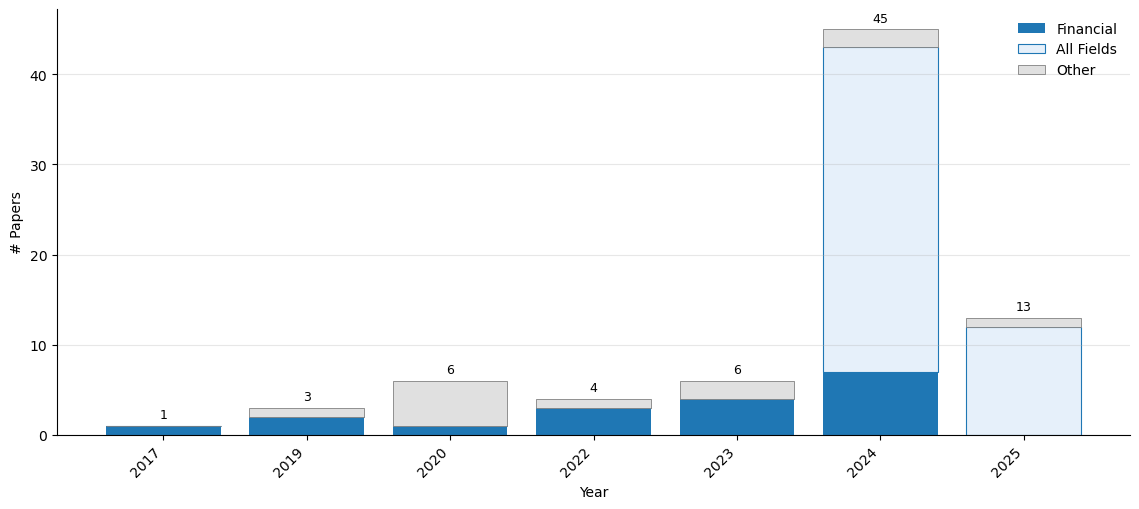

Saved figure to: paper_distribution_by_year.png (dpi=1000)
Total rows in df_combined: 78
Rows with parsed year:     78
Missing/unknown year:     0


Search,Financial,All Fields,Other
Year,,,
2017,1,0,0
2019,2,0,1
2020,1,0,5
2022,3,0,1
2023,4,0,2
2024,7,36,2
2025,0,12,1


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
SEARCH_COL = "Search"
GROUP_ORDER = ["Financial", "All Fields", "Other"]

# academic palette (for visualization purposes mostly)
COLOR_FIN = "#1f77b4"    # strong academic blue
COLOR_ALL = "#e6f0fa"    # very light blue / almost white
COLOR_OTHER = "#e0e0e0"   # very light, unobtrusive grey

EDGE_COLOR = "#1f77b4"

OUT_PATH = "paper_distribution_by_year.png"
DPI = 1000


# Helpers
def find_year_col(df):
    candidates = [
        "Date", "date", "Publication Year", "publicationYear", "Year", "year",
        "Issued", "issued", "Issued year", "Issued Year",
        "Date_zotero", "Date_overleaf",
        "Publication Year_zotero", "Publication Year_overleaf",
        "Year_zotero", "Year_overleaf",
        "publicationYear_zotero", "publicationYear_overleaf",
    ]
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c

    for c in df.columns:
        lc = str(c).casefold()
        if any(k in lc for k in ["publication year", "publicationyear", "issued", " year", "date"]):
            return c
    return None

def parse_year(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r"(\d{4})", expand=False)
    y = pd.to_numeric(s, errors="coerce")
    return y.where((y >= 1800) & (y <= 2100))



# Build Year column
year_z = None
year_o = None

for c in df_combined.columns:
    lc = str(c).casefold()
    if any(k in lc for k in ["year", "date", "issued"]):
        if str(c).endswith("_zotero") and year_z is None:
            year_z = c
        if str(c).endswith("_overleaf") and year_o is None:
            year_o = c

fallback = find_year_col(df_combined)

if year_z is None and year_o is None and fallback is None:
    raise KeyError("Couldn't find a year/date column in df_combined.")

if year_z is not None and year_o is not None:
    years = parse_year(df_combined[year_z]).combine_first(parse_year(df_combined[year_o]))
elif year_z is not None:
    years = parse_year(df_combined[year_z])
elif year_o is not None:
    years = parse_year(df_combined[year_o])
else:
    years = parse_year(df_combined[fallback])

df_plot = df_combined.copy()
df_plot["Year"] = years



# Clean + classify Search
df_plot["Year"] = df_plot["Year"].astype("Int64")

# normalize Search column
df_plot[SEARCH_COL] = df_plot.get(SEARCH_COL, "").astype(str).str.strip()

df_plot[SEARCH_COL] = df_plot[SEARCH_COL].replace({
    "All Field": "All Fields",
    "All fields": "All Fields",
    "All Field ": "All Fields",
    "All Fields ": "All Fields",
})

# assign missing / unknown to "Other"
df_plot.loc[
    ~df_plot[SEARCH_COL].isin(["Financial", "All Fields"]),
    SEARCH_COL
] = "Other"

df_plot = df_plot.dropna(subset=["Year"]).copy()
df_plot["Year"] = df_plot["Year"].astype(int)


# Aggregate counts
counts = (
    df_plot
    .groupby(["Year", SEARCH_COL])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# ensure all groups exist
for g in GROUP_ORDER:
    if g not in counts.columns:
        counts[g] = 0

counts = counts[GROUP_ORDER]

# Plot (stacked)
years = counts.index.to_numpy()
x = np.arange(len(years))

fin_vals = counts["Financial"].to_numpy()
all_vals = counts["All Fields"].to_numpy()
oth_vals = counts["Other"].to_numpy()

total_vals = fin_vals + all_vals + oth_vals

plt.figure(figsize=(11.5, 5.2))
ax = plt.gca()

bars_fin = ax.bar(
    x,
    fin_vals,
    color=COLOR_FIN,
    label="Financial"
)

bars_all = ax.bar(
    x,
    all_vals,
    bottom=fin_vals,
    color=COLOR_ALL,
    edgecolor=EDGE_COLOR,
    linewidth=0.8,
    label="All Fields"
)

bars_oth = ax.bar(
    x,
    oth_vals,
    bottom=fin_vals + all_vals,
    color=COLOR_OTHER,
    edgecolor="gray",
    linewidth=0.6,
    label="Other"
)

ax.set_xticks(x)
ax.set_xticklabels(years.astype(str), rotation=45, ha="right")
ax.set_xlabel("Year")
ax.set_ylabel("# Papers")

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

ymax = total_vals.max() if len(total_vals) else 0
offset = max(0.5, 0.01 * ymax) if ymax else 0.5

for i, total in enumerate(total_vals):
    if total > 0:
        ax.text(
            x[i],
            total + offset,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure to: {OUT_PATH} (dpi={DPI})")
print(f"Total rows in df_combined: {len(df_combined)}")
print(f"Rows with parsed year:     {len(df_plot)}")
print(f"Missing/unknown year:     {len(df_combined) - len(df_plot)}")

display(counts.tail(20))

counts.to_csv(
    "figure4.csv",
    index=False
)

# ML/XAI preparation used by Tables 6–7, Figures 5–9, Appendix C and robustness figures

The next cells are the preparation logic from `paper_ml_xai_investigation.ipynb`.

The original workflow creates a finance subdomain only for records whose `Domain` is `Finance`. It first tries the local Ollama classifier and falls back to the original keyword rules when Ollama is unavailable. The manuscript states that these assignments were manually checked afterward.

In [12]:
import pandas as pd

df_ml = df_combined.copy()

# Add Domain as a copy of Field (only if Domain does not already exist)
if "Domain" not in df_ml.columns:
    df_ml["Domain"] = df_ml["Field"]

# Add new manual columns only if missing
if "Specific Domain (Finance only)" not in df_ml.columns:
    df_ml["Specific Domain (Finance only)"] = ""

if "ML Techniques (Abbreviation)" not in df_ml.columns:
    df_ml["ML Techniques (Abbreviation)"] = ""

# Optional: trim whitespace in the added string columns
for c in ["Domain", "Specific Domain (Finance only)", "ML Techniques (Abbreviation)"]:
    df_ml[c] = df_ml[c].astype("string").str.strip()

In [13]:
# Finance subdomain classification based solely on Domain (LLM) - this will be manually checked as described in paper
import re, time, requests
import pandas as pd
from typing import Optional

# Config: reuse existing globals if present
MODEL_NAME = globals().get("MODEL_NAME", "llama3.1:8b")
GEN_URL    = globals().get("GEN_URL", "http://127.0.0.1:11434/api/generate")

# Canonical finance subdomains
FINANCE_SUBDOMAINS = [
    "Portfolio Optimization", "Asset Allocation", "Algorithmic Trading", "High-Frequency Trading",
    "Risk Management", "Credit Risk", "Asset Pricing", "Factor Models",
    "Derivatives / Option Pricing", "Fixed Income", "Volatility Modeling", "Market Microstructure",
    "Financial Forecasting", "Corporate Finance", "Behavioral Finance", "Financial Econometrics",
    "Stress Testing / VaR", "Cryptocurrency / Blockchain", "Insurance / Actuarial", "Other (Finance)"
]
_LUT = {s.lower(): s for s in FINANCE_SUBDOMAINS}

def infer_finance_subdomain_llm(abstract: Optional[str]) -> Optional[str]:
    """Ask the local LLM (Ollama) for exactly one finance subdomain."""
    if not isinstance(abstract, str) or not abstract.strip():
        return None
    prompt = f"""You are a precise classifier for FINANCE research abstracts.
Choose EXACTLY one label from this list and output ONLY the label text:

{', '.join(FINANCE_SUBDOMAINS)}

If nothing fits, output: Other (Finance).

Abstract:
\"\"\"{abstract.strip()[:5000]}\"\"\""""
    try:
        r = requests.post(
            GEN_URL,
            json={"model": MODEL_NAME, "prompt": prompt, "stream": False, "options": {"temperature": 0}},
            timeout=60
        )
        r.raise_for_status()
        text = (r.json().get("response") or "").strip()
        label = text.splitlines()[0].strip().strip(":.- ")
        return _LUT.get(label.lower(), label)
    except Exception:
        return None

# Lightweight keyword fallback if LLM is unavailable
HEURISTICS = [
    ("High-Frequency Trading", r"\bhft\b|high[- ]frequency|microsecond|millisecond|latenc"),
    ("Algorithmic Trading", r"\balgorithmic trad|trading strategy|backtest|execution algo|market making"),
    ("Portfolio Optimization", r"\bportfolio optim|mean[- ]variance|efficient frontier|rebalanc|transaction cost"),
    ("Asset Allocation", r"\basset allocation|strategic|tactical|long[- ]only|multi[- ]asset"),
    ("Risk Management", r"\brisk manag|risk control|downside risk|expected shortfall|var\b|value[- ]at[- ]risk"),
    ("Credit Risk", r"\bcredit risk|default|pd\b|probability of default|lgd\b|loss given default"),
    ("Derivatives / Option Pricing", r"\boption pricing|black[- ]scholes|implied volatil|greeks|derivative"),
    ("Fixed Income", r"\byield curve|term structure|bond|treasury|duration|convexity"),
    ("Volatility Modeling", r"\bgarch|egarch|heston|stochastic volatil|volatility model"),
    ("Asset Pricing", r"\basset pricing|pricing kernel|consumption[- ]based|capm|icappm"),
    ("Factor Models", r"\bfactor model|fama[- ]french|momentum|value factor|size factor|risk premia"),
    ("Market Microstructure", r"\bmicrostructure|order book|limit order|tick size|bid[- ]ask spread"),
    ("Financial Forecasting", r"\bforecast|prediction|nowcast|time series|lstm|gru|transformer"),
    ("Corporate Finance", r"\bcorporate finance|capital structure|dividend|m&a|merger|acquisition"),
    ("Behavioral Finance", r"\bbehavioral finance|investor sentiment|anomal"),
    ("Financial Econometrics", r"\beconometric|panel data|cointegration|arima|var\b(?!\s*model)"),
    ("Stress Testing / VaR", r"\bstress test|scenario analysis|value[- ]at[- ]risk|var\b"),
    ("Cryptocurrency / Blockchain", r"\bcrypto(currency)?|blockchain|bitcoin|ethereum|defi"),
    ("Insurance / Actuarial", r"\bactuar|insurance|premium|claims|solvency"),
]
def infer_finance_subdomain_fallback(abstract: Optional[str]) -> Optional[str]:
    if not isinstance(abstract, str) or not abstract.strip():
        return None
    txt = abstract.lower()
    for label, pattern in HEURISTICS:
        if re.search(pattern, txt):
            return label
    return "Other (Finance)"

# Cached classifier
_cache_fin: dict[str, str] = {}
def classify_finance_subdomain(abstract: Optional[str]) -> Optional[str]:
    key = (abstract or "").strip()
    if not key:
        return None
    if key in _cache_fin:
        return _cache_fin[key]
    label = infer_finance_subdomain_llm(key) or infer_finance_subdomain_fallback(key)
    _cache_fin[key] = label
    time.sleep(0.02)  # gentle pacing if LLM is live
    return label

# --- Apply only where Domain (LLM) == "Finance" ---
if "Domain" not in df_ml.columns:
    raise KeyError("df_ml must contain 'Domain'.")
if "Abstract Note" not in df_ml.columns:
    raise KeyError("df_ml must contain 'Abstract Note'.")

target_col = "Specific Domain (Finance only)"
if target_col not in df_ml.columns:
    df_ml[target_col] = ""

mask_fin = df_ml["Domain"].astype("string").str.strip().str.casefold().eq("finance")

# classify Finance rows; blank out others
df_ml.loc[mask_fin, target_col] = (
    df_ml.loc[mask_fin, "Abstract Note"]
         .apply(classify_finance_subdomain)
         .astype("string").str.strip()
)
df_ml.loc[~mask_fin, target_col] = ""

In [14]:
import re
import pandas as pd

# Create some helpers
_ABBR_RE = re.compile(r"^[A-Z][A-Z0-9\-]{1,}$")  # e.g., LSTM, CNN, XGB, RF, ARIMA, TCN

def _parse_tech(part: str) -> tuple[str, str]:
    """
    'Long Short-Term Memory (LSTM)' becomes ('Long Short-Term Memory', 'LSTM')
    'LSTM' becomes ('LSTM', 'LSTM')   # here I treat pure abbreviations as abbreviation too
    'Decision Tree' -> ('Decision Tree', '')
    """
    part = (part or "").strip()
    if not part:
        return "", ""

    m = re.match(r"^\s*(.*?)\s*(?:\((.*?)\))?\s*$", part)
    full = (m.group(1) if m else part).strip(" .;")
    abbr = (m.group(2) if (m and m.group(2)) else "").strip(" .;")

    # If no (ABBR) provided but token itself is an abbreviation, use it
    if not abbr and _ABBR_RE.match(full):
        abbr = full

    return full, abbr

def _colon_aware_items(cell: object) -> list[tuple[str, str | None]]:
    if cell is None or (isinstance(cell, float) and pd.isna(cell)):
        return []
    text = str(cell).strip()
    if not text:
        return []

    # Treat both ',' and ';' as item separators
    toks = [t.strip() for t in re.split(r"\s*[,;]\s*", text) if t.strip()]

    items: list[tuple[str, str | None]] = []
    for tok in toks:
        if ":" in tok:
            head, tail = tok.split(":", 1)
            head = head.strip()
            tail = tail.strip()
            items.append((head, tail if tail else None))
        else:
            items.append((tok, None))

    return items


# build df_ml_exp (expanded version)
base = df_ml.copy()

src_col = "ML Technique(s)"
abbr_col = "ML Techniques (Abbreviation)"
ext_col = "ML Techniques Extended"   # this will be created

# Build list of (general, specific) pairs per row
base["__items"] = base[src_col].apply(_colon_aware_items)

# Explode to one row per item
df_ml_exp = base.explode("__items", ignore_index=True)
df_ml_exp = df_ml_exp[df_ml_exp["__items"].notna()].copy()

def _expand(item):
    general_raw, specific_raw = item

    gen_full, gen_abbr = _parse_tech(general_raw)
    spec_full, spec_abbr = _parse_tech(specific_raw) if specific_raw else ("", "")

    # Keep the "general" in ML Technique(s), put the specific in Extended
    return pd.Series({
        src_col: gen_full,
        abbr_col: gen_abbr,
        ext_col: spec_full,
        # Optional: if you want abbreviation for the specific too, uncomment:
        # "ML Techniques Extended (Abbreviation)": spec_abbr
    })

df_ml_exp[[src_col, abbr_col, ext_col]] = df_ml_exp["__items"].apply(_expand)

# Clean types/whitespace
for c in [src_col, abbr_col, ext_col]:
    df_ml_exp[c] = df_ml_exp[c].astype("string").str.strip()

# Drop helper
df_ml_exp.drop(columns=["__items"], inplace=True)

## Table B2 — Papers and their ML techniques within the search scope

**How it is produced:** this table is a direct paper-level extraction from the same final corpus used by the original notebooks. It keeps records belonging to the two systematic search streams and reports the manuscript reference key, ML-technique coding and search stream.

No additional analytical transformation is introduced.

In [16]:
def _clean_search(x):
    x = "" if pd.isna(x) else str(x).strip()
    return {
        "All Field": "All Fields",
        "All fields": "All Fields",
        "All Field ": "All Fields",
        "All Fields ": "All Fields",
    }.get(x, x)

tmp_b2 = df_combined.copy()
tmp_b2["Search"] = tmp_b2["Search"].map(_clean_search)
tmp_b2 = tmp_b2[tmp_b2["Search"].isin(["All Fields", "Financial"])].copy()

ref_col = "Ref" if "Ref" in tmp_b2.columns else "Title_zotero"
table_b2 = (
    tmp_b2[[ref_col, "ML Technique(s)", "Search"]]
    .rename(columns={ref_col: "Reference"})
    .reset_index(drop=True)
)
display(table_b2)

table_b2.to_csv(
    "table_b2.csv",
    index=False
)

,Reference,ML Technique(s),Search
0,\cite{park_stock_2022},"Long Short-Term Memory (LSTM), Random Forest (...",Financial
1,\cite{giudici_explainable_2024},"Long Short-Term Memory (LSTM), Gated Recurrent...",Financial
2,\cite{parente_profitable_2024},Multi-Layer Perceptron (MLP),Financial
3,\cite{valensky_evaluating_2023},"Long Short-Term Memory (LSTM), Convolutional N...",Financial
4,\cite{mienye_deep_2024},"Convolutional Neural Network (CNN), Long Short...",Financial
...,...,...,...
61,\cite{xu_kolmogorov-arnold_2024},"Multi-Layer Perceptron (MLP), Recurrent Neural...",All Fields
62,\cite{oprea_evaluating_2024},Convolutional Neural Network (CNN),All Fields
63,\cite{der_pupae_2024},NaN,All Fields
64,\cite{schneider_time-series_2025},Multi-Layer Perceptron (MLP),All Fields


## Table C11 — AI techniques across finance subfields

**Original source:** `paper_ml_xai_investigation.ipynb`, finance-subfield/ML-technique aggregation.

**How it is produced:** the paper-level finance subfield coding is combined with the reported ML techniques. The original helper explodes techniques and aggregates papers/authors by `(Finance Subfield, ML Technique)`. The compact manuscript-style view below then groups these code-derived entries by finance subfield.

In [18]:
import pandas as pd
import re

# Helpers
def _clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    bad = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    if re.sub(r"\s+", "", x).casefold() in bad:
        return  
    return x

def split_techniques(val):
    """Split 'ML Technique(s)' cell into a list of techniques."""
    val = _clean_text(val)
    if not val:
        return []
    parts = re.split(r"\s*(?:;|,|\||/|\band\b)\s*", val)
    return [p.strip() for p in parts if _clean_text(p)]

def uniq_order(seq):
    """Unique values preserving first-seen order."""
    seen = set()
    out = []
    for x in seq:
        if x is None:
            continue
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# Main builder
def finance_subfield_ml_authors_only(
    df,
    subfield_col="Specific Domain (Finance only)",
    tech_col="ML Technique(s)",
    author_col="Author",
    doi_col="DOI",
    title_col="Title_overleaf",
    title_fallback_col="Title_zotero",
    ref_sep=" || ",
):
    d = df.copy()

    # finance subfield
    d["__subfield"] = d.get(subfield_col, pd.Series([None]*len(d))).map(_clean_text)
    d = d.dropna(subset=["__subfield"])

    # authors
    d["__authors"] = d.get(author_col, pd.Series([None]*len(d))).map(_clean_text)

    # paper id: DOI preferred; fallback to title; final fallback to index
    paper_id = None
    if doi_col in d.columns:
        paper_id = d[doi_col].map(_clean_text)

    # title fallback (more stable than index)
    title = d.get(title_col, pd.Series([None]*len(d))).map(_clean_text)
    if title_fallback_col in d.columns:
        title = title.fillna(d[title_fallback_col].map(_clean_text))

    if paper_id is None:
        paper_id = title
    else:
        paper_id = paper_id.fillna(title)

    # final fallback: index (Series aligned to index)
    paper_id = paper_id.fillna(pd.Series(d.index.astype(str), index=d.index))
    d["__paper_id"] = paper_id

    # explode techniques
    d["__tech_list"] = d.get(tech_col, pd.Series([None]*len(d))).apply(split_techniques)
    ex = d.explode("__tech_list").rename(columns={"__tech_list": "__tech"})
    ex["__tech"] = ex["__tech"].map(_clean_text)

    # keep valid
    ex = ex.dropna(subset=["__tech", "__paper_id", "__authors"])

    # aggregate per (subfield, technique)
    out = (
        ex.groupby(["__subfield", "__tech"], as_index=False)
          .agg(
              Paper_Count=("__paper_id", "nunique"),
              Authors=("__authors", lambda s: ref_sep.join(uniq_order(s))),
          )
          .rename(columns={"__subfield": "Finance Subfield", "__tech": "ML Technique"})
          .sort_values(["Finance Subfield", "Paper_Count"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return out, ex



df_subfield_ml_authors, exploded_ml_pairs = finance_subfield_ml_authors_only(df_ml)

# Compact manuscript-style view based on the original code-generated pairs.
def _group_subfield_table(exploded_pairs, tech_name):
    x = exploded_pairs.copy()
    # one paper count per finance subfield
    paper_counts = (
        x.groupby("__subfield")["__paper_id"].nunique().rename("# Papers")
    )
    # group techniques and authors in deterministic order
    rows = []
    for subfield, sub in x.groupby("__subfield", sort=True):
        seen = []
        for _, r in sub.iterrows():
            item = f"{r['__tech']} ({r['__authors']})"
            if item not in seen:
                seen.append(item)
        rows.append({
            "Finance Subfield": subfield,
            "# Papers": int(paper_counts.loc[subfield]),
            f"{tech_name} Techniques / References": "; ".join(seen),
        })
    return pd.DataFrame(rows)

table_c11 = _group_subfield_table(exploded_ml_pairs, "AI")
display(table_c11)

table_c11.to_csv(
    "table_c11.csv",
    index=False
)

,Finance Subfield,# Papers,AI Techniques / References
0,Algorithmic Trading,2,"Multi-Layer Perceptron (MLP) (Parente, M.; Riz..."
1,Behavioral Finance,1,"Random Forest (RF) (Cau, F.M.; Hauptmann, H.; ..."
2,Financial Econometrics,9,"Long Short-Term Memory (LSTM) (Park, H.J.; Kim..."


## Figure 5 — Distribution of AI model types

**Original source:** `paper_ml_xai_investigation.ipynb`, ML donut-chart cell.

**How it is produced:** the already exploded ML-technique table is counted by general model family. Categories below 2% of all ML instances are grouped into `Other`; common long names are displayed with abbreviations such as LSTM, CNN, MLP and XGBoost.

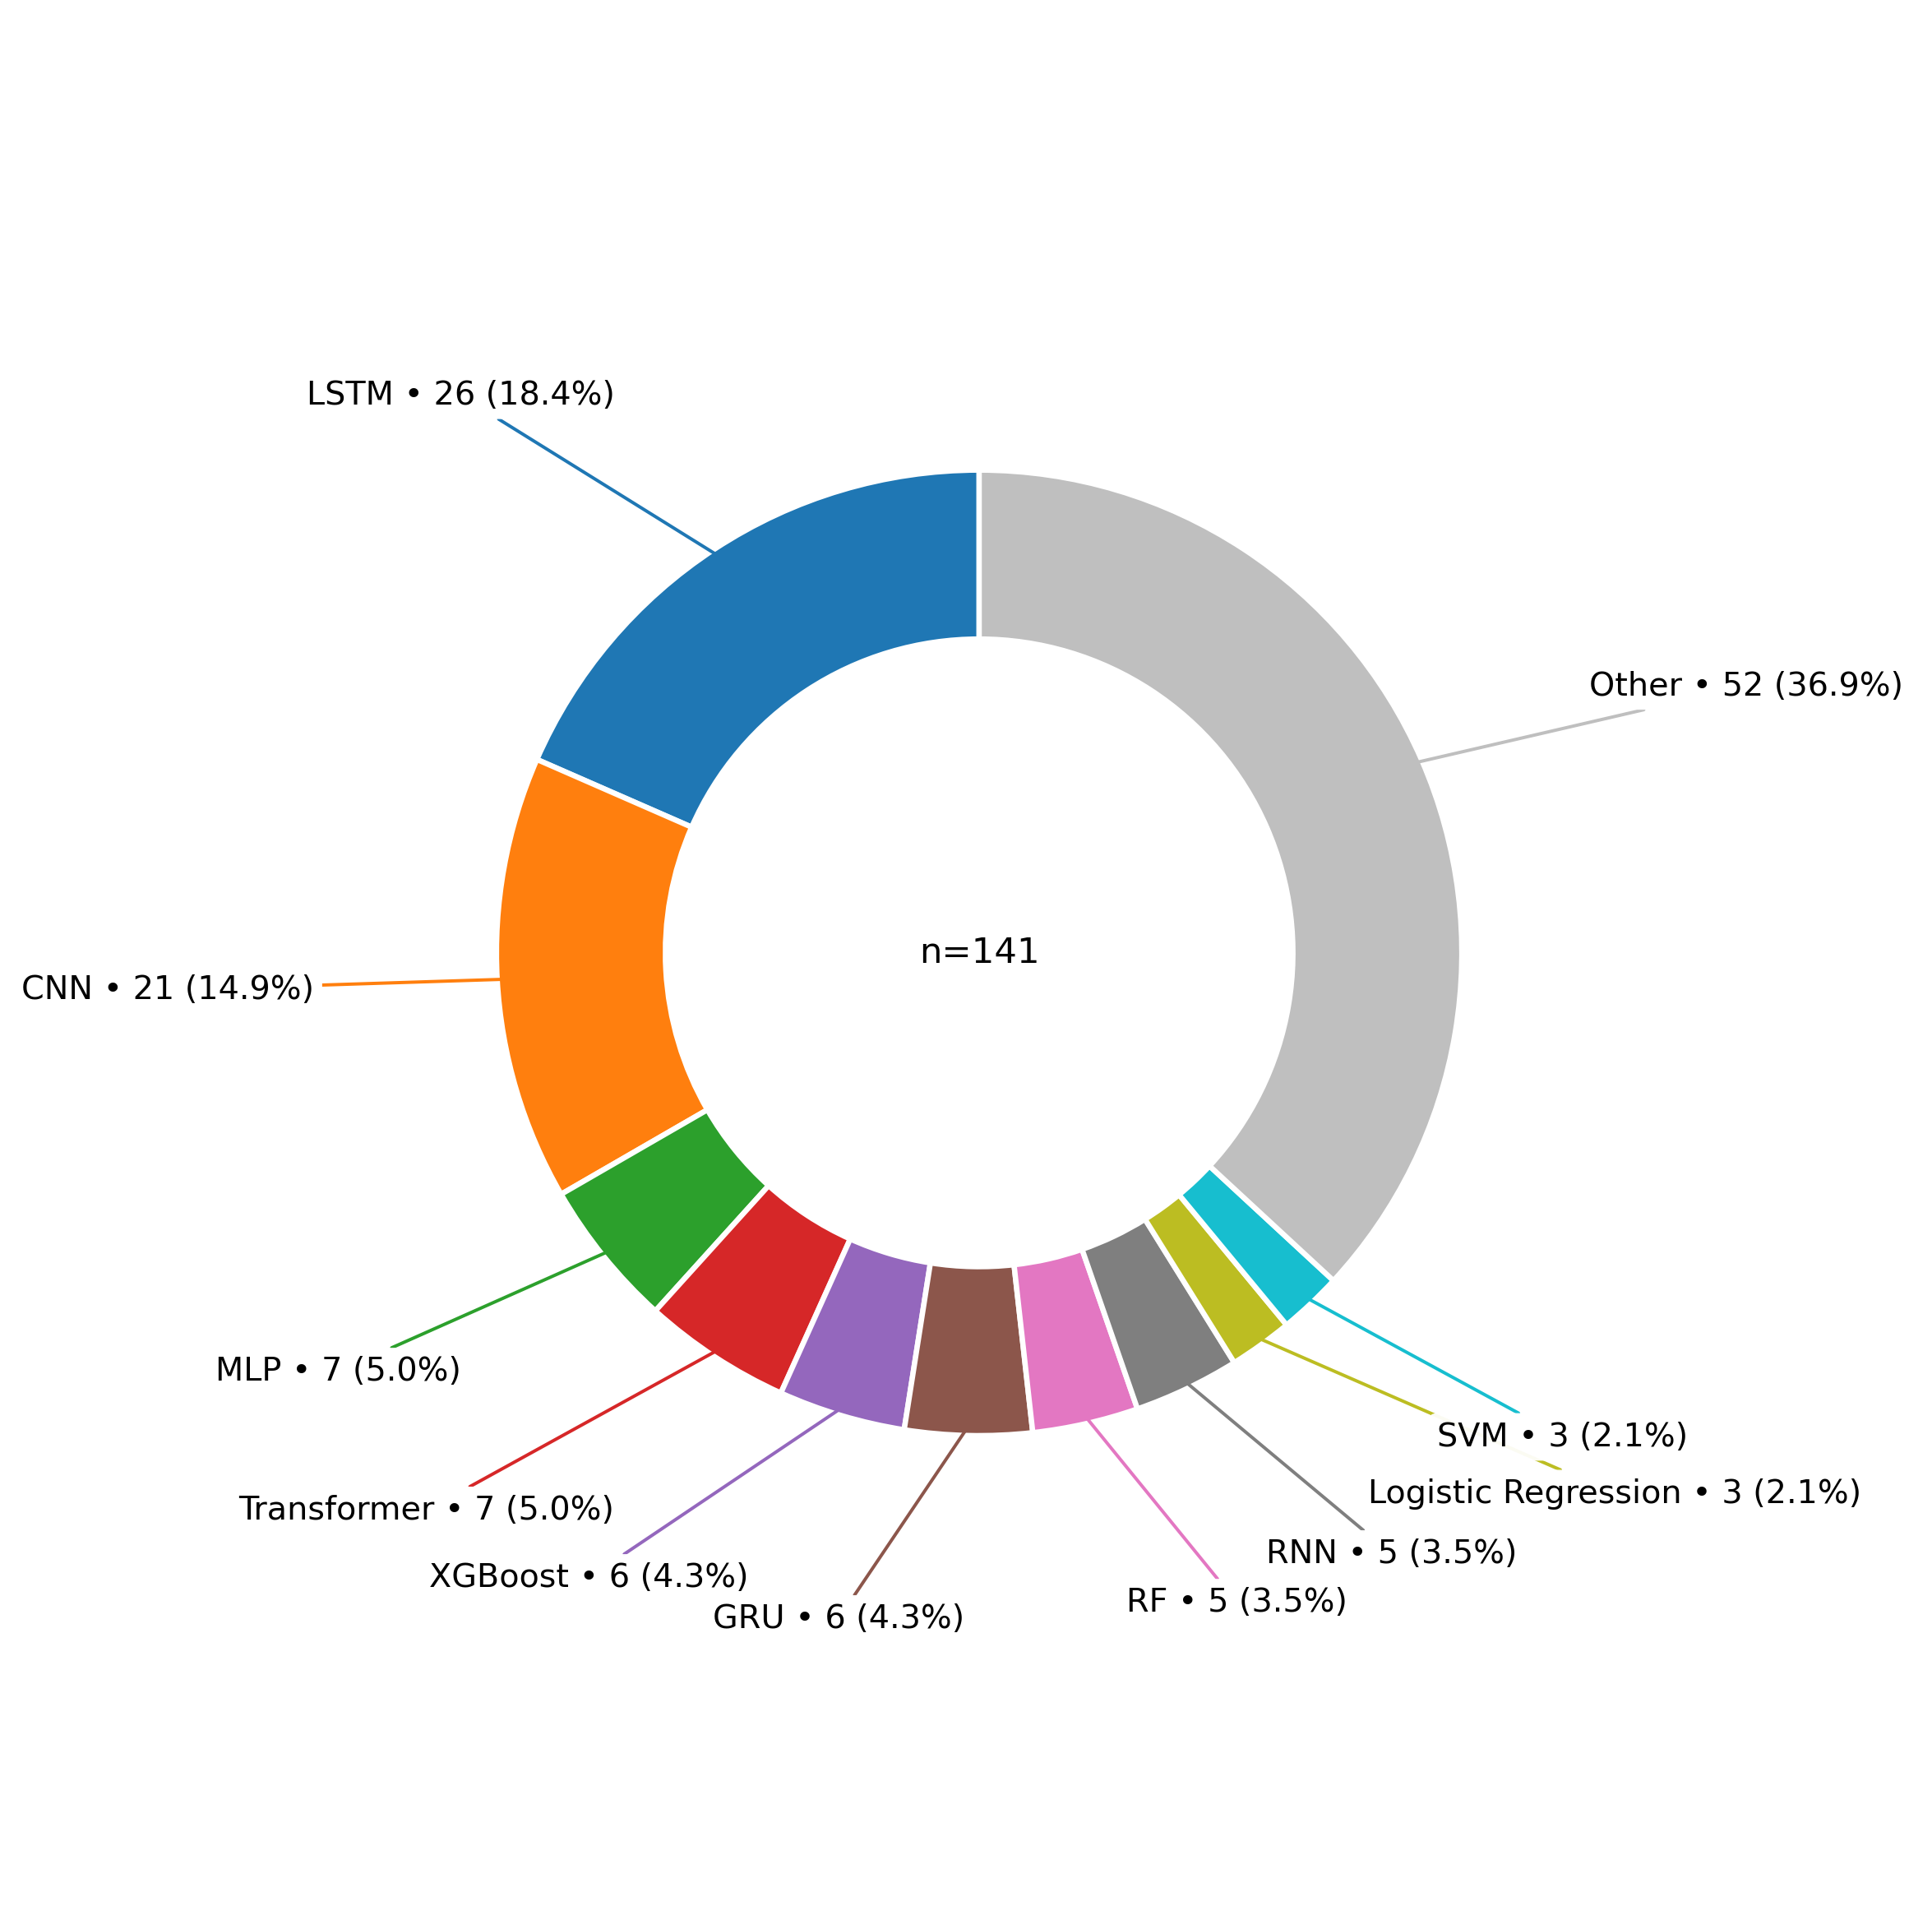

Saved to: figure5.png


In [20]:
import re, numpy as np, matplotlib.pyplot as plt
from itertools import cycle, islice
from datetime import datetime

# Config (optional, but done)
PREFERRED_COLS = ["ML Technique(s)"]  # tries in this order
MIN_PERCENT = 2.0    # group slices smaller than this % into "Other" (set to 0 to disable)
SAVE_PATH = None    

def pie_from_column_labeled(
    df,
    column=None,
    min_percent=MIN_PERCENT,
    save_path=SAVE_PATH,
    ring_width=0.35,
    label_radius=1.38,      # farther out = fewer collisions
    min_gap=0.085,          # larger vertical spacing between labels
    dpi_fig=260,
    dpi_save=450,
    abbreviate=True,
):
    if column is None:
        column = _pick_categorical_column(df)

    # clean
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()
    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]
    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")
    counts = s.value_counts().sort_values(ascending=False)

    if min_percent and min_percent > 0:
        thresh = min_percent / 100.0
        small = counts[counts / total < thresh]
        big = counts[counts / total >= thresh].drop(labels=["Other"], errors="ignore")
        other_sum = int(small.sum()) + int(counts.get("Other", 0))
        plot_counts = big.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum
    else:
        plot_counts = counts.drop(labels=["Other"], errors="ignore")
        if "Other" in counts:
            plot_counts.loc["Other"] = int(counts["Other"])

    labels = plot_counts.index.tolist()
    values = plot_counts.values
    total_plot = values.sum()

    # optional abbreviations for long names (prevents collisions)
    abbr = {
        "Long Short-Term Memory": "LSTM",
        "Convolutional Neural Network": "CNN",
        "Gated Recurrent Unit": "GRU",
        "Multi-Layer Perceptron": "MLP",
        "Extreme Gradient Boosting": "XGBoost",
        "Random Forest": "RF",
        "Deep Neural Network": "DNN",
        "Recurrent Neural Network": "RNN",
        "Support Vector Machine": "SVM",
    }
    disp = [abbr.get(l, l) if abbreviate else l for l in labels]

    # colors (Other → gray)
    base_cycle = plt.rcParams.get("axes.prop_cycle", None)
    base_colors = base_cycle.by_key().get("color", []) if base_cycle else []
    if not base_colors:
        base_colors = [plt.cm.tab20(i) for i in range(20)]
    colors = list(islice(cycle(base_colors), len(labels)))
    for i, lab in enumerate(labels):
        if str(lab).lower() == "other":
            colors[i] = (0.75, 0.75, 0.75, 1.0)

    # plot donut
    fig, ax = plt.subplots(figsize=(9.5, 9.5), dpi=dpi_fig)
    wedges, _ = ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={"linewidth": 1.8, "edgecolor": "white", "width": ring_width, "antialiased": True},
    )
    ax.set_aspect("equal")

    # initial label targets
    info = []
    for w, lab, disp_lab, val, col in zip(wedges, labels, disp, values, colors):
        ang = (w.theta2 + w.theta1) / 2.0
        rad = np.deg2rad(ang)
        x, y = np.cos(rad), np.sin(rad)
        info.append({"w": w, "lab": lab, "txt": f"{disp_lab} • {val} ({val/total_plot*100:.1f}%)",
                     "val": val, "col": col, "x": x, "y": y})

    # distribute per side with bigger minimum gap
    def _spread(side, R, gap):
        side.sort(key=lambda d: d["y"])
        ys = [d["y"] * R for d in side]
        for i in range(1, len(ys)):
            if ys[i] - ys[i-1] < gap:
                ys[i] = ys[i-1] + gap
        # clamp to range if needed
        if ys:
            offset = 0.0
            hi = R
            lo = -R
            if ys[-1] > hi: offset = hi - ys[-1]
            if ys[0] < lo:  offset = max(offset, lo - ys[0])
            ys = [y + offset for y in ys]
        for d, yv in zip(side, ys):
            sgn = 1 if d["x"] >= 0 else -1
            d["y_lab"] = yv
            d["x_lab"] = sgn * np.sqrt(max(R**2 - yv**2, 1e-6))
            d["ha"] = "left" if sgn > 0 else "right"

    right = [d for d in info if d["x"] >= 0]
    left  = [d for d in info if d["x"] <  0]
    _spread(right, label_radius, min_gap)
    _spread(left,  label_radius, min_gap)

    # draw annotations
    extras = []
    r_outer = 1.0
    for d in info:
        x_end, y_end = 0.98 * r_outer * d["x"], 0.98 * r_outer * d["y"]
        ann = ax.annotate(
            d["txt"],
            xy=(x_end, y_end),
            xytext=(d["x_lab"], d["y_lab"]),
            ha=d["ha"], va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.95),
            arrowprops=dict(arrowstyle="-", lw=1.1, color=d["col"], shrinkA=0, shrinkB=0),
        )
        extras.append(ann)

    # center total
    extras.append(ax.text(0, 0, f"n={total}", ha="center", va="center", fontsize=12))

    # spacious limits so labels never clip
    pad = 0.55
    lim = label_radius + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.tight_layout()

    # autosave if not provided
    if not save_path:
        safe_col = re.sub(r"[^A-Za-z0-9]+", "_", str(column)).strip("_").lower() or "pie"
        save_path = f"figure5.png"

    fig.savefig(
        save_path,
        dpi=dpi_save,
        bbox_inches="tight",
        bbox_extra_artists=extras,
        pad_inches=0.6,
    )
    plt.show()

    summary = plot_counts.to_frame("Count")
    summary["Percent"] = (summary["Count"] / total_plot * 100).round(2)
    return summary, save_path
summary, path = pie_from_column_labeled(df_ml_exp, column="ML Technique(s)")
print("Saved to:", path)

# This figure is eventually recreated in TikZ for Latex.

# Keep the original ML plotting function for Appendix Figures B2 and B4.
plot_ml_distribution = pie_from_column_labeled

## Table 6 — Frequently used AI techniques and financial share

**Original source:** `paper_ml_xai_investigation.ipynb`, `ml_technique_full_list_with_finance_split_refs`.

**How it is produced:** counts are taken from the exploded ML-technique rows; finance counts are obtained where `Field == "finance"`; financial share is `Finance Count / Count`.

The manuscript Table 6 is the frequent-technique subset. The same full output also underlies Appendix **C.1**, which is numbered **Table C9** in the current PDF.

In [22]:
import pandas as pd
import re
import csv

def ml_technique_full_list_with_finance_split_refs(
    df,
    column="ML Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || ",
):
    # Clean ML technique column
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()

    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    # Base count table
    table = s.value_counts().rename("Count").to_frame()
    table["Percent"] = (table["Count"] / total * 100).round(2)

    # Required columns
    for c in (field_col, author_col):
        if c not in df.columns:
            raise KeyError(f"df must contain '{c}'.")

    # Align cleaned columns with df rows
    tech_clean = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    tech_clean = pd.Series(tech_clean, dtype="object")
    tech_clean = tech_clean.where(
        ~tech_clean.fillna("").str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings),
        other=None
    )

    field_clean = df[field_col].map(lambda x: "" if pd.isna(x) else str(x).strip())
    is_finance = field_clean.str.casefold().eq(finance_label)

    authors_clean = df[author_col].map(lambda x: None if pd.isna(x) else str(x).strip())
    authors_clean = pd.Series(authors_clean, dtype="object").replace({"": None})

    # Finance counts per technique 
    finance_counts = tech_clean[is_finance].dropna().value_counts()
    table["Finance Count"] = table.index.map(lambda t: int(finance_counts.get(t, 0)))
    table["Finance Share %"] = (table["Finance Count"] / table["Count"] * 100).round(2)

    # Split references
    fin_refs = {}
    nonfin_refs = {}

    for tech, is_fin, auth in zip(tech_clean, is_finance, authors_clean):
        if tech is None or auth is None:
            continue

        target = fin_refs if is_fin else nonfin_refs
        target.setdefault(tech, [])
        if auth not in target[tech]:
            target[tech].append(auth)

    table["Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(fin_refs.get(t, []))
    )
    table["Non-Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(nonfin_refs.get(t, []))
    )

    table.index.name = column
    return table.reset_index(), total




ml_table, n_total = ml_technique_full_list_with_finance_split_refs(
    df_ml_exp,
    column="ML Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || "
)

# Table 6: the 10 frequent techniques shown in the manuscript.
_table6_names = [
    "Long Short-Term Memory",
    "Convolutional Neural Network",
    "Transformer",
    "Multi-Layer Perceptron",
    "Extreme Gradient Boosting",
    "Gated Recurrent Unit",
    "Random Forest",
    "Recurrent Neural Network",
    "Logistic Regression",
    "Support Vector Machine",
]
table6 = ml_table[ml_table["ML Technique(s)"].isin(_table6_names)].copy()
table6["AI Technique"] = table6["ML Technique(s)"].replace({
    "Long Short-Term Memory": "LSTM",
    "Convolutional Neural Network": "CNN",
    "Multi-Layer Perceptron": "MLP",
    "Extreme Gradient Boosting": "XGBoost",
    "Gated Recurrent Unit": "GRU",
    "Recurrent Neural Network": "RNN",
    "Support Vector Machine": "SVM",
})
table6["Financial Share"] = table6["Finance Share %"].round(0).astype(int).astype(str) + "%"
table6 = table6[["AI Technique", "Count", "Financial Share"]].rename(columns={"Count": "Total Studies"})
table6["__order"] = table6["AI Technique"].map({v:i for i,v in enumerate([
    "LSTM","CNN","Transformer","MLP","XGBoost","GRU","Random Forest","RNN","Logistic Regression","SVM"
])})
table6 = table6.sort_values("__order").drop(columns="__order").reset_index(drop=True)
display(table6)

# Appendix C.1 is Table C9 in the current PDF.
table_c9 = ml_table[[
    "ML Technique(s)", "Count", "Finance Count", "Finance Share %",
    "Non-Financial References (Authors)", "Financial References (Authors)"
]].copy()
display(table_c9)

table_c9.to_csv(
    "table6.csv",
    index=False
)

,AI Technique,Total Studies,Financial Share
0,LSTM,26,23%
1,CNN,21,10%
2,Transformer,7,0%
3,MLP,7,14%
4,XGBoost,6,33%
5,GRU,6,33%
6,Random Forest,5,80%
7,RNN,5,20%
8,Logistic Regression,3,33%
9,SVM,3,67%


,ML Technique(s),Count,Finance Count,Finance Share %,Non-Financial References (Authors),Financial References (Authors)
0,Long Short-Term Memory,26,6,23.08,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....","Park, H.J.; Kim, Y.; Kim, H.Y. || Giudici, P.;..."
1,Convolutional Neural Network,21,2,9.52,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....","Valensky, D.; Mohaghegh, M. || Kumar, Devinder..."
2,Multi-Layer Perceptron,7,1,14.29,"Abdullah, M.; Sulong, Z.; Ashraful Ferdous Cho...","Parente, M.; Rizzuti, L.; Trerotola, M."
3,Transformer,7,0,0.00,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....",
4,Extreme Gradient Boosting,6,2,33.33,"Kajári, B.; Tobak, Z.; Túri, N.; Bozán, C.; Va...","Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z...."
5,Gated Recurrent Unit,6,2,33.33,"Sarker, M.A.A.; Shanmugam, B.; Azam, S.; Thenn...","Giudici, P.; Piergallini, A.; Recchioni, M.C.;..."
6,Random Forest,5,4,80.00,"Saleh, H.; ElRashidy, N.; Abd Elaziz, M.; O. A...","Park, H.J.; Kim, Y.; Kim, H.Y. || Deng, S.; Zh..."
7,Recurrent Neural Network,5,1,20.00,"Doddaiah, R.; Parvatharaju, P.S.; Rundensteine...","Freeborough, W.; van Zyl, T."
8,Logistic Regression,3,1,33.33,"Popov, P.; Mahmood, U.; Fu, Z.; Yang, C.; Calh...","Muhammad, D.; Ahmed, I.; Naveed, K.; Bendechac..."
9,Support Vector Machine,3,2,66.67,"Saleh, H.; ElRashidy, N.; Abd Elaziz, M.; O. A...","Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z...."


## Figure 6 — Sankey: AI technique → field → finance subfield → finance AI technique

**Original source:** `paper_ml_xai_investigation.ipynb`, ML Sankey cell.

**How it is produced:** the exploded ML table is reduced to the most common techniques/domains, then count matrices are built for technique→domain and finance-technique→finance-subfield links. Ribbon widths are proportional to those counts.

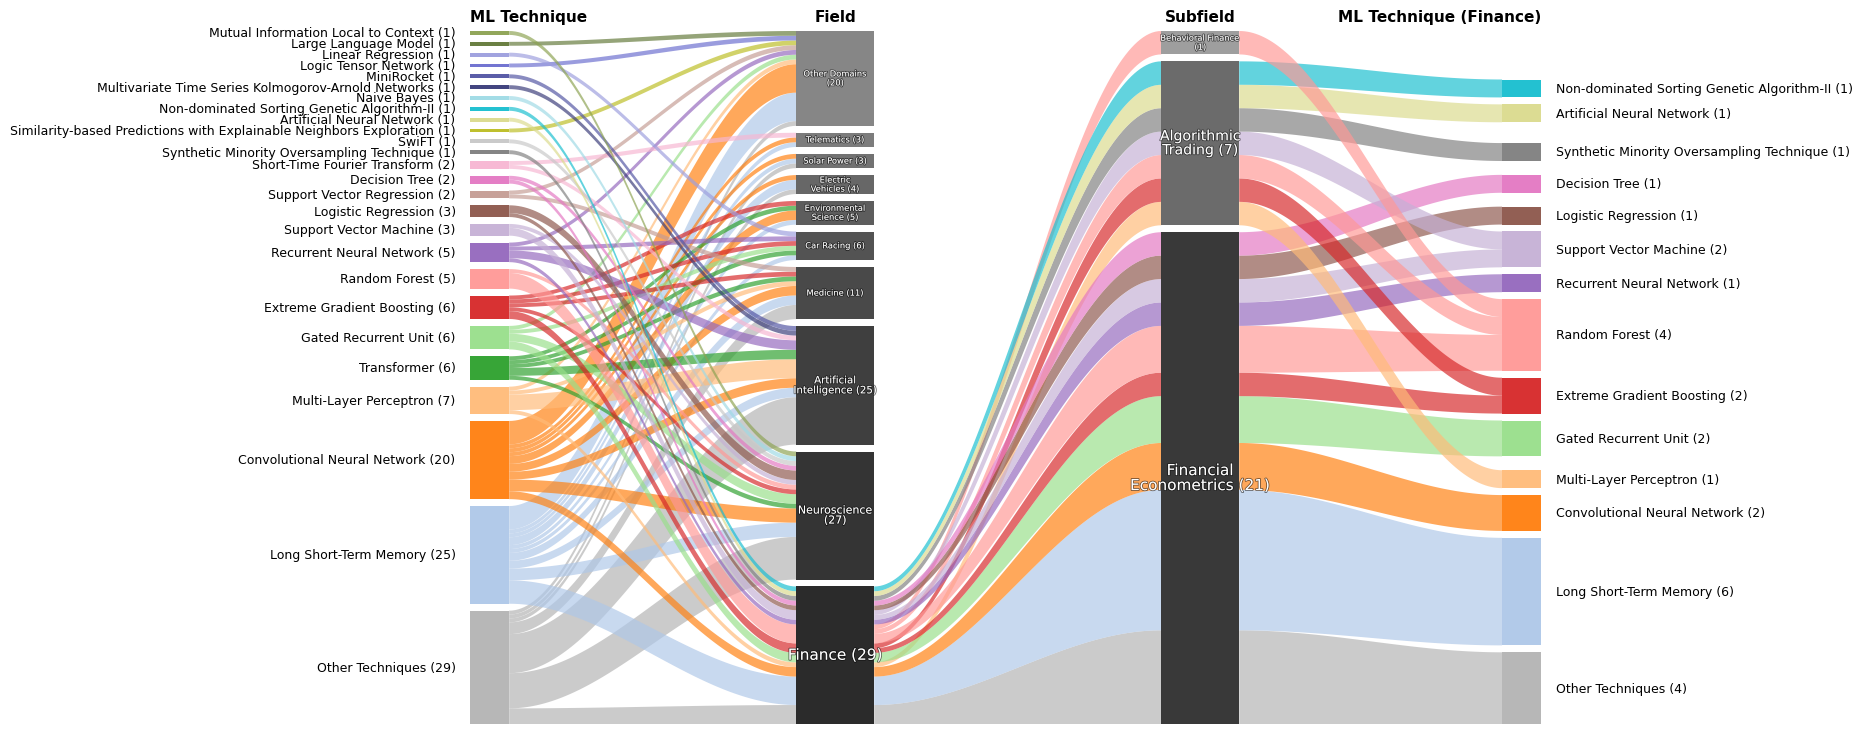

Saved: figure6.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib import patheffects as pe
import textwrap

# Config
TOP_TECH = 25
TOP_DOM  = 9
TOP_SPEC = 20

OTHER_TECH_LABEL = "Other Techniques"
OTHER_DOM_LABEL  = "Other Domains"
OTHER_SPEC_LABEL = "Other Finance"

BAR_W = 0.032
GAP = 0.01
LEFT_PAD, RIGHT_PAD = 0.012, 0.012
ALPHA_RIBBON, ALPHA_BAR = 0.68, 0.95

# Label rendering inside bars
DOMAIN_WRAP_CHARS = 16
SPEC_WRAP_CHARS   = 18
MIN_FONT_SIZE     = 6
MAX_FONT_SIZE     = 11
MIN_HEIGHT_FOR_TEXT = 0.018

# Column names
TECH_COL   = "ML Technique(s)"
DOMAIN_COL = "Domain"
SPEC_COL   = "Specific Domain (Finance only)"
FIN_LABEL  = "Finance"

# Safety checks
if "df_ml_exp" not in globals() or not isinstance(df_ml_exp, pd.DataFrame):
    raise NameError("df_ml_exp must be a pandas DataFrame in the current session.")

for c in [TECH_COL, DOMAIN_COL]:
    if c not in df_ml_exp.columns:
        raise KeyError(f"Missing required column: {c}")

# Prep / Clean
df_all = df_ml_exp.copy()

def _clean_col(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"<NA>": "", "<na>": "", "nan": "", "NaN": ""})
    return s.fillna("")

df_all[TECH_COL]   = _clean_col(df_all[TECH_COL])
df_all[DOMAIN_COL] = _clean_col(df_all[DOMAIN_COL])
df_all[SPEC_COL]   = _clean_col(df_all[SPEC_COL]) if SPEC_COL in df_all.columns else ""

df_all = df_all[(df_all[TECH_COL] != "") & (df_all[DOMAIN_COL] != "")]
if df_all.empty:
    raise ValueError(f"No rows with non-empty '{TECH_COL}' and '{DOMAIN_COL}'.")

# Finance-only subset
df_fin = df_all[df_all[DOMAIN_COL].str.casefold().eq(FIN_LABEL.casefold())].copy()
if df_fin.empty:
    raise ValueError("No Finance rows found. Sankey requires finance rows for the right legs.")
df_fin["__Spec"] = np.where(df_fin[SPEC_COL] != "", df_fin[SPEC_COL], "Finance (Unspecified)")

# Reduce cardinality
# Techniques
tech_tot_all = df_all.groupby(TECH_COL).size().sort_values(ascending=False)
tech_keep = tech_tot_all.index[:TOP_TECH].tolist() if len(tech_tot_all) > TOP_TECH else tech_tot_all.index.tolist()
df_all["__TechRed"] = np.where(df_all[TECH_COL].isin(tech_keep), df_all[TECH_COL], OTHER_TECH_LABEL)
df_fin["__TechRed"] = np.where(df_fin[TECH_COL].isin(tech_keep), df_fin[TECH_COL], OTHER_TECH_LABEL)

# Domains (TOP 9 + Other)
dom_tot_all = df_all.groupby(DOMAIN_COL).size().sort_values(ascending=False)
dom_keep = dom_tot_all.index[:TOP_DOM].tolist() if len(dom_tot_all) > TOP_DOM else dom_tot_all.index.tolist()
df_all["__DomRed"] = np.where(df_all[DOMAIN_COL].isin(dom_keep), df_all[DOMAIN_COL], OTHER_DOM_LABEL)
df_fin["__DomRed"] = np.where(df_fin[DOMAIN_COL].isin(dom_keep), df_fin[DOMAIN_COL], OTHER_DOM_LABEL)

# Finance subdomains
spec_tot_all_fin = df_fin.groupby("__Spec").size().sort_values(ascending=False)
spec_keep = spec_tot_all_fin.index[:TOP_SPEC].tolist() if len(spec_tot_all_fin) > TOP_SPEC else spec_tot_all_fin.index.tolist()
df_fin["__SpecRed"] = np.where(df_fin["__Spec"].isin(spec_keep), df_fin["__Spec"], OTHER_SPEC_LABEL)

# Flow tables
flows_T_D = df_all.groupby(["__TechRed", "__DomRed"]).size().unstack(fill_value=0)
flows_T_S_fin = df_fin.groupby(["__TechRed", "__SpecRed"]).size().unstack(fill_value=0)

# Node totals & orders
tech_tot_left = flows_T_D.sum(axis=1).sort_values(ascending=False)
dom_totals    = flows_T_D.sum(axis=0).sort_values(ascending=False)

# keep "Other Domains" last
dom_order = dom_totals.index.tolist()
if OTHER_DOM_LABEL in dom_order:
    dom_order = [d for d in dom_order if d != OTHER_DOM_LABEL] + [OTHER_DOM_LABEL]
flows_T_D = flows_T_D.reindex(index=tech_tot_left.index, columns=dom_order, fill_value=0)

spec_totals = flows_T_S_fin.sum(axis=0).sort_values(ascending=False)

# keep "Other Finance" last
spec_order = spec_totals.index.tolist()
if OTHER_SPEC_LABEL in spec_order:
    spec_order = [s for s in spec_order if s != OTHER_SPEC_LABEL] + [OTHER_SPEC_LABEL]
flows_T_S_fin = flows_T_S_fin.reindex(index=tech_tot_left.index, columns=spec_order, fill_value=0)

# right-tech totals align to ALL-tech order
tech_tot_right = flows_T_S_fin.sum(axis=1).reindex(tech_tot_left.index, fill_value=0)

tech_labels = tech_tot_left.index.tolist()
dom_labels  = flows_T_D.columns.tolist()
spec_labels = flows_T_S_fin.columns.tolist()
tech_right_labels = tech_labels[:]  # same order on the right

# Colors
def make_color_map(labels):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])
    if len(colors) < len(labels):
        need = len(labels) - len(colors)
        hsv = plt.get_cmap("hsv", need + 1)
        colors.extend([hsv(i) for i in range(need)])
    mapping = {lab: colors[i] for i, lab in enumerate(labels)}
    if OTHER_TECH_LABEL in mapping:
        mapping[OTHER_TECH_LABEL] = (0.7, 0.7, 0.7, 1.0)
    return mapping

color_by_tech = make_color_map(tech_labels)

def greyscale_list(n, lo=0.12, hi=0.55):
    if n <= 0:
        return []
    vals = np.linspace(lo, hi, n)
    return [(v, v, v, 1.0) for v in vals]

domain_colors = {d: c for d, c in zip(dom_labels, greyscale_list(len(dom_labels), lo=0.12, hi=0.50))}
spec_colors   = {s: c for s, c in zip(spec_labels, greyscale_list(len(spec_labels), lo=0.18, hi=0.60))}

# Layout helpers
def stack_positions(values, total_height=1.0, gap=GAP):
    vals = np.asarray(values, dtype=float)
    s = vals.sum()
    usable = max(total_height - gap * max(len(vals) - 1, 0), 0.0)
    heights = np.zeros_like(vals) if s <= 0 else (vals / s) * usable
    y0, y = [], 0.0
    for h in heights:
        y0.append(y)
        y += h + gap
    y0 = np.array(y0)
    y1 = y0 + heights
    return y0, y1, heights

def cubic_bezier(P0, P1, P2, P3, ts):
    ts = np.asarray(ts)[:, None]
    return ((1-ts)**3)*P0 + 3*((1-ts)**2)*ts*P1 + 3*(1-ts)*(ts**2)*P2 + (ts**3)*P3

def draw_ribbon(ax, x0, y0_top, y0_bot, x1, y1_top, y1_bot, color, curvature=0.35, n=100, alpha=ALPHA_RIBBON):
    P0 = np.array([x0, y0_top]);  P3 = np.array([x1, y1_top]);  dx = x1 - x0
    P1 = P0 + np.array([dx*curvature, 0.0]);  P2 = P3 - np.array([dx*curvature, 0.0])
    ts = np.linspace(0, 1, n)
    top = cubic_bezier(P0, P1, P2, P3, ts)

    P0b = np.array([x0, y0_bot]);  P3b = np.array([x1, y1_bot])
    P1b = P0b + np.array([dx*curvature, 0.0]);  P2b = P3b - np.array([dx*curvature, 0.0])
    bot = cubic_bezier(P0b, P1b, P2b, P3b, ts)

    verts = np.vstack([top, bot[::-1], top[:1]])
    codes = [Path.MOVETO] + [Path.LINETO]*(top.shape[0]-1) + [Path.LINETO]*bot.shape[0] + [Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts, codes), lw=0, facecolor=color, alpha=alpha))

# Label bars: max 2 lines, adaptive wrap, ellipsis if too long
def draw_labeled_bar(ax, x_left, y0, height, width, facecolor, label, wrap_chars=14):
    if height <= 0:
        return

    ax.add_patch(Rectangle((x_left, y0), width, height, lw=0,
                           facecolor=facecolor, alpha=ALPHA_BAR))

    if height < MIN_HEIGHT_FOR_TEXT or not label:
        return

    base = max(8, int(round(wrap_chars * (width / (2 * BAR_W)))))
    wrap = int(np.clip(base, 8, 26))

    lines = textwrap.wrap(label, width=wrap) or [label]
    if len(lines) > 2:
        lines = lines[:2]
        if len(lines[1]) >= 2:
            lines[1] = lines[1][:-1] + "…"

    txt = "\n".join(lines)

    fs = (height * 120) / (len(lines) + 0.8)
    fs = float(np.clip(fs, MIN_FONT_SIZE, MAX_FONT_SIZE))

    t = ax.text(
        x_left + width/2, y0 + height/2, txt,
        ha="center", va="center", fontsize=fs, color="white",
        clip_on=True, linespacing=1.0
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground=(0, 0, 0, 0.55))])

# Label forcing
# Add special cases here for labels you *must* show fully inside the bar.
def domain_label_text(dom: str, count: int) -> str:
    dom_str = str(dom)
    if dom_str == "Artificial Intelligence":
        # forced break ensures "(n)" stays visible and no truncation occurs
        return f"Artificial\nIntelligence ({count})"
    return f"{dom_str} ({count})"

# Optional: if you have a specific subdomain that also gets cut, add it here
def spec_label_text(spec: str, count: int) -> str:
    spec_str = str(spec)
    # Example special case (edit/remove as needed):
    # if spec_str == "Some Very Long Subdomain Name":
    #     return f"Some Very Long\nSubdomain Name ({count})"
    return f"{spec_str} ({count})"

# Positions
x0, x1, x2, x3 = 0.06, 0.36, 0.66, 0.94

yl0, yl1, hl = stack_positions(tech_tot_left.values)
ym0, ym1, hm = stack_positions(flows_T_D.sum(axis=0).values)
ys0, ys1, hs = stack_positions(spec_totals.values)
yr0, yr1, hr = stack_positions(tech_tot_right.values)

# Slices for ribbons
slice_TD_left, slice_TD_right = {}, {}

for i, tech in enumerate(tech_labels):
    total_i, y = tech_tot_left.values[i], yl0[i]
    if total_i <= 0:
        continue
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_i == 0 else (f / total_i) * hl[i]
        slice_TD_left[(tech, dom)] = (y + h, y)
        y += h

for j, dom in enumerate(dom_labels):
    total_j, y = flows_T_D[dom].sum(), ym0[j]
    if total_j <= 0:
        continue
    for tech in tech_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_j == 0 else (f / total_j) * hm[j]
        slice_TD_right[(tech, dom)] = (y + h, y)
        y += h

slice_FS_left, slice_FS_right = {}, {}
slice_ST_left, slice_ST_right = {}, {}

if FIN_LABEL in dom_labels:
    # B left: Finance segment split by subdomain
    for tech in tech_labels:
        seg = slice_TD_right.get((tech, FIN_LABEL))
        tech_fin_total = flows_T_D.loc[tech, FIN_LABEL] if FIN_LABEL in flows_T_D.columns else 0
        if (not seg) or tech_fin_total <= 0:
            continue
        seg_top, seg_bot = seg
        seg_h = seg_top - seg_bot
        y = seg_bot
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * seg_h
            slice_FS_left[(tech, spec)] = (y + h, y)
            y += h

    # B right: stack incoming techniques for each subdomain
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_FS_right[(tech, spec)] = (y + h, y)
            y += h

    # C left/right: subdomain -> right-tech
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_right_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_ST_left[(spec, tech)] = (y + h, y)
            y += h

    for i, tech in enumerate(tech_right_labels):
        tech_fin_total, y = tech_tot_right.loc[tech], yr0[i]
        if tech_fin_total <= 0:
            continue
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * hr[i]
            slice_ST_right[(spec, tech)] = (y + h, y)
            y += h

# Plot
fig, ax = plt.subplots(figsize=(15.7, 9.0))
for s in ax.spines.values():
    s.set_visible(False)
ax.set_axis_off()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# A) Technique to Domain (ALL)
for tech in tech_labels:
    col = color_by_tech[tech]
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        if f <= 0:
            continue
        yL_top, yL_bot = slice_TD_left[(tech, dom)]
        yR_top, yR_bot = slice_TD_right[(tech, dom)]
        draw_ribbon(ax, x0 + BAR_W, yL_top, yL_bot, x1 - BAR_W, yR_top, yR_bot, color=col)

# B) Finance to Subdomain
if FIN_LABEL in dom_labels:
    for tech in tech_labels:
        for spec in spec_labels:
            key = (tech, spec)
            if key not in slice_FS_left or key not in slice_FS_right:
                continue
            yL_top, yL_bot = slice_FS_left[key]
            yR_top, yR_bot = slice_FS_right[key]
            draw_ribbon(ax, x1 + BAR_W, yL_top, yL_bot, x2 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# C) Subdomain to Technique (right)
for spec in spec_labels:
    for tech in tech_right_labels:
        key = (spec, tech)
        if key not in slice_ST_left or key not in slice_ST_right:
            continue
        yL_top, yL_bot = slice_ST_left[key]
        yR_top, yR_bot = slice_ST_right[key]
        draw_ribbon(ax, x2 + BAR_W, yL_top, yL_bot, x3 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# Bars: Left techniques
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.add_patch(Rectangle((x0, yl0[i]), BAR_W, hl[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Bars: Domains (TOP 9 + Other) with forced-label support
for j, dom in enumerate(dom_labels):
    if hm[j] <= 0:
        continue
    count_dom = int(flows_T_D[dom].sum())
    draw_labeled_bar(
        ax,
        x_left=(x1 - BAR_W),
        y0=ym0[j],
        height=hm[j],
        width=2*BAR_W,
        facecolor=domain_colors[dom],
        label=domain_label_text(dom, count_dom),
        wrap_chars=22 if str(dom) == "Artificial Intelligence" else DOMAIN_WRAP_CHARS
    )

# Bars: Finance subdomains (with optional forced-label support)
for k, spec in enumerate(spec_labels):
    if hs[k] <= 0:
        continue
    count_spec = int(spec_totals.loc[spec])
    # If you want forced wrapping for particular specs, do it in spec_label_text()
    draw_labeled_bar(
        ax,
        x_left=(x2 - BAR_W),
        y0=ys0[k],
        height=hs[k],
        width=2*BAR_W,
        facecolor=spec_colors[spec],
        label=spec_label_text(spec, count_spec),
        wrap_chars=SPEC_WRAP_CHARS
    )

# Bars: Right techniques (touch ribbons)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.add_patch(Rectangle((x3 - BAR_W, yr0[i]), BAR_W, hr[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Left technique labels
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.text(x0 - LEFT_PAD, (yl0[i] + yl1[i]) / 2, f"{tech} ({int(tech_tot_left.loc[tech])})",
                ha="right", va="center", fontsize=9, clip_on=False)

# Right technique labels (skip zeros to reduce clutter)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.text(x3 + RIGHT_PAD, (yr0[i] + yr1[i]) / 2, f"{tech} ({int(tech_tot_right.loc[tech])})",
                ha="left", va="center", fontsize=9, clip_on=False)

# Column titles
ax.text(x0, 1.01, "ML Technique",           ha="left",   va="bottom", fontsize=11, weight="bold")
ax.text(x1, 1.01, "Field",                  ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x2, 1.01, "Subfield",               ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x3, 1.01, "ML Technique (Finance)", ha="right",  va="bottom", fontsize=11, weight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

png_path = "figure6.png"
fig.savefig(png_path, dpi=1000, bbox_inches="tight")
print(f"Saved: {png_path}")

## Prepare the XAI-technique table

This is the original colon-aware XAI parser/exploder. It separates general XAI methods from specific variants in exactly the same way as the working notebook.

In [26]:
import re
import pandas as pd

# Helpers (same as ML version, not changed)

_ABBR_RE = re.compile(r"^[A-Z][A-Z0-9\-]{1,}$")  # e.g., SHAP, LIME, IG, PDP, ALE

def _parse_tech(part: str) -> tuple[str, str]:
    """
    'Integrated Gradients (IG)' -> ('Integrated Gradients', 'IG')
    'IG' -> ('IG', 'IG')
    'Partial Dependence Plot' -> ('Partial Dependence Plot', '')
    """
    part = (part or "").strip()
    if not part:
        return "", ""

    m = re.match(r"^\s*(.*?)\s*(?:\((.*?)\))?\s*$", part)
    full = (m.group(1) if m else part).strip(" .;")
    abbr = (m.group(2) if (m and m.group(2)) else "").strip(" .;")

    if not abbr and _ABBR_RE.match(full):
        abbr = full

    return full, abbr

def _colon_aware_items(cell: object) -> list[tuple[str, str | None]]:

    if cell is None or (isinstance(cell, float) and pd.isna(cell)):
        return []
    text = str(cell).strip()
    if not text:
        return []

    # Treat both ',' and ';' as item separators
    toks = [t.strip() for t in re.split(r"\s*[,;]\s*", text) if t.strip()]

    items: list[tuple[str, str | None]] = []
    for tok in toks:
        if ":" in tok:
            head, tail = tok.split(":", 1)
            head = head.strip()
            tail = tail.strip()
            items.append((head, tail if tail else None))
        else:
            items.append((tok, None))

    return items

# Build df_xai from df_ml (colon-aware explode)

base = df_ml.copy()

src_col  = "XAI Technique(s)"
abbr_col = "XAI Techniques (Abbreviation)"   # will be created/overwritten
ext_col  = "XAI Techniques Extended"         # will be created

# Ensure target cols exist (optional, but convenient)
for c in [abbr_col, ext_col]:
    if c not in base.columns:
        base[c] = ""

# Build list of (general, specific) pairs per row
base["__items"] = base[src_col].apply(_colon_aware_items)

# Explode to one row per item
df_xai = base.explode("__items", ignore_index=True)
df_xai = df_xai[df_xai["__items"].notna()].copy()

def _expand_xai(item):
    general_raw, specific_raw = item

    gen_full, gen_abbr = _parse_tech(general_raw)
    spec_full, spec_abbr = _parse_tech(specific_raw) if specific_raw else ("", "")

    # Keep the "general" in XAI Technique(s), put the specific in Extended
    return pd.Series({
        src_col: gen_full,
        abbr_col: gen_abbr,
        ext_col: spec_full,
        # Optional: if you want abbr for the specific too, uncomment:
        # "XAI Techniques Extended (Abbreviation)": spec_abbr
    })

df_xai[[src_col, abbr_col, ext_col]] = df_xai["__items"].apply(_expand_xai)

# Clean types/whitespace
for c in [src_col, abbr_col, ext_col]:
    df_xai[c] = df_xai[c].astype("string").str.strip()

# Drop helper
df_xai.drop(columns=["__items"], inplace=True)

# Peek rows where "XAI Techniques Extended" is not empty
mask = df_xai[ext_col].fillna("").astype(str).str.strip().ne("")
df_xai.to_csv("df_xai.csv", index=False, encoding="utf-8")

df_xai.loc[mask].head()

,Key,Item Type,Publication Year,Author,Title_zotero,Publication Title,ISBN,ISSN,DOI,Url,...,openalex_top_country,openalex_topics_names,openalex_fields,openalex_fields_names,openalex_countries_names,Domain,Specific Domain (Finance only),ML Techniques (Abbreviation),XAI Techniques (Abbreviation),XAI Techniques Extended
5,MT3KUHCR,conferencePaper,2023,"Valensky, D.; Mohaghegh, M.",Evaluating Transparency: A Cross-Model Explora...,Proc. IEEE Asia-Pacific Conf. Comput. Sci. Dat...,979-835034107-2 (ISBN),NaN,10.1109/CSDE59766.2023.10487732,https://www.scopus.com/inward/record.uri?eid=2...,...,NZ,Stock Market Forecasting Methods,['Decision Sciences'],Decision Sciences,New Zealand,Finance,Financial Econometrics,,,Permutation Importance
12,EVDW9JZD,journalArticle,2022,"Freeborough, W.; van Zyl, T.",Investigating Explainability Methods in Recurr...,Applied Sciences (Switzerland),NaN,20763417 (ISSN),10.3390/app12031427,https://www.scopus.com/inward/record.uri?eid=2...,...,ZA,Stock Market Forecasting Methods; Explainable ...,"['Decision Sciences', 'Computer Science']",Decision Sciences; Computer Science,South Africa,Finance,Financial Econometrics,,,Feature Ablation
14,EVDW9JZD,journalArticle,2022,"Freeborough, W.; van Zyl, T.",Investigating Explainability Methods in Recurr...,Applied Sciences (Switzerland),NaN,20763417 (ISSN),10.3390/app12031427,https://www.scopus.com/inward/record.uri?eid=2...,...,ZA,Stock Market Forecasting Methods; Explainable ...,"['Decision Sciences', 'Computer Science']",Decision Sciences; Computer Science,South Africa,Finance,Financial Econometrics,,,Permutation Importance
16,3JTDECSM,journalArticle,2024,"Nguyen, T.T.; Le Nguyen, T.; Ifrim, G.",Robust explainer recommendation for time serie...,Data Min. Knowl. Discov.,NaN,NaN,10.1007/s10618-024-01045-8,https://www.scopus.com/inward/record.uri?eid=2...,...,IE,Time Series Analysis and Forecasting; Stock Ma...,"['Computer Science', 'Decision Sciences']",Computer Science; Decision Sciences,Ireland,Medicine,,,SHAP,GradientSHAP
19,3JTDECSM,journalArticle,2024,"Nguyen, T.T.; Le Nguyen, T.; Ifrim, G.",Robust explainer recommendation for time serie...,Data Min. Knowl. Discov.,NaN,NaN,10.1007/s10618-024-01045-8,https://www.scopus.com/inward/record.uri?eid=2...,...,IE,Time Series Analysis and Forecasting; Stock Ma...,"['Computer Science', 'Decision Sciences']",Computer Science; Decision Sciences,Ireland,Medicine,,,SHAP,ROCKET-SHAP


In [27]:
df_xai_exp = df_xai.copy()

## Table C12 — XAI techniques across finance subfields

**Original source:** `paper_ml_xai_investigation.ipynb`, finance-subfield/XAI-technique aggregation.

**How it is produced:** XAI techniques are exploded and aggregated by finance subfield and paper. The compact view below is built only from those original code-derived pairs.

In [29]:
import pandas as pd
import re

# Helpers
def _clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    bad = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    if re.sub(r"\s+", "", x).casefold() in bad:
        return None
    return x

def split_techniques(val):
    """Split 'XAI Technique(s)' cell into a list of techniques."""
    val = _clean_text(val)
    if not val:
        return []
    parts = re.split(r"\s*(?:;|,|\||/|\band\b)\s*", val)
    return [p.strip() for p in parts if _clean_text(p)]

def uniq_order(seq):
    """Unique values preserving first-seen order."""
    seen = set()
    out = []
    for x in seq:
        if x is None:
            continue
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# Main builder (XAI)
def finance_subfield_xai_authors_only(
    df,
    subfield_col="Specific Domain (Finance only)",
    tech_col="XAI Technique(s)",
    author_col="Author",
    doi_col="DOI",
    title_col="Title_overleaf",
    title_fallback_col="Title_zotero",
    ref_sep=" || ",
):
    d = df.copy()

    # finance subfield
    d["__subfield"] = d.get(subfield_col, pd.Series([None]*len(d))).map(_clean_text)
    d = d.dropna(subset=["__subfield"])

    # authors
    d["__authors"] = d.get(author_col, pd.Series([None]*len(d))).map(_clean_text)

    # paper id: DOI preferred; fallback to title; final fallback to index
    paper_id = None
    if doi_col in d.columns:
        paper_id = d[doi_col].map(_clean_text)

    title = d.get(title_col, pd.Series([None]*len(d))).map(_clean_text)
    if title_fallback_col in d.columns:
        title = title.fillna(d[title_fallback_col].map(_clean_text))

    if paper_id is None:
        paper_id = title
    else:
        paper_id = paper_id.fillna(title)

    paper_id = paper_id.fillna(pd.Series(d.index.astype(str), index=d.index))
    d["__paper_id"] = paper_id

    # explode XAI techniques
    d["__tech_list"] = d.get(tech_col, pd.Series([None]*len(d))).apply(split_techniques)
    ex = d.explode("__tech_list").rename(columns={"__tech_list": "__tech"})
    ex["__tech"] = ex["__tech"].map(_clean_text)

    # keep valid
    ex = ex.dropna(subset=["__tech", "__paper_id", "__authors"])

    # aggregate per (subfield, technique)
    out = (
        ex.groupby(["__subfield", "__tech"], as_index=False)
          .agg(
              Paper_Count=("__paper_id", "nunique"),
              Authors=("__authors", lambda s: ref_sep.join(uniq_order(s))),
          )
          .rename(columns={"__subfield": "Finance Subfield", "__tech": "XAI Technique"})
          .sort_values(["Finance Subfield", "Paper_Count"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return out, ex



df_subfield_xai_authors, exploded_xai_pairs = finance_subfield_xai_authors_only(df_xai)

table_c12 = _group_subfield_table(exploded_xai_pairs, "XAI")
display(table_c12)

table_c12.to_csv(
    "table_c12.csv",
    index=False
)

,Finance Subfield,# Papers,XAI Techniques / References
0,Algorithmic Trading,2,"SHAP (Parente, M.; Rizzuti, L.; Trerotola, M.)..."
1,Behavioral Finance,1,"Model Agnostic Confidence Estimator (Cau, F.M...."
2,Financial Econometrics,11,"Feature Importance (Park, H.J.; Kim, Y.; Kim, ..."


## Figure 7 — Distribution of XAI techniques

**Original source:** `paper_ml_xai_investigation.ipynb`, XAI donut-chart cell.

**How it is produced:** the exploded XAI methods are counted; the ten most frequent categories are shown explicitly and all remaining methods are grouped into `Other`.

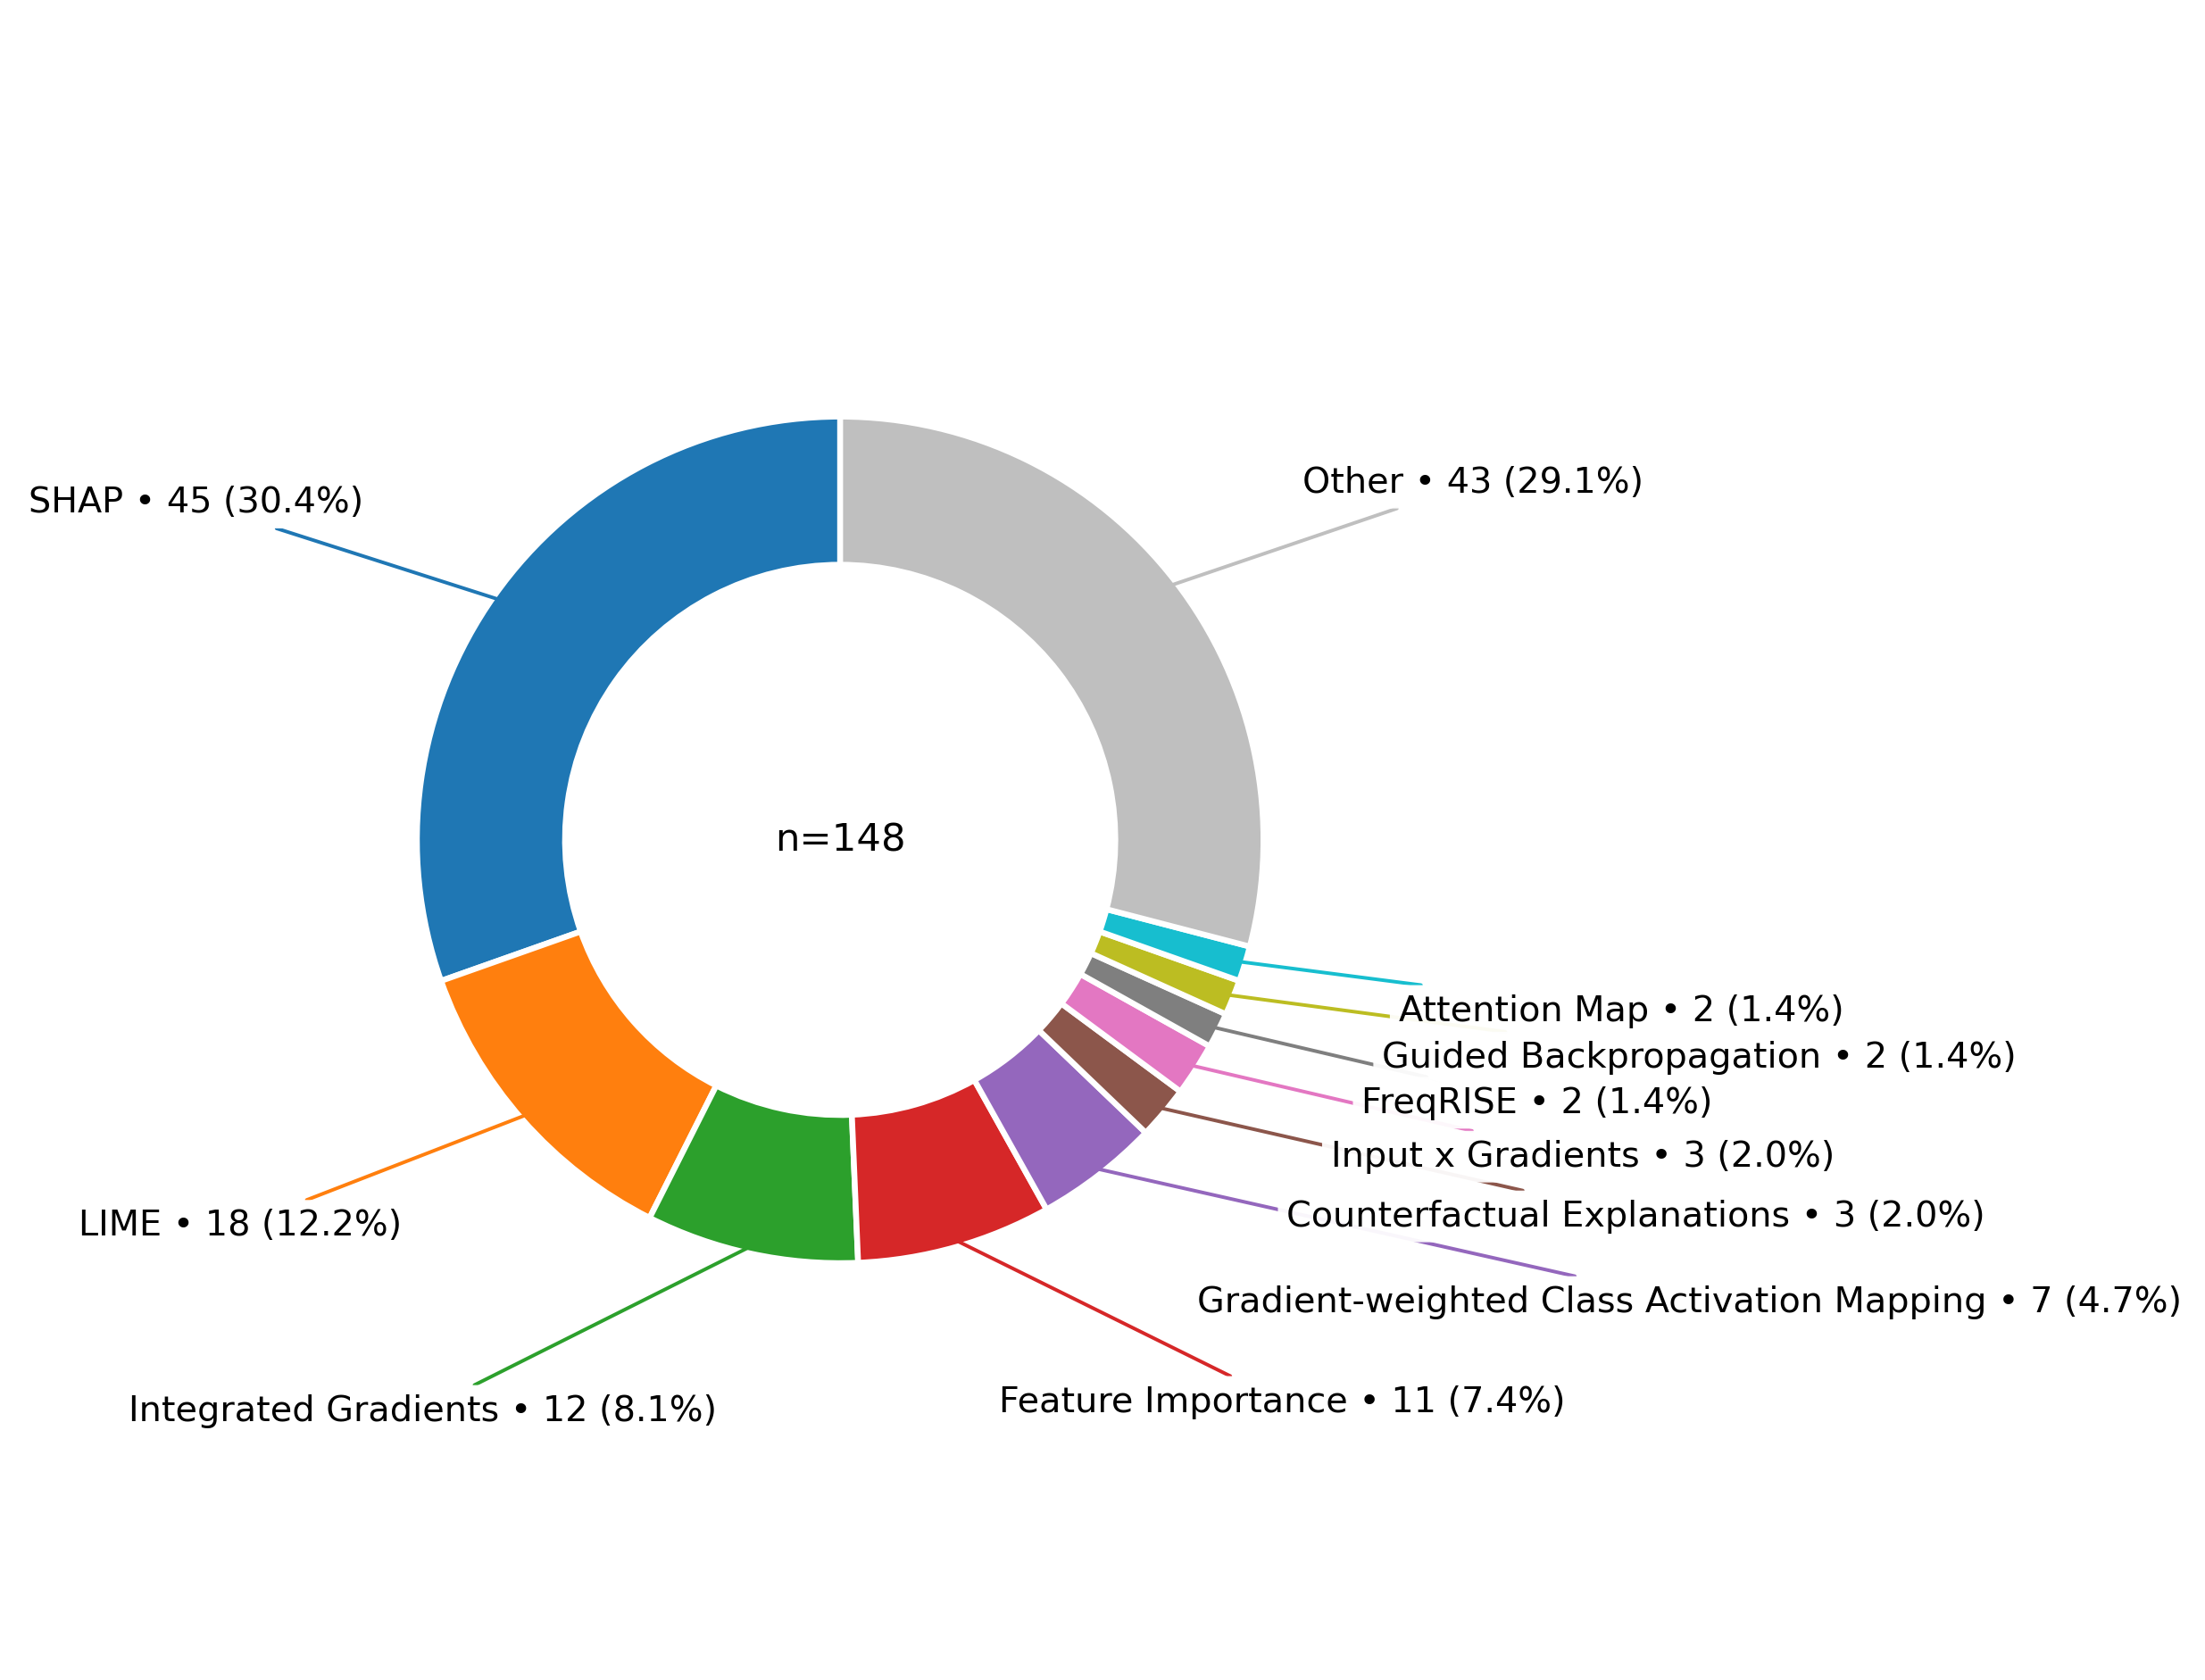

Saved to: figure7.png
                                            Count  Percent
XAI Technique(s)                                          
SHAP                                           45    30.41
LIME                                           18    12.16
Integrated Gradients                           12     8.11
Feature Importance                             11     7.43
Gradient-weighted Class Activation Mapping      7     4.73
Counterfactual Explanations                     3     2.03
Input x Gradients                               3     2.03
FreqRISE                                        2     1.35
Guided Backpropagation                          2     1.35
Attention Map                                   2     1.35
Other                                          43    29.05


In [31]:
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import cycle, islice
from datetime import datetime

# Config
PREFERRED_COLS = ["XAI Technique(s)"]  # tries in this order
MIN_PERCENT = 2.0    # (optional) group slices smaller than this % into "Other" AFTER top-k (set to 0 to disable)
TOP_K = 10           # show at most top-k categories; rest -> "Other"
SAVE_PATH = None


def _pick_categorical_column(df):
    # simple helper (uses preferred list, else first object/string col)
    for c in PREFERRED_COLS:
        if c in df.columns:
            return c
    for c in df.columns:
        if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]):
            return c
    raise ValueError("No suitable categorical column found.")


def pie_from_column_labeled(
    df,
    column=None,
    top_k=TOP_K,
    min_percent=MIN_PERCENT,
    save_path=SAVE_PATH,
    ring_width=0.35,
    label_radius=1.38,      # farther out = fewer collisions
    min_gap=0.085,          # larger vertical spacing between labels
    dpi_fig=260,
    dpi_save=450,
):
    if column is None:
        column = _pick_categorical_column(df)

    # clean
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()
    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    counts = s.value_counts().sort_values(ascending=False)

    # keep top-k, rest -> Other
    if top_k is not None and top_k > 0:
        counts_wo_other = counts.drop(labels=["Other"], errors="ignore")
        top = counts_wo_other.head(top_k)
        rest = counts_wo_other.iloc[top_k:]

        other_sum = int(rest.sum()) + int(counts.get("Other", 0))
        plot_counts = top.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum
    else:
        plot_counts = counts.copy()

    # optional: also collapse tiny slices into Other (after top-k)
    if min_percent and min_percent > 0 and len(plot_counts) > 1:
        total_plot_pre = plot_counts.sum()
        thresh = min_percent / 100.0

        # don't collapse "Other" itself in this pass
        non_other = plot_counts.drop(labels=["Other"], errors="ignore")
        small = non_other[non_other / total_plot_pre < thresh]
        big = non_other[non_other / total_plot_pre >= thresh]

        other_existing = int(plot_counts.get("Other", 0))
        other_sum = other_existing + int(small.sum())

        plot_counts = big.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum

    # stable order: keep counts order, ensure Other last
    if "Other" in plot_counts.index:
        non_other = plot_counts.drop("Other")
        plot_counts = pd.concat([non_other, plot_counts.loc[["Other"]]])

    labels = plot_counts.index.tolist()
    values = plot_counts.values
    total_plot = values.sum()

    # colors (Other -> gray)
    base_cycle = plt.rcParams.get("axes.prop_cycle", None)
    base_colors = base_cycle.by_key().get("color", []) if base_cycle else []
    if not base_colors:
        base_colors = [plt.cm.tab20(i) for i in range(20)]

    colors = list(islice(cycle(base_colors), len(labels)))
    for i, lab in enumerate(labels):
        if str(lab).strip().casefold() == "other":
            colors[i] = (0.75, 0.75, 0.75, 1.0)

    # plot donut
    fig, ax = plt.subplots(figsize=(9.5, 9.5), dpi=dpi_fig)
    wedges, _ = ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={
            "linewidth": 1.8,
            "edgecolor": "white",
            "width": ring_width,
            "antialiased": True,
        },
    )
    ax.set_aspect("equal")

    # initial label targets
    info = []
    for w, lab, val, col in zip(wedges, labels, values, colors):
        ang = (w.theta2 + w.theta1) / 2.0
        rad = np.deg2rad(ang)
        x, y = np.cos(rad), np.sin(rad)
        info.append({
            "w": w,
            "lab": lab,
            "txt": f"{lab} • {val} ({val/total_plot*100:.1f}%)",
            "val": val,
            "col": col,
            "x": x,
            "y": y,
        })

    # distribute per side with bigger minimum gap
    def _spread(side, R, gap):
        side.sort(key=lambda d: d["y"])
        ys = [d["y"] * R for d in side]

        for i in range(1, len(ys)):
            if ys[i] - ys[i - 1] < gap:
                ys[i] = ys[i - 1] + gap

        if ys:
            offset = 0.0
            hi = R
            lo = -R
            if ys[-1] > hi:
                offset = hi - ys[-1]
            if ys[0] < lo:
                offset = max(offset, lo - ys[0])
            ys = [y + offset for y in ys]

        for d, yv in zip(side, ys):
            sgn = 1 if d["x"] >= 0 else -1
            d["y_lab"] = yv
            d["x_lab"] = sgn * np.sqrt(max(R**2 - yv**2, 1e-6))
            d["ha"] = "left" if sgn > 0 else "right"

    right = [d for d in info if d["x"] >= 0]
    left  = [d for d in info if d["x"] < 0]
    _spread(right, label_radius, min_gap)
    _spread(left,  label_radius, min_gap)

    # draw annotations
    extras = []
    r_outer = 1.0
    for d in info:
        x_end, y_end = 0.98 * r_outer * d["x"], 0.98 * r_outer * d["y"]
        ann = ax.annotate(
            d["txt"],
            xy=(x_end, y_end),
            xytext=(d["x_lab"], d["y_lab"]),
            ha=d["ha"],
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.95),
            arrowprops=dict(arrowstyle="-", lw=1.1, color=d["col"], shrinkA=0, shrinkB=0),
        )
        extras.append(ann)

    # center total
    extras.append(ax.text(0, 0, f"n={total}", ha="center", va="center", fontsize=12))

    # spacious limits so labels never clip
    pad = 0.55
    lim = label_radius + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.tight_layout()

    # autosave if not provided
    if not save_path:
        save_path = "figure7.png"

    fig.savefig(
        save_path,
        dpi=dpi_save,
        bbox_inches="tight",
        bbox_extra_artists=extras,
        pad_inches=0.6,
    )
    plt.show()

    summary = plot_counts.to_frame("Count")
    summary["Percent"] = (summary["Count"] / total_plot * 100).round(2)
    return summary, save_path


# run
summary, path = pie_from_column_labeled(
    df_xai,
    column="XAI Technique(s)",
    top_k=10,        # top10 + Other
    min_percent=0.0  # set to e.g. 2.0 if you ALSO want tiny slices merged into Other
)
print("Saved to:", path)
print(summary.head(15))


# Keep the original XAI plotting function for Appendix Figures B3 and B5.
plot_xai_distribution = pie_from_column_labeled

## Table 7 — Frequently used XAI techniques and financial share

**Original source:** `paper_ml_xai_investigation.ipynb`, `xai_technique_full_list_with_finance_split_refs`.

**How it is produced:** XAI instances are counted, finance counts are obtained from finance-domain rows, and the financial share is calculated per method.

The same full code-generated output is used for Appendix **C.2**, which is numbered **Table C10** in the current PDF.

In [33]:
import pandas as pd
import re
import csv

def xai_technique_full_list_with_finance_split_refs(
    df,
    column="XAI Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || ",
):
    # Clean XAI technique column
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()

    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    # Base count table
    table = s.value_counts().rename("Count").to_frame()
    table["Percent"] = (table["Count"] / total * 100).round(2)

    # Required columns
    for c in (field_col, author_col):
        if c not in df.columns:
            raise KeyError(f"df must contain '{c}'.")

    # Align cleaned columns with df rows
    tech_clean = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    tech_clean = pd.Series(tech_clean, dtype="object")
    tech_clean = tech_clean.where(
        ~tech_clean.fillna("").str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings),
        other=None
    )

    field_clean = df[field_col].map(lambda x: "" if pd.isna(x) else str(x).strip())
    is_finance = field_clean.str.casefold().eq(finance_label)

    authors_clean = df[author_col].map(lambda x: None if pd.isna(x) else str(x).strip())
    authors_clean = pd.Series(authors_clean, dtype="object").replace({"": None})

    # Finance counts per technique
    finance_counts = tech_clean[is_finance].dropna().value_counts()
    table["Finance Count"] = table.index.map(lambda t: int(finance_counts.get(t, 0)))
    table["Finance Share %"] = (table["Finance Count"] / table["Count"] * 100).round(2)

    # Split references
    fin_refs = {}
    nonfin_refs = {}

    for tech, is_fin, auth in zip(tech_clean, is_finance, authors_clean):
        if tech is None or auth is None:
            continue

        target = fin_refs if is_fin else nonfin_refs
        target.setdefault(tech, [])
        if auth not in target[tech]:
            target[tech].append(auth)

    table["Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(fin_refs.get(t, []))
    )
    table["Non-Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(nonfin_refs.get(t, []))
    )

    table.index.name = column
    return table.reset_index(), total




xai_table, n_total_xai = xai_technique_full_list_with_finance_split_refs(
    df_xai,
    column="XAI Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || "
)

_table7_names = [
    "SHAP",
    "LIME",
    "Integrated Gradients",
    "Feature Importance",
    "Gradient-weighted Class Activation Mapping",
    "Input x Gradients",
    "Counterfactual Explanations",
    "Saliency",
    "Attention Map",
]
table7 = xai_table[xai_table["XAI Technique(s)"].isin(_table7_names)].copy()
table7["XAI Technique"] = table7["XAI Technique(s)"].replace({
    "Gradient-weighted Class Activation Mapping": "Grad-CAM",
    "Input x Gradients": "Input × Gradients",
})
table7["Financial Share"] = table7["Finance Share %"].round(0).astype(int).astype(str) + "%"
table7 = table7[["XAI Technique", "Count", "Financial Share"]].rename(columns={"Count": "Total Studies"})
table7["__order"] = table7["XAI Technique"].map({v:i for i,v in enumerate([
    "SHAP","LIME","Integrated Gradients","Feature Importance","Grad-CAM",
    "Input × Gradients","Counterfactual Explanations","Saliency","Attention Map"
])})
table7 = table7.sort_values("__order").drop(columns="__order").reset_index(drop=True)
display(table7)

# Appendix C.2 is Table C10 in the current PDF.
table_c10 = xai_table[[
    "XAI Technique(s)", "Count", "Finance Count", "Finance Share %",
    "Non-Financial References (Authors)", "Financial References (Authors)"
]].copy()
display(table_c10)

table_c10.to_csv(
    "table7.csv",
    index=False
)

,XAI Technique,Total Studies,Financial Share
0,SHAP,45,13%
1,LIME,18,28%
2,Integrated Gradients,12,8%
3,Feature Importance,11,45%
4,Grad-CAM,7,0%
5,Input × Gradients,3,0%
6,Counterfactual Explanations,3,0%
7,Saliency,2,0%
8,Attention Map,2,0%


,XAI Technique(s),Count,Finance Count,Finance Share %,Non-Financial References (Authors),Financial References (Authors)
0,SHAP,45,6,13.33,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....","Parente, M.; Rizzuti, L.; Trerotola, M. || Val..."
1,LIME,18,5,27.78,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....","Valensky, D.; Mohaghegh, M. || Deng, S.; Zhu, ..."
2,Integrated Gradients,12,1,8.33,"Nguyen, T.T.; Le Nguyen, T.; Ifrim, G. || Iqba...","Freeborough, W.; van Zyl, T."
3,Feature Importance,11,5,45.45,"Doddaiah, R.; Parvatharaju, P.S.; Rundensteine...","Park, H.J.; Kim, Y.; Kim, H.Y. || Valensky, D...."
4,Gradient-weighted Class Activation Mapping,7,0,0.00,"Kuo, C.-H.; Liu, G.-T.; Lee, C.-E.; Wu, J.; Ca...",
5,Counterfactual Explanations,3,0,0.00,"Sweidan, J.; El-Yacoubi, M.A.; Rigaud, A.-S. |...",
6,Input x Gradients,3,0,0.00,"Najjar, H.; Miranda, M.; Nuske, M.; Roscher, R...",
7,Layer-wise Relevance Propogation,2,0,0.00,"Vielhaben, J.; Lapuschkin, S.; Montavon, G.; S...",
8,Saliency,2,0,0.00,"Kuo, C.-H.; Liu, G.-T.; Lee, C.-E.; Wu, J.; Ca...",
9,Feature Ablation,2,0,0.00,"Cao, Fanpu; Yang, Shu; Chen, Zhengjian; Liu, Y...",


## Figure 8 — Sankey: XAI technique → domain → finance subdomain → finance XAI technique

**Original source:** `paper_ml_xai_investigation.ipynb`, XAI Sankey cell.

**How it is produced:** the XAI analogue of Figure 6. Count matrices determine the flow widths from XAI techniques to broader domains and, for finance, to finance subdomains and finance-specific XAI-technique nodes.

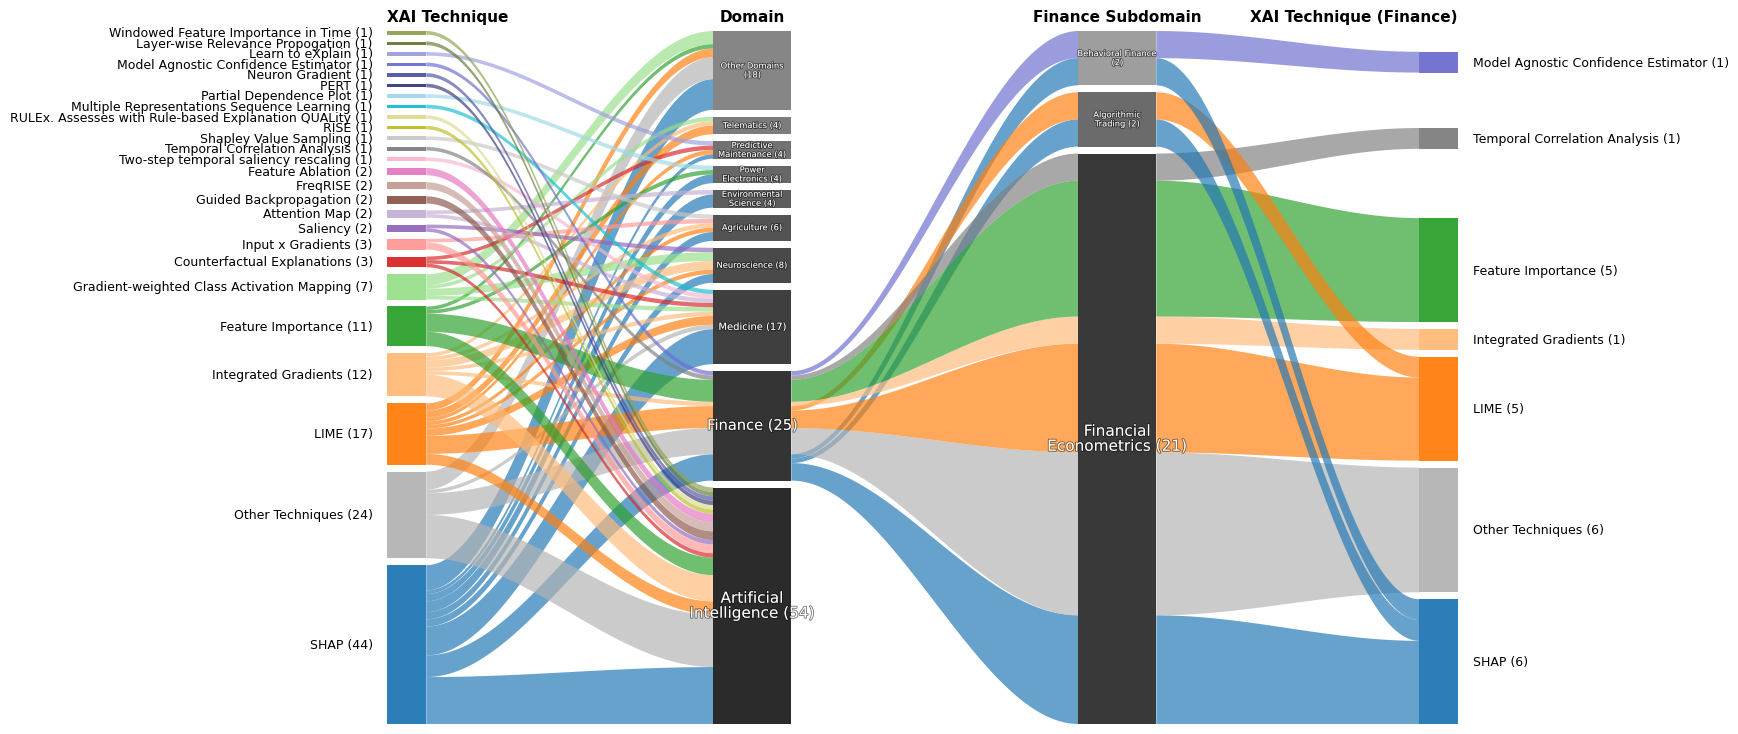

Saved: figure8.png


In [35]:
# Sankey: XAI Technique (ALL) → Domain (ALL) → Finance Subdomain → XAI Technique (Finance-only)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib import patheffects as pe
from datetime import datetime
import textwrap

# Config
TOP_TECH = 25
TOP_DOM  = 9
TOP_SPEC = 20

OTHER_TECH_LABEL = "Other Techniques"
OTHER_DOM_LABEL  = "Other Domains"
OTHER_SPEC_LABEL = "Other Finance"

BAR_W = 0.032
GAP = 0.01
LEFT_PAD, RIGHT_PAD = 0.012, 0.012
ALPHA_RIBBON, ALPHA_BAR = 0.68, 0.95

# Label rendering inside bars
DOMAIN_WRAP_CHARS = 16
SPEC_WRAP_CHARS   = 18
MIN_FONT_SIZE     = 6
MAX_FONT_SIZE     = 11
MIN_HEIGHT_FOR_TEXT = 0.018

# Safety checks
if "df_xai_exp" not in globals() or not isinstance(df_xai_exp, pd.DataFrame):
    raise NameError("df_xai_exp must be a pandas DataFrame in the current session.")

XAI_COL = "XAI Techniques Expanded" if "XAI Techniques Expanded" in df_xai_exp.columns else "XAI Technique(s)"
DOMAIN_COL = "Domain"
SPEC_COL = "Specific Domain (Finance only)"
FIN_LABEL = "Finance"

for c in [XAI_COL, DOMAIN_COL]:
    if c not in df_xai_exp.columns:
        raise KeyError(f"Missing required column: {c}")

# Prep / Clean
df_all = df_xai_exp.copy()

def _clean_col(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"<NA>": "", "<na>": "", "nan": "", "NaN": ""})
    return s.fillna("")

df_all[XAI_COL] = _clean_col(df_all[XAI_COL])
df_all[DOMAIN_COL] = _clean_col(df_all[DOMAIN_COL])
df_all[SPEC_COL] = _clean_col(df_all[SPEC_COL]) if SPEC_COL in df_all.columns else ""

df_all = df_all[(df_all[XAI_COL] != "") & (df_all[DOMAIN_COL] != "")]
if df_all.empty:
    raise ValueError(f"No rows with non-empty '{XAI_COL}' and '{DOMAIN_COL}'.")

# Finance-only subset
df_fin = df_all[df_all[DOMAIN_COL].str.casefold().eq(FIN_LABEL.casefold())].copy()
if df_fin.empty:
    raise ValueError("No Finance rows found. Sankey requires finance rows for the right legs.")
df_fin["__Spec"] = np.where(df_fin[SPEC_COL] != "", df_fin[SPEC_COL], "Finance (Unspecified)")

# Reduce cardinality
# Techniques
tech_tot_all = df_all.groupby(XAI_COL).size().sort_values(ascending=False)
tech_keep = tech_tot_all.index[:TOP_TECH].tolist() if len(tech_tot_all) > TOP_TECH else tech_tot_all.index.tolist()
df_all["__TechRed"] = np.where(df_all[XAI_COL].isin(tech_keep), df_all[XAI_COL], OTHER_TECH_LABEL)
df_fin["__TechRed"] = np.where(df_fin[XAI_COL].isin(tech_keep), df_fin[XAI_COL], OTHER_TECH_LABEL)

# Domains (TOP 9 + Other)
dom_tot_all = df_all.groupby(DOMAIN_COL).size().sort_values(ascending=False)
dom_keep = dom_tot_all.index[:TOP_DOM].tolist() if len(dom_tot_all) > TOP_DOM else dom_tot_all.index.tolist()
df_all["__DomRed"] = np.where(df_all[DOMAIN_COL].isin(dom_keep), df_all[DOMAIN_COL], OTHER_DOM_LABEL)
df_fin["__DomRed"] = np.where(df_fin[DOMAIN_COL].isin(dom_keep), df_fin[DOMAIN_COL], OTHER_DOM_LABEL)

# Finance subdomains
spec_tot_all_fin = df_fin.groupby("__Spec").size().sort_values(ascending=False)
spec_keep = spec_tot_all_fin.index[:TOP_SPEC].tolist() if len(spec_tot_all_fin) > TOP_SPEC else spec_tot_all_fin.index.tolist()
df_fin["__SpecRed"] = np.where(df_fin["__Spec"].isin(spec_keep), df_fin["__Spec"], OTHER_SPEC_LABEL)

# Flow tables
flows_T_D = df_all.groupby(["__TechRed", "__DomRed"]).size().unstack(fill_value=0)
flows_T_S_fin = df_fin.groupby(["__TechRed", "__SpecRed"]).size().unstack(fill_value=0)

# Node totals & orders
tech_tot_left = flows_T_D.sum(axis=1).sort_values(ascending=False)
dom_totals    = flows_T_D.sum(axis=0).sort_values(ascending=False)

# order: keep "Other Domains" last
dom_order = dom_totals.index.tolist()
if OTHER_DOM_LABEL in dom_order:
    dom_order = [d for d in dom_order if d != OTHER_DOM_LABEL] + [OTHER_DOM_LABEL]
flows_T_D = flows_T_D.reindex(index=tech_tot_left.index, columns=dom_order, fill_value=0)

spec_totals = flows_T_S_fin.sum(axis=0).sort_values(ascending=False)

# order: keep "Other Finance" last
spec_order = spec_totals.index.tolist()
if OTHER_SPEC_LABEL in spec_order:
    spec_order = [s for s in spec_order if s != OTHER_SPEC_LABEL] + [OTHER_SPEC_LABEL]
flows_T_S_fin = flows_T_S_fin.reindex(index=tech_tot_left.index, columns=spec_order, fill_value=0)

# right-tech totals align to ALL-tech order
tech_tot_right = flows_T_S_fin.sum(axis=1).reindex(tech_tot_left.index, fill_value=0)

tech_labels = tech_tot_left.index.tolist()
dom_labels  = flows_T_D.columns.tolist()
spec_labels = flows_T_S_fin.columns.tolist()
tech_right_labels = tech_labels[:]  # same order on the right

# Colors
def make_color_map(labels):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])
    if len(colors) < len(labels):
        need = len(labels) - len(colors)
        hsv = plt.get_cmap("hsv", need + 1)
        colors.extend([hsv(i) for i in range(need)])
    mapping = {lab: colors[i] for i, lab in enumerate(labels)}
    if OTHER_TECH_LABEL in mapping:
        mapping[OTHER_TECH_LABEL] = (0.7, 0.7, 0.7, 1.0)
    return mapping

color_by_tech = make_color_map(tech_labels)

def greyscale_list(n, lo=0.12, hi=0.55):
    if n <= 0:
        return []
    vals = np.linspace(lo, hi, n)
    return [(v, v, v, 1.0) for v in vals]

domain_colors = {d: c for d, c in zip(dom_labels, greyscale_list(len(dom_labels), lo=0.12, hi=0.50))}
spec_colors   = {s: c for s, c in zip(spec_labels, greyscale_list(len(spec_labels), lo=0.18, hi=0.60))}

# Layout helpers
def stack_positions(values, total_height=1.0, gap=GAP):
    vals = np.asarray(values, dtype=float)
    s = vals.sum()
    usable = max(total_height - gap * max(len(vals) - 1, 0), 0.0)
    heights = np.zeros_like(vals) if s <= 0 else (vals / s) * usable
    y0, y = [], 0.0
    for h in heights:
        y0.append(y)
        y += h + gap
    y0 = np.array(y0)
    y1 = y0 + heights
    return y0, y1, heights

def cubic_bezier(P0, P1, P2, P3, ts):
    ts = np.asarray(ts)[:, None]
    return ((1-ts)**3)*P0 + 3*((1-ts)**2)*ts*P1 + 3*(1-ts)*(ts**2)*P2 + (ts**3)*P3

def draw_ribbon(ax, x0, y0_top, y0_bot, x1, y1_top, y1_bot, color, curvature=0.35, n=100, alpha=ALPHA_RIBBON):
    P0 = np.array([x0, y0_top]);  P3 = np.array([x1, y1_top]);  dx = x1 - x0
    P1 = P0 + np.array([dx*curvature, 0.0]);  P2 = P3 - np.array([dx*curvature, 0.0])
    ts = np.linspace(0, 1, n)
    top = cubic_bezier(P0, P1, P2, P3, ts)

    P0b = np.array([x0, y0_bot]);  P3b = np.array([x1, y1_bot])
    P1b = P0b + np.array([dx*curvature, 0.0]);  P2b = P3b - np.array([dx*curvature, 0.0])
    bot = cubic_bezier(P0b, P1b, P2b, P3b, ts)

    verts = np.vstack([top, bot[::-1], top[:1]])
    codes = [Path.MOVETO] + [Path.LINETO]*(top.shape[0]-1) + [Path.LINETO]*bot.shape[0] + [Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts, codes), lw=0, facecolor=color, alpha=alpha))

# Label bars: max 2 lines, adaptive wrap, ellipsis if too long
def draw_labeled_bar(ax, x_left, y0, height, width, facecolor, label, wrap_chars=14):
    if height <= 0:
        return

    ax.add_patch(Rectangle((x_left, y0), width, height, lw=0,
                           facecolor=facecolor, alpha=ALPHA_BAR))

    if height < MIN_HEIGHT_FOR_TEXT or not label:
        return

    base = max(8, int(round(wrap_chars * (width / (2 * BAR_W)))))
    wrap = int(np.clip(base, 8, 26))

    lines = textwrap.wrap(label, width=wrap) or [label]
    if len(lines) > 2:
        lines = lines[:2]
        if len(lines[1]) >= 2:
            lines[1] = lines[1][:-1] + "…"

    txt = "\n".join(lines)

    fs = (height * 120) / (len(lines) + 0.8)
    fs = float(np.clip(fs, MIN_FONT_SIZE, MAX_FONT_SIZE))

    t = ax.text(
        x_left + width/2, y0 + height/2, txt,
        ha="center", va="center", fontsize=fs, color="white",
        clip_on=True, linespacing=1.0
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground=(0, 0, 0, 0.55))])

# Domain label formatting (FORCE AI to show fully with count)
def domain_label_text(dom: str, count: int) -> str:
    dom_str = str(dom)
    if dom_str == "Artificial Intelligence":
        # forced break ensures "(n)" stays visible and no truncation occurs
        return f"Artificial\nIntelligence ({count})"
    return f"{dom_str} ({count})"

# Positions
x0, x1, x2, x3 = 0.06, 0.36, 0.66, 0.94

yl0, yl1, hl = stack_positions(tech_tot_left.values)
ym0, ym1, hm = stack_positions(flows_T_D.sum(axis=0).values)
ys0, ys1, hs = stack_positions(spec_totals.values)
yr0, yr1, hr = stack_positions(tech_tot_right.values)

# Slices for ribbons 
slice_TD_left, slice_TD_right = {}, {}

for i, tech in enumerate(tech_labels):
    total_i, y = tech_tot_left.values[i], yl0[i]
    if total_i <= 0:
        continue
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_i == 0 else (f / total_i) * hl[i]
        slice_TD_left[(tech, dom)] = (y + h, y)
        y += h

for j, dom in enumerate(dom_labels):
    total_j, y = flows_T_D[dom].sum(), ym0[j]
    if total_j <= 0:
        continue
    for tech in tech_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_j == 0 else (f / total_j) * hm[j]
        slice_TD_right[(tech, dom)] = (y + h, y)
        y += h

slice_FS_left, slice_FS_right = {}, {}
slice_ST_left, slice_ST_right = {}, {}

if FIN_LABEL in dom_labels:
    # B left: Finance segment split by subdomain
    for tech in tech_labels:
        seg = slice_TD_right.get((tech, FIN_LABEL))
        tech_fin_total = flows_T_D.loc[tech, FIN_LABEL] if FIN_LABEL in flows_T_D.columns else 0
        if (not seg) or tech_fin_total <= 0:
            continue
        seg_top, seg_bot = seg
        seg_h = seg_top - seg_bot
        y = seg_bot
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * seg_h
            slice_FS_left[(tech, spec)] = (y + h, y)
            y += h

    # B right: stack incoming techniques for each subdomain
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_FS_right[(tech, spec)] = (y + h, y)
            y += h

    # C left/right: subdomain -> right-tech
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_right_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_ST_left[(spec, tech)] = (y + h, y)
            y += h

    for i, tech in enumerate(tech_right_labels):
        tech_fin_total, y = tech_tot_right.loc[tech], yr0[i]
        if tech_fin_total <= 0:
            continue
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * hr[i]
            slice_ST_right[(spec, tech)] = (y + h, y)
            y += h

# Plot
fig, ax = plt.subplots(figsize=(15.7, 9.0))
for s in ax.spines.values():
    s.set_visible(False)
ax.set_axis_off()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# A) Technique → Domain (ALL)
for tech in tech_labels:
    col = color_by_tech[tech]
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        if f <= 0:
            continue
        yL_top, yL_bot = slice_TD_left[(tech, dom)]
        yR_top, yR_bot = slice_TD_right[(tech, dom)]
        draw_ribbon(ax, x0 + BAR_W, yL_top, yL_bot, x1 - BAR_W, yR_top, yR_bot, color=col)

# B) Finance → Subdomain
if FIN_LABEL in dom_labels:
    for tech in tech_labels:
        for spec in spec_labels:
            key = (tech, spec)
            if key not in slice_FS_left or key not in slice_FS_right:
                continue
            yL_top, yL_bot = slice_FS_left[key]
            yR_top, yR_bot = slice_FS_right[key]
            draw_ribbon(ax, x1 + BAR_W, yL_top, yL_bot, x2 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# C) Subdomain → Technique (right)
for spec in spec_labels:
    for tech in tech_right_labels:
        key = (spec, tech)
        if key not in slice_ST_left or key not in slice_ST_right:
            continue
        yL_top, yL_bot = slice_ST_left[key]
        yR_top, yR_bot = slice_ST_right[key]
        draw_ribbon(ax, x2 + BAR_W, yL_top, yL_bot, x3 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# Bars: Left techniques
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.add_patch(Rectangle((x0, yl0[i]), BAR_W, hl[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Bars: Domains (TOP 9 + Other) with AI label forced
for j, dom in enumerate(dom_labels):
    if hm[j] <= 0:
        continue
    count_dom = int(flows_T_D[dom].sum())
    draw_labeled_bar(
        ax,
        x_left=(x1 - BAR_W),
        y0=ym0[j],
        height=hm[j],
        width=2*BAR_W,
        facecolor=domain_colors[dom],
        label=domain_label_text(dom, count_dom),
        wrap_chars=22 if str(dom) == "Artificial Intelligence" else DOMAIN_WRAP_CHARS
    )

# Bars: Finance subdomains
for k, spec in enumerate(spec_labels):
    if hs[k] <= 0:
        continue
    draw_labeled_bar(
        ax,
        x_left=(x2 - BAR_W),
        y0=ys0[k],
        height=hs[k],
        width=2*BAR_W,
        facecolor=spec_colors[spec],
        label=f"{spec} ({int(spec_totals.loc[spec])})",
        wrap_chars=SPEC_WRAP_CHARS
    )

# Bars: Right techniques (touch ribbons)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.add_patch(Rectangle((x3 - BAR_W, yr0[i]), BAR_W, hr[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Left technique labels
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.text(x0 - LEFT_PAD, (yl0[i] + yl1[i]) / 2, f"{tech} ({int(tech_tot_left.loc[tech])})",
                ha="right", va="center", fontsize=9, clip_on=False)

# Right technique labels (skip zeros to reduce clutter)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.text(x3 + RIGHT_PAD, (yr0[i] + yr1[i]) / 2, f"{tech} ({int(tech_tot_right.loc[tech])})",
                ha="left", va="center", fontsize=9, clip_on=False)

# Column titles
ax.text(x0, 1.01, "XAI Technique",           ha="left",   va="bottom", fontsize=11, weight="bold")
ax.text(x1, 1.01, "Domain",                  ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x2, 1.01, "Finance Subdomain",       ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x3, 1.01, "XAI Technique (Finance)", ha="right",  va="bottom", fontsize=11, weight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

png_path = f"figure8.png"
fig.savefig(png_path, dpi=1000, bbox_inches="tight")
print(f"Saved: {png_path}")

## Figure 9 — ML × XAI co-occurrence heatmap

**Original source:** `paper_ml_xai_investigation.ipynb`, pairwise-by-title heatmap cell.

**How it is produced:** for each paper title, unique ML and XAI method lists are collected and their Cartesian product is counted once per pairing. The top 20 ML and XAI categories are retained, with remaining categories grouped as `Other Techniques` / `Other XAI`.

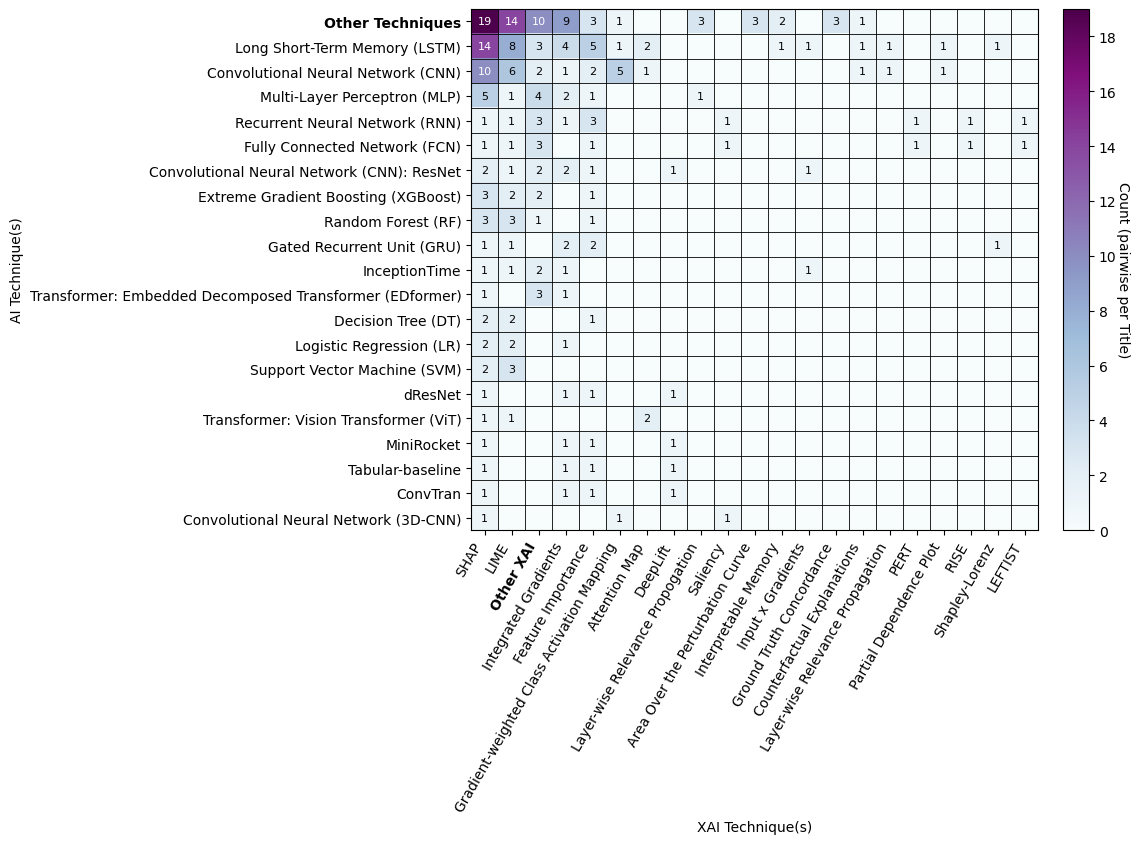

Saved: figure9.pdf


XAI,SHAP,LIME,Other XAI,Integrated Gradients,Feature Importance,Gradient-weighted Class Activation Mapping,Attention Map,DeepLift,Layer-wise Relevance Propogation,Saliency,...,Interpretable Memory,Input x Gradients,Ground Truth Concordance,Counterfactual Explanations,Layer-wise Relevance Propagation,PERT,Partial Dependence Plot,RISE,Shapley-Lorenz,LEFTIST
ML,,,,,,,,,,,,,,,,,,,,,
Other Techniques,19.0,14.0,10.0,9.0,3.0,1.0,0.0,0.0,3.0,0.0,...,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Long Short-Term Memory (LSTM),14.0,8.0,3.0,4.0,5.0,1.0,2.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
Convolutional Neural Network (CNN),10.0,6.0,2.0,1.0,2.0,5.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Multi-Layer Perceptron (MLP),5.0,1.0,4.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recurrent Neural Network (RNN),1.0,1.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Fully Connected Network (FCN),1.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Convolutional Neural Network (CNN): ResNet,2.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Extreme Gradient Boosting (XGBoost),3.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Random Forest (RF),3.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# Heatmap: ML Techniques × XAI Techniques (pairwise within each Title)
# - Makes "Other Techniques" (row) and "Other XAI" (column) bold in tick labels
# Pure matplotlib (no seaborn).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
import re

# Config 
TOP_TECH = 20    # keep top-N ML techniques; others -> "Other Techniques" (None to disable)
TOP_XAI  = 20    # keep top-M XAI techniques; others -> "Other XAI" (None to disable)
ANNOTATE = True  # write integer counts in cells
ROT      = 60    # x-label rotation in degrees
CMAP     = plt.cm.BuPu

# Optional Title filtering
TITLE_EXACT  = None                 # e.g., "A Specific Paper" or ["Paper A","Paper B"]
TITLE_SUBSTR = None                 # e.g., "finance" or ["loan","credit"]

# Prep 
if "df_xai_exp" not in globals() or not isinstance(df_xai_exp, pd.DataFrame):
    raise NameError("df_xai_exp must be a pandas DataFrame in the current session.")

XAI_COL = "XAI Techniques Expanded" if "XAI Techniques Expanded" in df_xai_exp.columns else "XAI Technique(s)"
for c in ["Title_zotero", "ML Technique(s)", XAI_COL]:
    if c not in df_xai_exp.columns:
        raise KeyError(f"Missing column in df_xai_exp: {c}")

df = df_xai_exp.copy()
df["Title_zotero"]     = df["Title_zotero"].astype("string").str.strip().replace({"<NA>": ""}).fillna("")
df["ML Technique(s)"]  = df["ML Technique(s)"].astype("string").str.strip().replace({"<NA>": ""}).fillna("")
df[XAI_COL]            = df[XAI_COL].astype("string").str.strip().replace({"<NA>": ""}).fillna("")

# Title filters
if TITLE_EXACT is not None:
    if isinstance(TITLE_EXACT, str):
        TITLE_EXACT = [TITLE_EXACT]
    df = df[df["Title_zotero"].isin(TITLE_EXACT)]

if TITLE_SUBSTR is not None:
    if isinstance(TITLE_SUBSTR, str):
        TITLE_SUBSTR = [TITLE_SUBSTR]
    pats = [re.compile(re.escape(s), flags=re.I) for s in TITLE_SUBSTR]
    df = df[df["Title_zotero"].apply(lambda t: any(p.search(t or "") for p in pats))]

# Keep rows with all fields
df = df[(df["Title_zotero"] != "") & (df["ML Technique(s)"] != "") & (df[XAI_COL] != "")]
if df.empty:
    raise ValueError("No rows after cleaning/filters. Check 'Title_zotero', 'ML Technique(s)', and XAI column.")

# Build pairwise counts per Title
def _split_list(s):
    s = (s or "").strip()
    if not s:
        return []
    parts = [p.strip() for p in s.split(",")]
    # de-dup while preserving order
    seen, out = set(), []
    for p in parts:
        k = p.lower()
        if p and k not in seen:
            seen.add(k)
            out.append(p)
    return out

def _dedup(seq):
    seen, out = set(), []
    for p in seq:
        k = p.lower()
        if p and k not in seen:
            seen.add(k)
            out.append(p)
    return out

edges = []
for title, sub in df.groupby("Title_zotero"):
    mls, xais = [], []
    for _, r in sub.iterrows():
        mls.extend(_split_list(r["ML Technique(s)"]))
        xais.extend(_split_list(r[XAI_COL]))
    mls  = _dedup(mls)
    xais = _dedup(xais)
    if not mls or not xais:
        continue
    edges.extend([(m, x, 1.0) for m in mls for x in xais])

edges_df = pd.DataFrame(edges, columns=["ML", "XAI", "w"])
if edges_df.empty:
    raise ValueError("No ML↔XAI pairs were formed. Do the selected titles contain both fields?")

flows = edges_df.groupby(["ML", "XAI"])["w"].sum().unstack(fill_value=0)

# Optional top-N caps
OTHER_TECH_LABEL = "Other Techniques"
OTHER_XAI_LABEL  = "Other XAI"

# rows (ML)
if TOP_TECH is not None and len(flows.index) > TOP_TECH:
    tech_tot = flows.sum(axis=1).sort_values(ascending=False)
    keep = tech_tot.index[:TOP_TECH]
    other_row = flows.loc[~flows.index.isin(keep)].sum(axis=0)
    flows = flows.loc[flows.index.isin(keep)]
    if other_row.sum() > 0:
        flows.loc[OTHER_TECH_LABEL] = other_row

# cols (XAI)
if TOP_XAI is not None and len(flows.columns) > TOP_XAI:
    xai_tot = flows.sum(axis=0).sort_values(ascending=False)
    keep = xai_tot.index[:TOP_XAI]
    other_col = flows.loc[:, ~flows.columns.isin(keep)].sum(axis=1)
    flows = flows.loc[:, flows.columns.isin(keep)]
    if other_col.sum() > 0:
        flows[OTHER_XAI_LABEL] = other_col

# Reorder by totals for readability
flows = flows.loc[
    flows.sum(axis=1).sort_values(ascending=False).index,
    flows.sum(axis=0).sort_values(ascending=False).index
]

# Plot
n_rows, n_cols = flows.shape
fig_w = max(8, min(22, 2 + 0.45 * n_cols))
fig_h = max(4.5, min(18, 1.2 + 0.35 * n_rows))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(
    flows.values,
    aspect="auto",
    interpolation="nearest",
    cmap=CMAP,
    vmin=0,
    vmax=max(1, flows.values.max())
)

# ticks & labels
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(list(flows.columns), rotation=ROT, ha="right")
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(list(flows.index))

# Make "Other ..." tick labels bold
for t in ax.get_xticklabels():
    if t.get_text() == OTHER_XAI_LABEL:
        t.set_fontweight("bold")

for t in ax.get_yticklabels():
    if t.get_text() == OTHER_TECH_LABEL:
        t.set_fontweight("bold")

# subtle gridlines
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color=(0, 0, 0, 0.06), linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# annotations
if ANNOTATE:
    vmax = max(1, flows.values.max())
    for i in range(n_rows):
        for j in range(n_cols):
            v = int(flows.iat[i, j])
            if v > 0:
                ax.text(
                    j, i, str(v),
                    ha="center", va="center",
                    fontsize=8,
                    color=("white" if (v / vmax) > 0.5 else "black")
                )

# colorbar with integer ticks
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Count (pairwise per Title)", rotation=270, labelpad=10)
cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel("XAI Technique(s)")
ax.set_ylabel("AI Technique(s)")

plt.tight_layout()
out_path = "figure9.pdf"
plt.savefig(out_path, dpi=400, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# Optional: get the table back
flows

# Appendix B — publication/source tables

The publication/source appendix tables are derived from the same final corpus. Only the **table calculations** are retained here; the exploratory publication/publisher charts from the working notebook are intentionally omitted because they are not among the requested manuscript figures.

## Tables B3 and B4 — publication type and search database

**Original source:** the publication/source-characteristics cell in `paper_domain_investigation.ipynb`.

**How they are produced:** Zotero `Item Type` values are mapped to the manuscript labels, and the search-source split uses the 20 arXiv-sourced records identified in the original analysis.

In [40]:
_ARXIV_KEYS = [
    "arsenault_survey_2024",
    "cau_supporting_2023",
    "deng_high-frequency_2022",
    "freeborough_investigating_2022",
    "giudici_explainable_2024",
    "mienye_deep_2024",
    "parente_profitable_2024",
    "park_stock_2022",
    "valensky_evaluating_2023",
    "weber_applications_2024",
    "fatemi_finvision_2024",
    "ghimire_timetrail_2023",
    "kumar_opening_2017",
    "matsunaga_exploring_2019",
    "misheva_hypothesis_2023",
    "neri_how_2020",
    "philps_making_2019",
    "sivakumar_hmm-lstm_2025",
    "ye_factor_2024",
    "zhang_asset_2022",
]

_TYPE_LABEL = {
    "journalArticle":  "Journal article",
    "preprint":        "Preprint (arXiv)",
    "conferencePaper": "Conference paper",
    "webpage":         "Webpage (preprint)",
}

_it_col = next(c for c in df_combined.columns if "Item Type" in c or "item type" in c.lower())
df_pub = df_combined[[_it_col]].copy()
df_pub["Publication type"] = df_pub[_it_col].map(_TYPE_LABEL).fillna(df_pub[_it_col])

counts_pub = df_pub["Publication type"].value_counts()
total_pub = len(df_pub)

table_b3 = counts_pub.rename("Papers").to_frame().reset_index().rename(columns={"index": "Publication type"})
table_b3["%"] = (table_b3["Papers"] / total_pub * 100).round(1)
table_b3 = pd.concat([
    table_b3,
    pd.DataFrame([{"Publication type": "Total", "Papers": total_pub, "%": 100.0}])
], ignore_index=True)

table_b4 = pd.DataFrame({
    "Database": ["Scopus", "arXiv", "Total"],
    "Papers": [total_pub - len(_ARXIV_KEYS), len(_ARXIV_KEYS), total_pub],
})
table_b4["%"] = (table_b4["Papers"] / total_pub * 100).round(1)
table_b4.loc[table_b4["Database"].eq("Total"), "%"] = 100.0

display(table_b3)

table_b3.to_csv(
    "table_b3.csv",
    index=False
)

display(table_b4)

table_b4.to_csv(
    "table_b4.csv",
    index=False
)

,Publication type,Papers,%
0,Journal article,60,76.9
1,Preprint (arXiv),12,15.4
2,Conference paper,5,6.4
3,Webpage (preprint),1,1.3
4,Total,78,100.0


,Database,Papers,%
0,Scopus,58,74.4
1,arXiv,20,25.6
2,Total,78,100.0


## Table B5 — publisher characteristics

**Original source:** the publisher-mapping cell in `paper_domain_investigation.ipynb`.

**How it is produced:** journal titles from Zotero are mapped to publishers using the original explicit dictionary. Records without journal metadata are excluded from the publisher table, exactly as in the working analysis. The number of distinct journal titles is calculated per publisher.

Important to know: For Elsevier, 20 unique journals are identified, but it contains *Applied Soft Computing* and *Appl. Soft Compt.*. Hence, this is manually removed with -1. Same goes for MDPI *Appli. Sci.* and *Applied Sciences*.

In [42]:
import matplotlib.pyplot as plt

_PUBLISHER_MAP = {
    "Applied Soft Computing": "Elsevier",
    "Appl. Soft Comput.": "Elsevier",
    "Biomed. Signal Process. Control": "Elsevier",
    "Comput Electr Eng": "Elsevier",
    "Comput Ind Eng": "Elsevier",
    "Comput. Biol. Med.": "Elsevier",
    "Energy Rep.": "Elsevier",
    "Eng Appl Artif Intell": "Elsevier",
    "Expert Systems with Applications": "Elsevier",
    "Heliyon": "Elsevier",
    "Information Fusion": "Elsevier",
    "Intell. Syst. Applications.": "Elsevier",
    "International Journal of Approximate Reasoning": "Elsevier",
    "J Manuf Syst": "Elsevier",
    "J. Neurosci. Methods": "Elsevier",
    "Knowl Based Syst": "Elsevier",
    "NeuroImage": "Elsevier",
    "Neurocomputing": "Elsevier",
    "Pattern Recogn.": "Elsevier",
    "Physica A: Statistical Mechanics and its Applications": "Elsevier",

    "AI (Switzerland)": "MDPI",
    "Appl. Sci.": "MDPI",
    "Applied Sciences (Switzerland)": "MDPI",
    "Brain Sci.": "MDPI",
    "Future Internet": "MDPI",
    "J. Mar. Sci. Eng.": "MDPI",
    "Water": "MDPI",

    "Data Min. Knowl. Discov.": "Springer Nature",
    "Int. J. Data Sci. Anal.": "Springer Nature",
    "Knowl. Inf. Systems. Syst.": "Springer Nature",
    "Management Review Quarterly": "Springer Nature",
    "Neural Comput. Appl.": "Springer Nature",
    "Sci. Rep.": "Springer Nature",

    "IEEE Access": "IEEE",
    "IEEE J. Sel. Top. Appl. Earth Obs. Remote Sens.": "IEEE",
    "IEEE Trans Pattern Anal Mach Intell": "IEEE",
    "IEEE Trans. Mob. Comput.": "IEEE",

    "Frontier. Artif. Intell.": "Frontiers",

    "J Forecast": "Wiley",

    "PLoS ONE": "PLOS",

    "PeerJ Comput. Sci.": "PeerJ",

    "Aust. J. Electr. Electron. Eng.": "Taylor & Francis",

    "SSRG. Int. J. Electron. Commun. Eng.": "Other",
    "Turk. J. Eng.": "Other",
}


# Identify publication title column
_pt_col = next(
    c for c in df_combined.columns
    if "Publication Title" in c or "publication title" in c.lower()
)

# Keep journal articles only
df_j = df_combined[df_combined[_it_col] == "journalArticle"].copy()

# Preserve original journal information
df_j["Journal"] = (
    df_j[_pt_col]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Map journal to publisher
df_j["Publisher"] = df_j["Journal"].map(_PUBLISHER_MAP)

# Handle missing journal names
df_j.loc[df_j["Journal"].eq(""), "Publisher"] = "No journal recorded"

# Keep only journals for which we have a publisher mapping
b5 = df_j[
    df_j["Publisher"].notna()
    & df_j["Publisher"].ne("No journal recorded")
].copy()

# Standardise publisher label
b5["Publisher"] = b5["Publisher"].replace({
    "Springer Nature": "Springer"
})


# ------------------------------------------------------------
# Detailed table: keeps the original journal -> publisher mapping
# ------------------------------------------------------------

table_b5 = (
    b5.groupby(["Publisher", "Journal"])
      .size()
      .reset_index(name="Papers")
)

# Add publisher-level statistics while retaining individual journals
table_b5["Publisher Papers"] = (
    table_b5.groupby("Publisher")["Papers"]
            .transform("sum")
)

table_b5["Unique Journals"] = (
    table_b5.groupby("Publisher")["Journal"]
            .transform("nunique")
)

# Sort publishers by total number of papers,
# then journals alphabetically within publisher
table_b5 = (
    table_b5
    .sort_values(
        ["Publisher Papers", "Publisher", "Journal"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

display(table_b5)

# Save detailed journal-to-publisher mapping
table_b5.to_csv(
    "table_b5.csv",
    index=False
)

,Publisher,Journal,Papers,Publisher Papers,Unique Journals
0,Elsevier,Appl. Soft Comput.,1,24,20
1,Elsevier,Applied Soft Computing,1,24,20
2,Elsevier,Biomed. Signal Process. Control,1,24,20
3,Elsevier,Comput Electr Eng,1,24,20
4,Elsevier,Comput Ind Eng,1,24,20
5,Elsevier,Comput. Biol. Med.,1,24,20
6,Elsevier,Energy Rep.,1,24,20
7,Elsevier,Eng Appl Artif Intell,3,24,20
8,Elsevier,Expert Systems with Applications,2,24,20
9,Elsevier,Heliyon,1,24,20


## Table B6 — publication status of the 20 arXiv-sourced papers

This table is different from the statistical tables above: publication status was a **manual verification step**. The two supplied original notebooks do not contain code that generates the final B6 version appearing in the PDF; an earlier exploratory status list in the domain notebook is not the same final set.

To keep the master notebook faithful to the actual manuscript rather than pretending this was algorithmically inferred, the manually verified final B6 records are encoded explicitly below. No external citation API is called.

In [44]:
table_b6 = pd.DataFrame([
    # Formally published (13)
    ("Arsenault et al. (2024)", "Yes", "ACM Computing Surveys (ACM)"),
    ("Brüsch et al. (2024b)", "Yes", "ECAI 2024 (Springer CCIS)"),
    ("Brüsch et al. (2024a)", "Yes", "Proc. Machine Learning Research (PMLR)"),
    ("Der et al. (2024)", "Yes", "SIAM SDM 2024 (Conference)"),
    ("Fatemi and Hu (2024)", "Yes", "ACM ICAIF 2024 (Conference)"),
    ("Naser and Naser (2025)", "Yes", "Computers & Industrial Engineering (Elsevier)"),
    ("Neri (2020)", "Yes", "ICMLT 2021 (ACM)"),
    ("Oprea et al. (2024)", "Yes", "IFAC-PapersOnLine, BMS 2024"),
    ("Philps et al. (2019)", "Yes", "NeurIPS 2019 (Conference)"),
    ("Rezaei and Liu (2024)", "Yes", "IEEE ICDM 2025 (Conference)"),
    ("Serramazza et al. (2024)", "Yes", "ECML PKDD 2024 (Springer LNAI)"),
    ("Todd et al. (2025)", "Yes", "ACM SAC 2025 (Conference)"),
    ("Xu et al. (2024)", "Yes", "Cluster Computing (Springer)"),
    # Preprint only (7)
    ("Cao et al. (2024)", "No", "arXiv:2412.18798"),
    ("Chakraborty et al. (2024)", "No", "arXiv:2412.12227"),
    ("Ghimire (2023)", "No", "arXiv:2308.14215"),
    ("Kumar et al. (2017)", "No", "arXiv:1709.01574"),
    ("Matsunaga et al. (2019)", "No", "arXiv:1909.10660"),
    ("Misheva and Osterrieder (2023)", "No", "arXiv:2311.07513"),
    ("Schneider et al. (2025)", "No", "arXiv:2502.12977"),
], columns=["Reference", "Published", "Venue"])

display(table_b6)

table_b6.to_csv(
    "table_b6.csv",
    index=False
)

,Reference,Published,Venue
0,Arsenault et al. (2024),Yes,ACM Computing Surveys (ACM)
1,Brüsch et al. (2024b),Yes,ECAI 2024 (Springer CCIS)
2,Brüsch et al. (2024a),Yes,Proc. Machine Learning Research (PMLR)
3,Der et al. (2024),Yes,SIAM SDM 2024 (Conference)
4,Fatemi and Hu (2024),Yes,ACM ICAIF 2024 (Conference)
5,Naser and Naser (2025),Yes,Computers & Industrial Engineering (Elsevier)
6,Neri (2020),Yes,ICMLT 2021 (ACM)
7,Oprea et al. (2024),Yes,"IFAC-PapersOnLine, BMS 2024"
8,Philps et al. (2019),Yes,NeurIPS 2019 (Conference)
9,Rezaei and Liu (2024),Yes,IEEE ICDM 2025 (Conference)


# Appendix B robustness figures

Figures B2–B5 use the **same original donut-plotting functions** as Figures 5 and 7. Only the corpus filter changes.

- **B2/B3:** restrict the corpus to publication years 2024–February 2025.
- **B4/B5:** remove the seven records manually verified in Table B6 as preprint-only, giving the peer-reviewed robustness subset.

The cells also check the manuscript totals (`n=117`, `132`, `133`, `137`) so a different `final.csv` version is immediately visible.

## Figure B2 — ML distribution in the overlapping 2024–February 2025 window

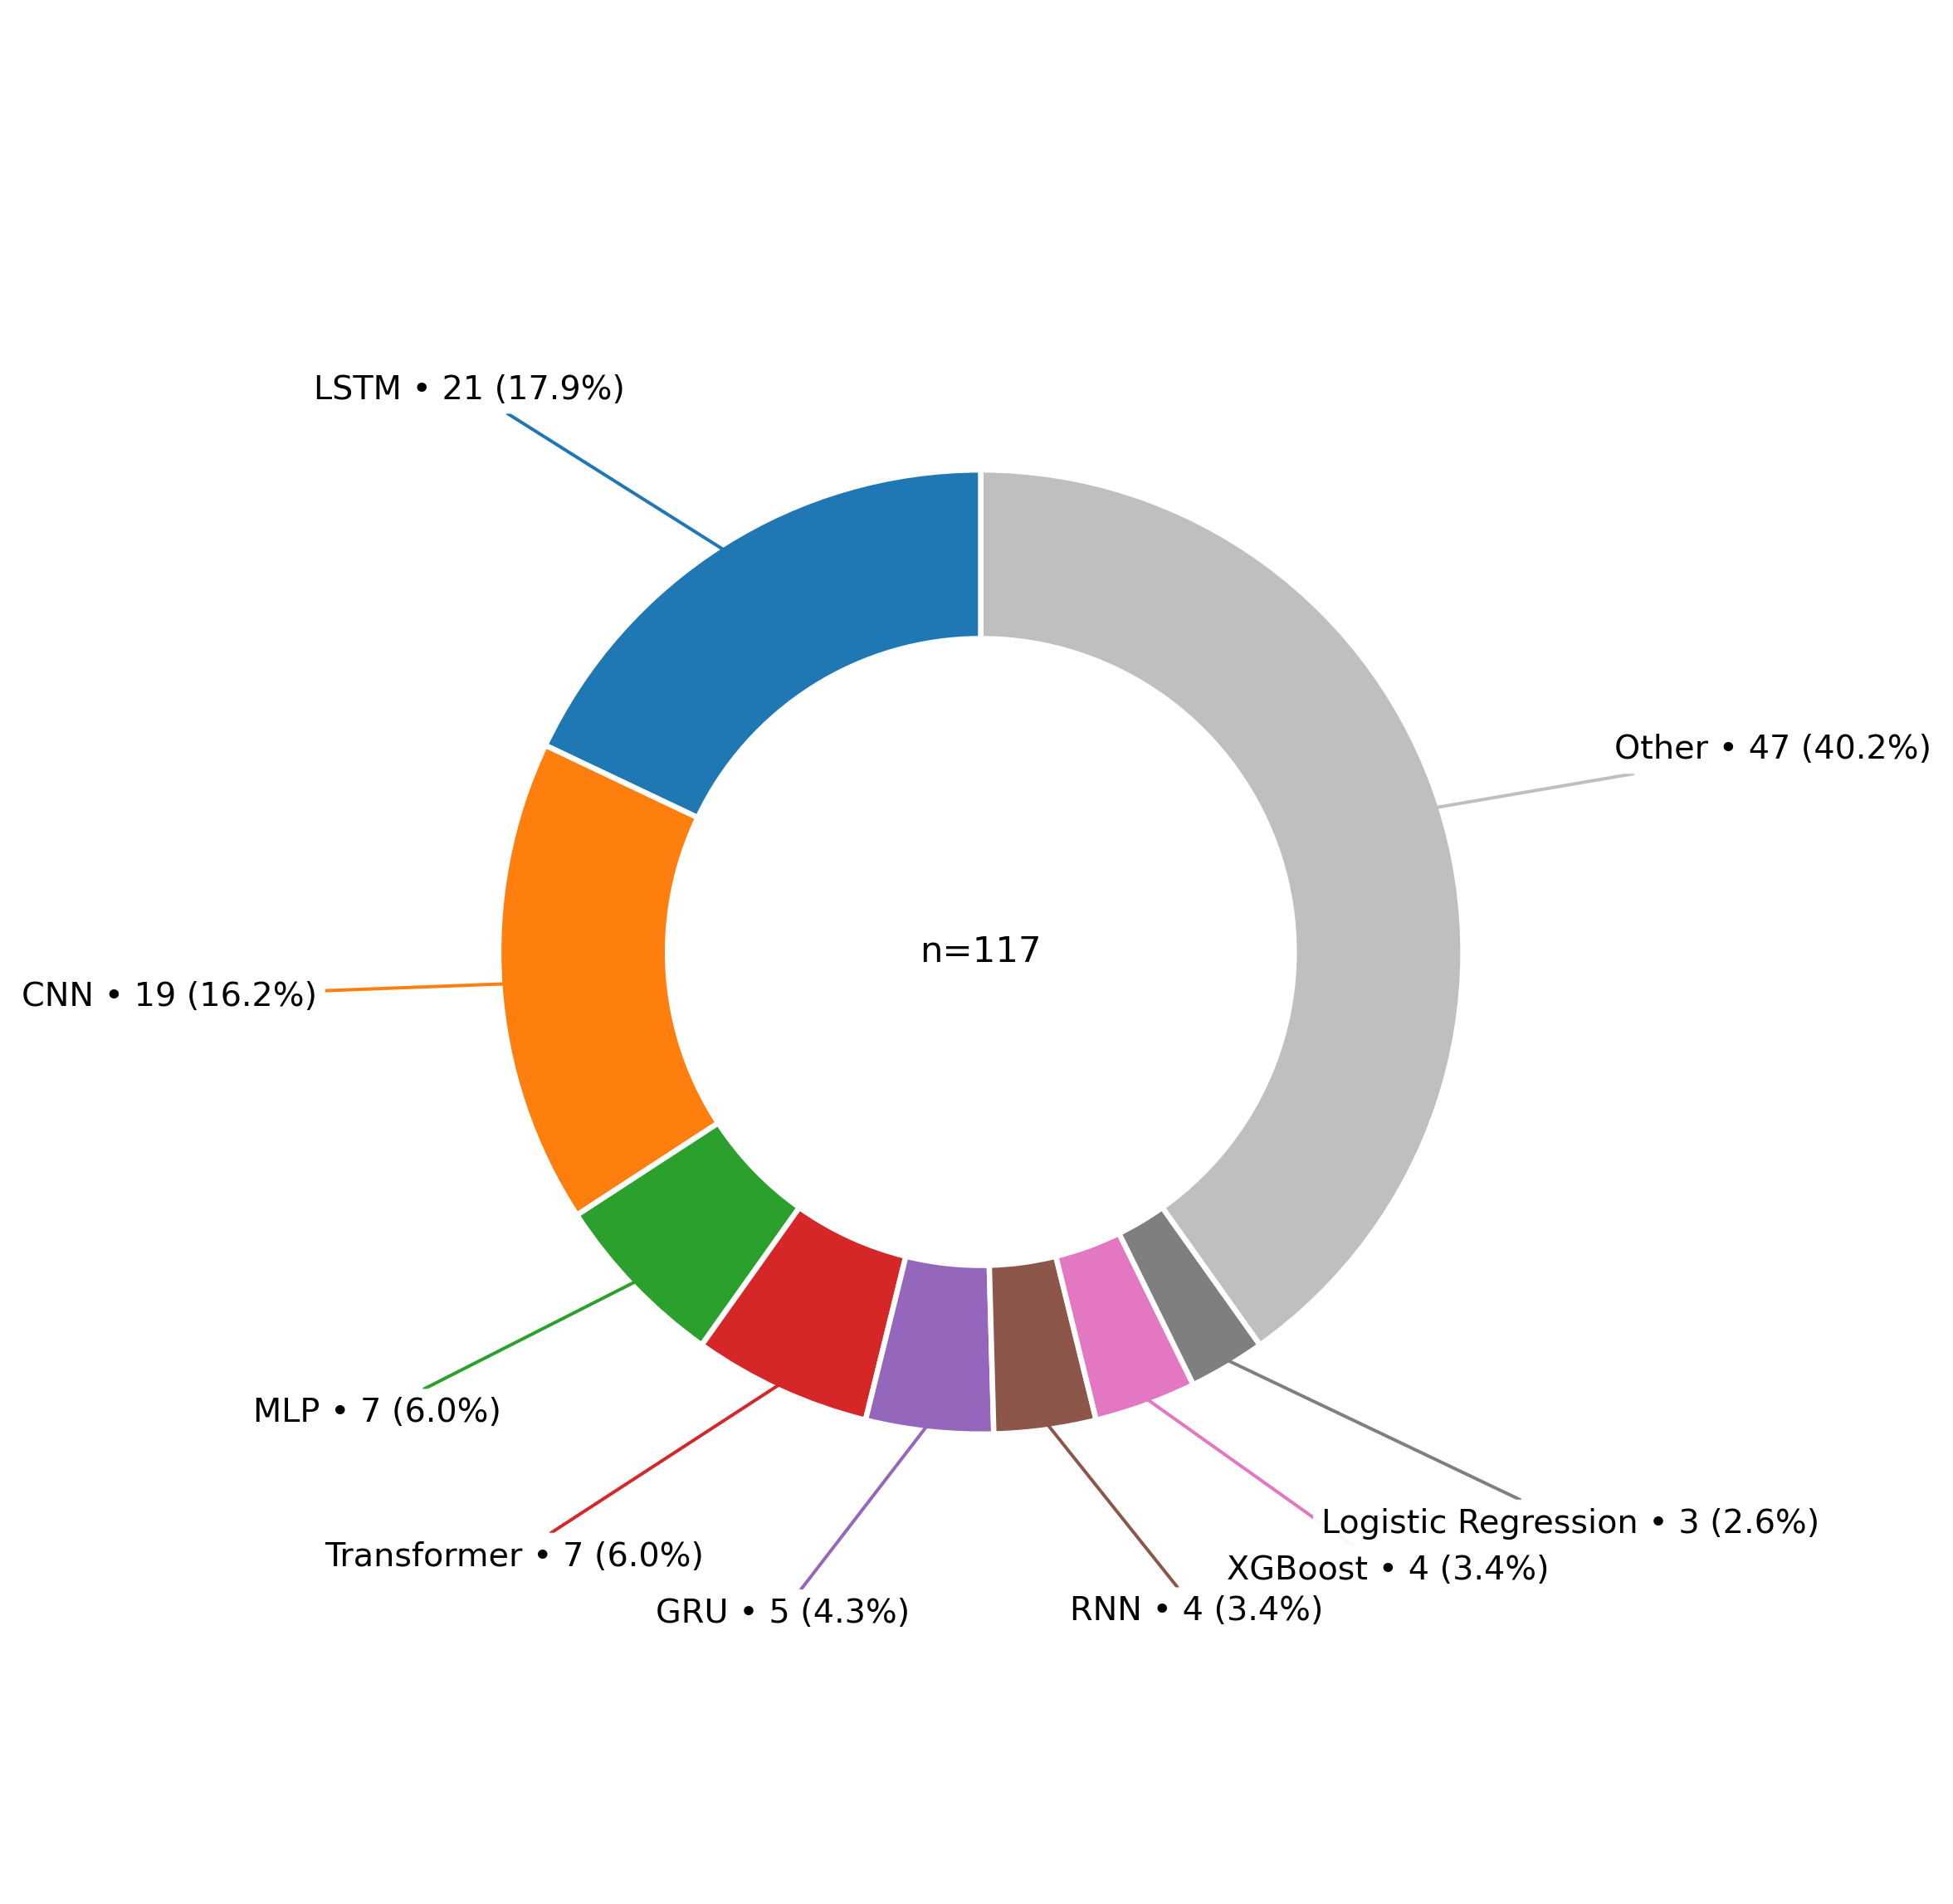

Saved to: figure_b2.png


In [47]:
# Reuse the publication-year parsing logic from Figure 4.
year_col = find_year_col(df_ml_exp)
if year_col is None:
    # Prefer the already coalesced Year if the figure-4 cell has been run.
    if "Year" in df_ml_exp.columns:
        years_b2 = pd.to_numeric(df_ml_exp["Year"], errors="coerce")
    else:
        raise KeyError("No publication-year column found for robustness Figure B2.")
else:
    years_b2 = parse_year(df_ml_exp[year_col])

df_ml_b2 = df_ml_exp.loc[years_b2.ge(2024)].copy()

summary_b2, path_b2 = plot_ml_distribution(
    df_ml_b2,
    column="ML Technique(s)",
    min_percent=2.0,
    save_path="figure_b2.png",
    abbreviate=True,
)

print("Saved to:", path_b2)

## Figure B3 — XAI distribution in the overlapping 2024–February 2025 window

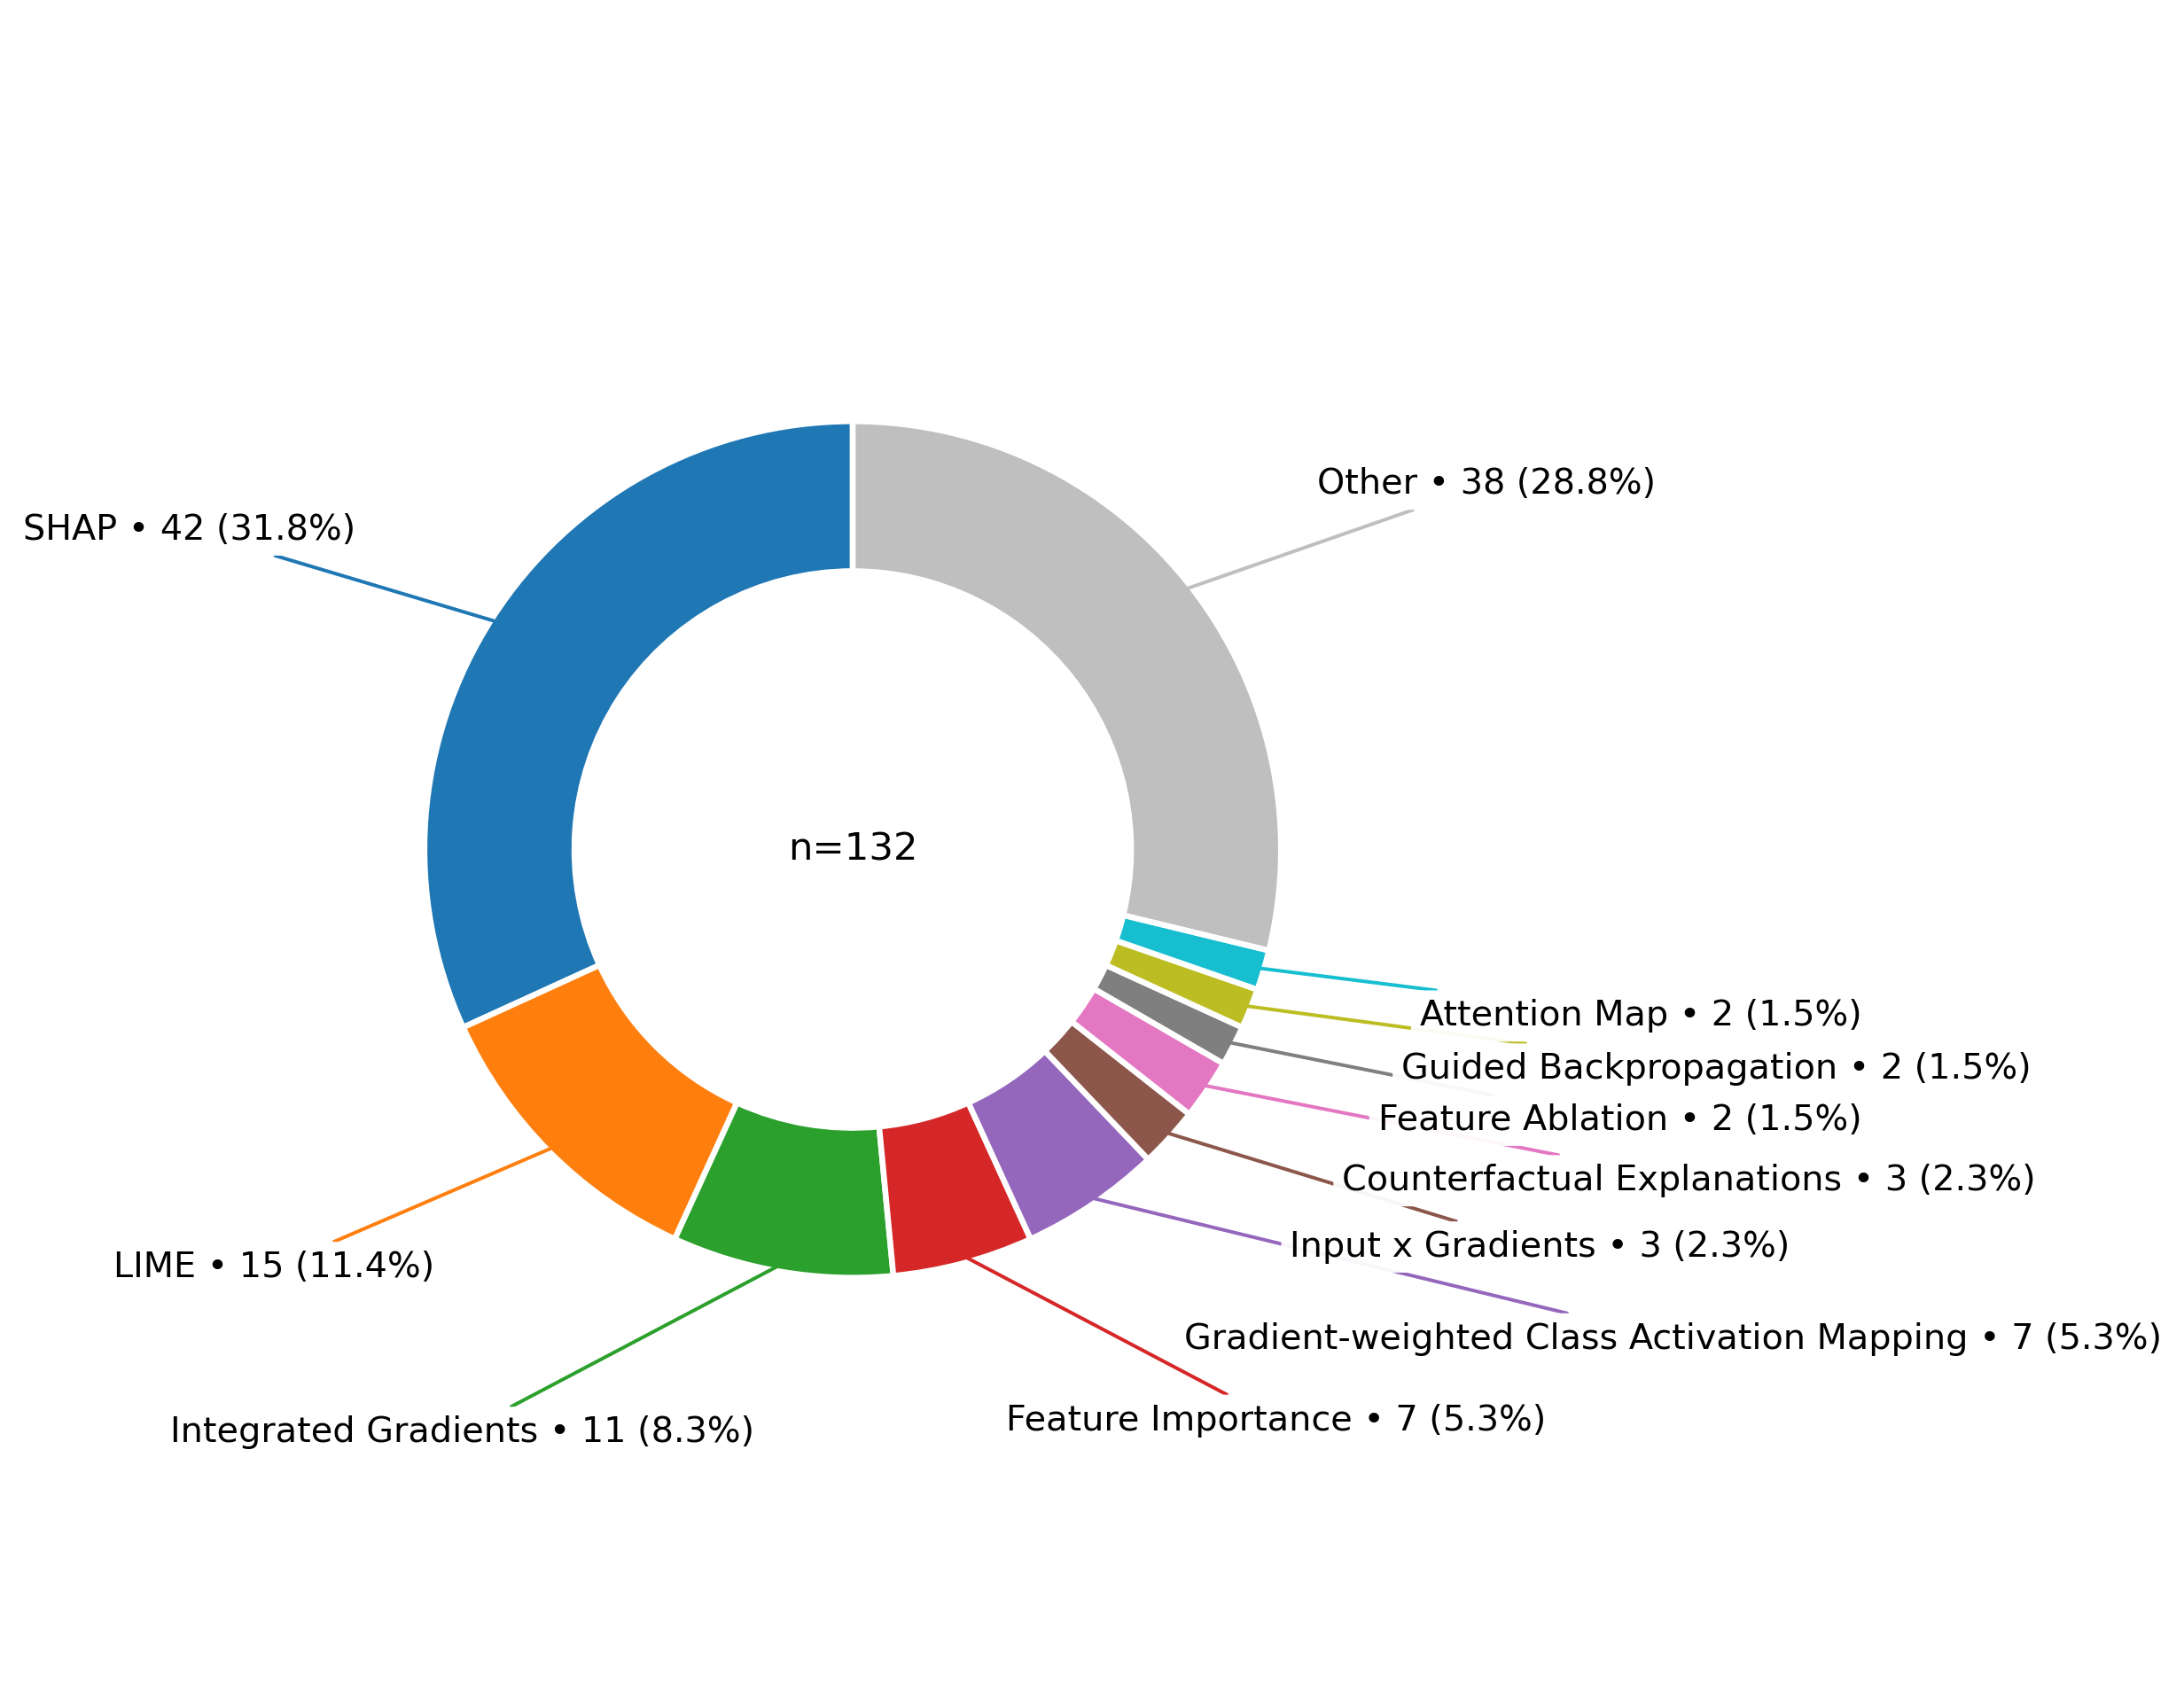

Saved to: figure_b3.png


In [49]:
year_col_x = find_year_col(df_xai)
if year_col_x is None:
    if "Year" in df_xai.columns:
        years_b3 = pd.to_numeric(df_xai["Year"], errors="coerce")
    else:
        raise KeyError("No publication-year column found for robustness Figure B3.")
else:
    years_b3 = parse_year(df_xai[year_col_x])

df_xai_b3 = df_xai.loc[years_b3.ge(2024)].copy()

summary_b3, path_b3 = plot_xai_distribution(
    df_xai_b3,
    column="XAI Technique(s)",
    top_k=10,
    min_percent=0.0,
    save_path="figure_b3.png",
)

print("Saved to:", path_b3)

## Figure B4 — ML distribution after excluding the seven preprint-only papers

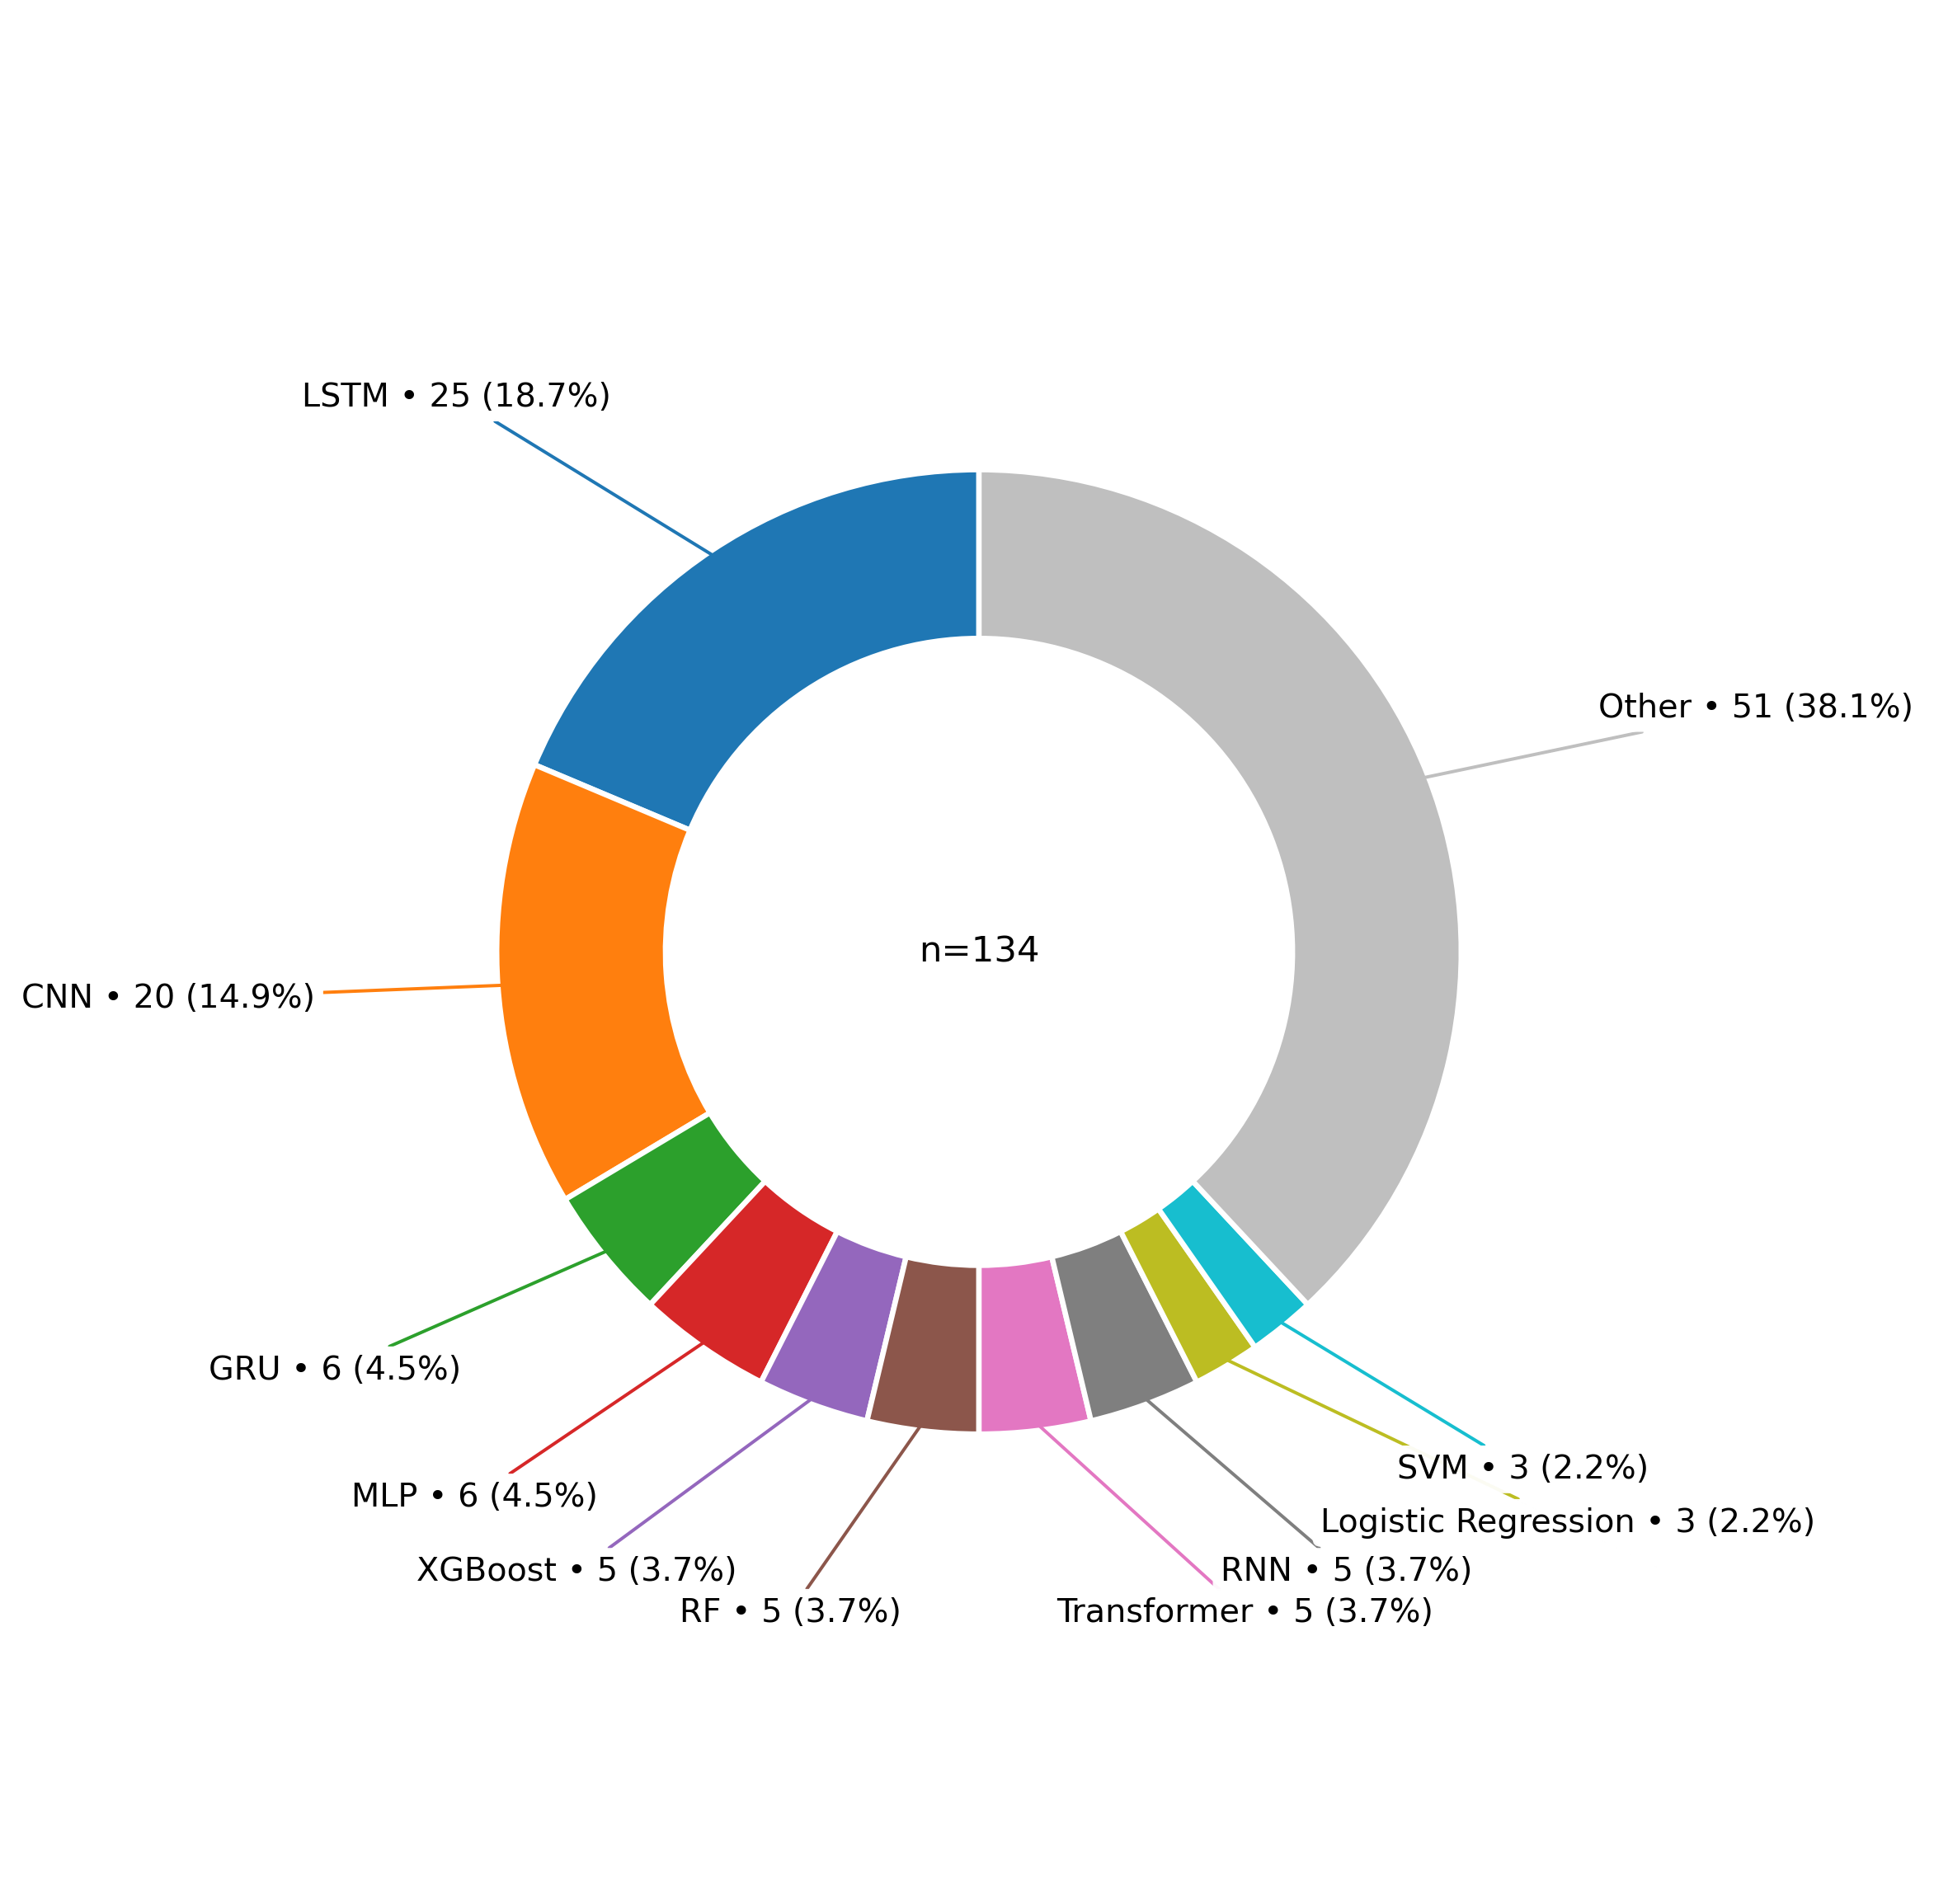

Saved to: figure_b4.png


In [51]:
PREPRINT_ONLY_KEYS = {
    "cao_ister_2024",
    "chakraborty_edformer_2024",
    "ghimire_timetrail_2023",
    "kumar_opening_2017",
    "matsunaga_exploring_2019",
    "misheva_hypothesis_2023",
    "schneider_time-series_2025",
}

def _ref_key(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    m = re.search(r"\\cite\{([^}]+)\}", s)
    return m.group(1).strip() if m else s

ref_series_ml = df_ml_exp["Ref"].map(_ref_key)
df_ml_b4 = df_ml_exp.loc[~ref_series_ml.isin(PREPRINT_ONLY_KEYS)].copy()

summary_b4, path_b4 = plot_ml_distribution(
    df_ml_b4,
    column="ML Technique(s)",
    min_percent=2.0,
    save_path="figure_b4.png",
    abbreviate=True,
)

print("Saved to:", path_b4)

## Figure B5 — XAI distribution after excluding the seven preprint-only papers

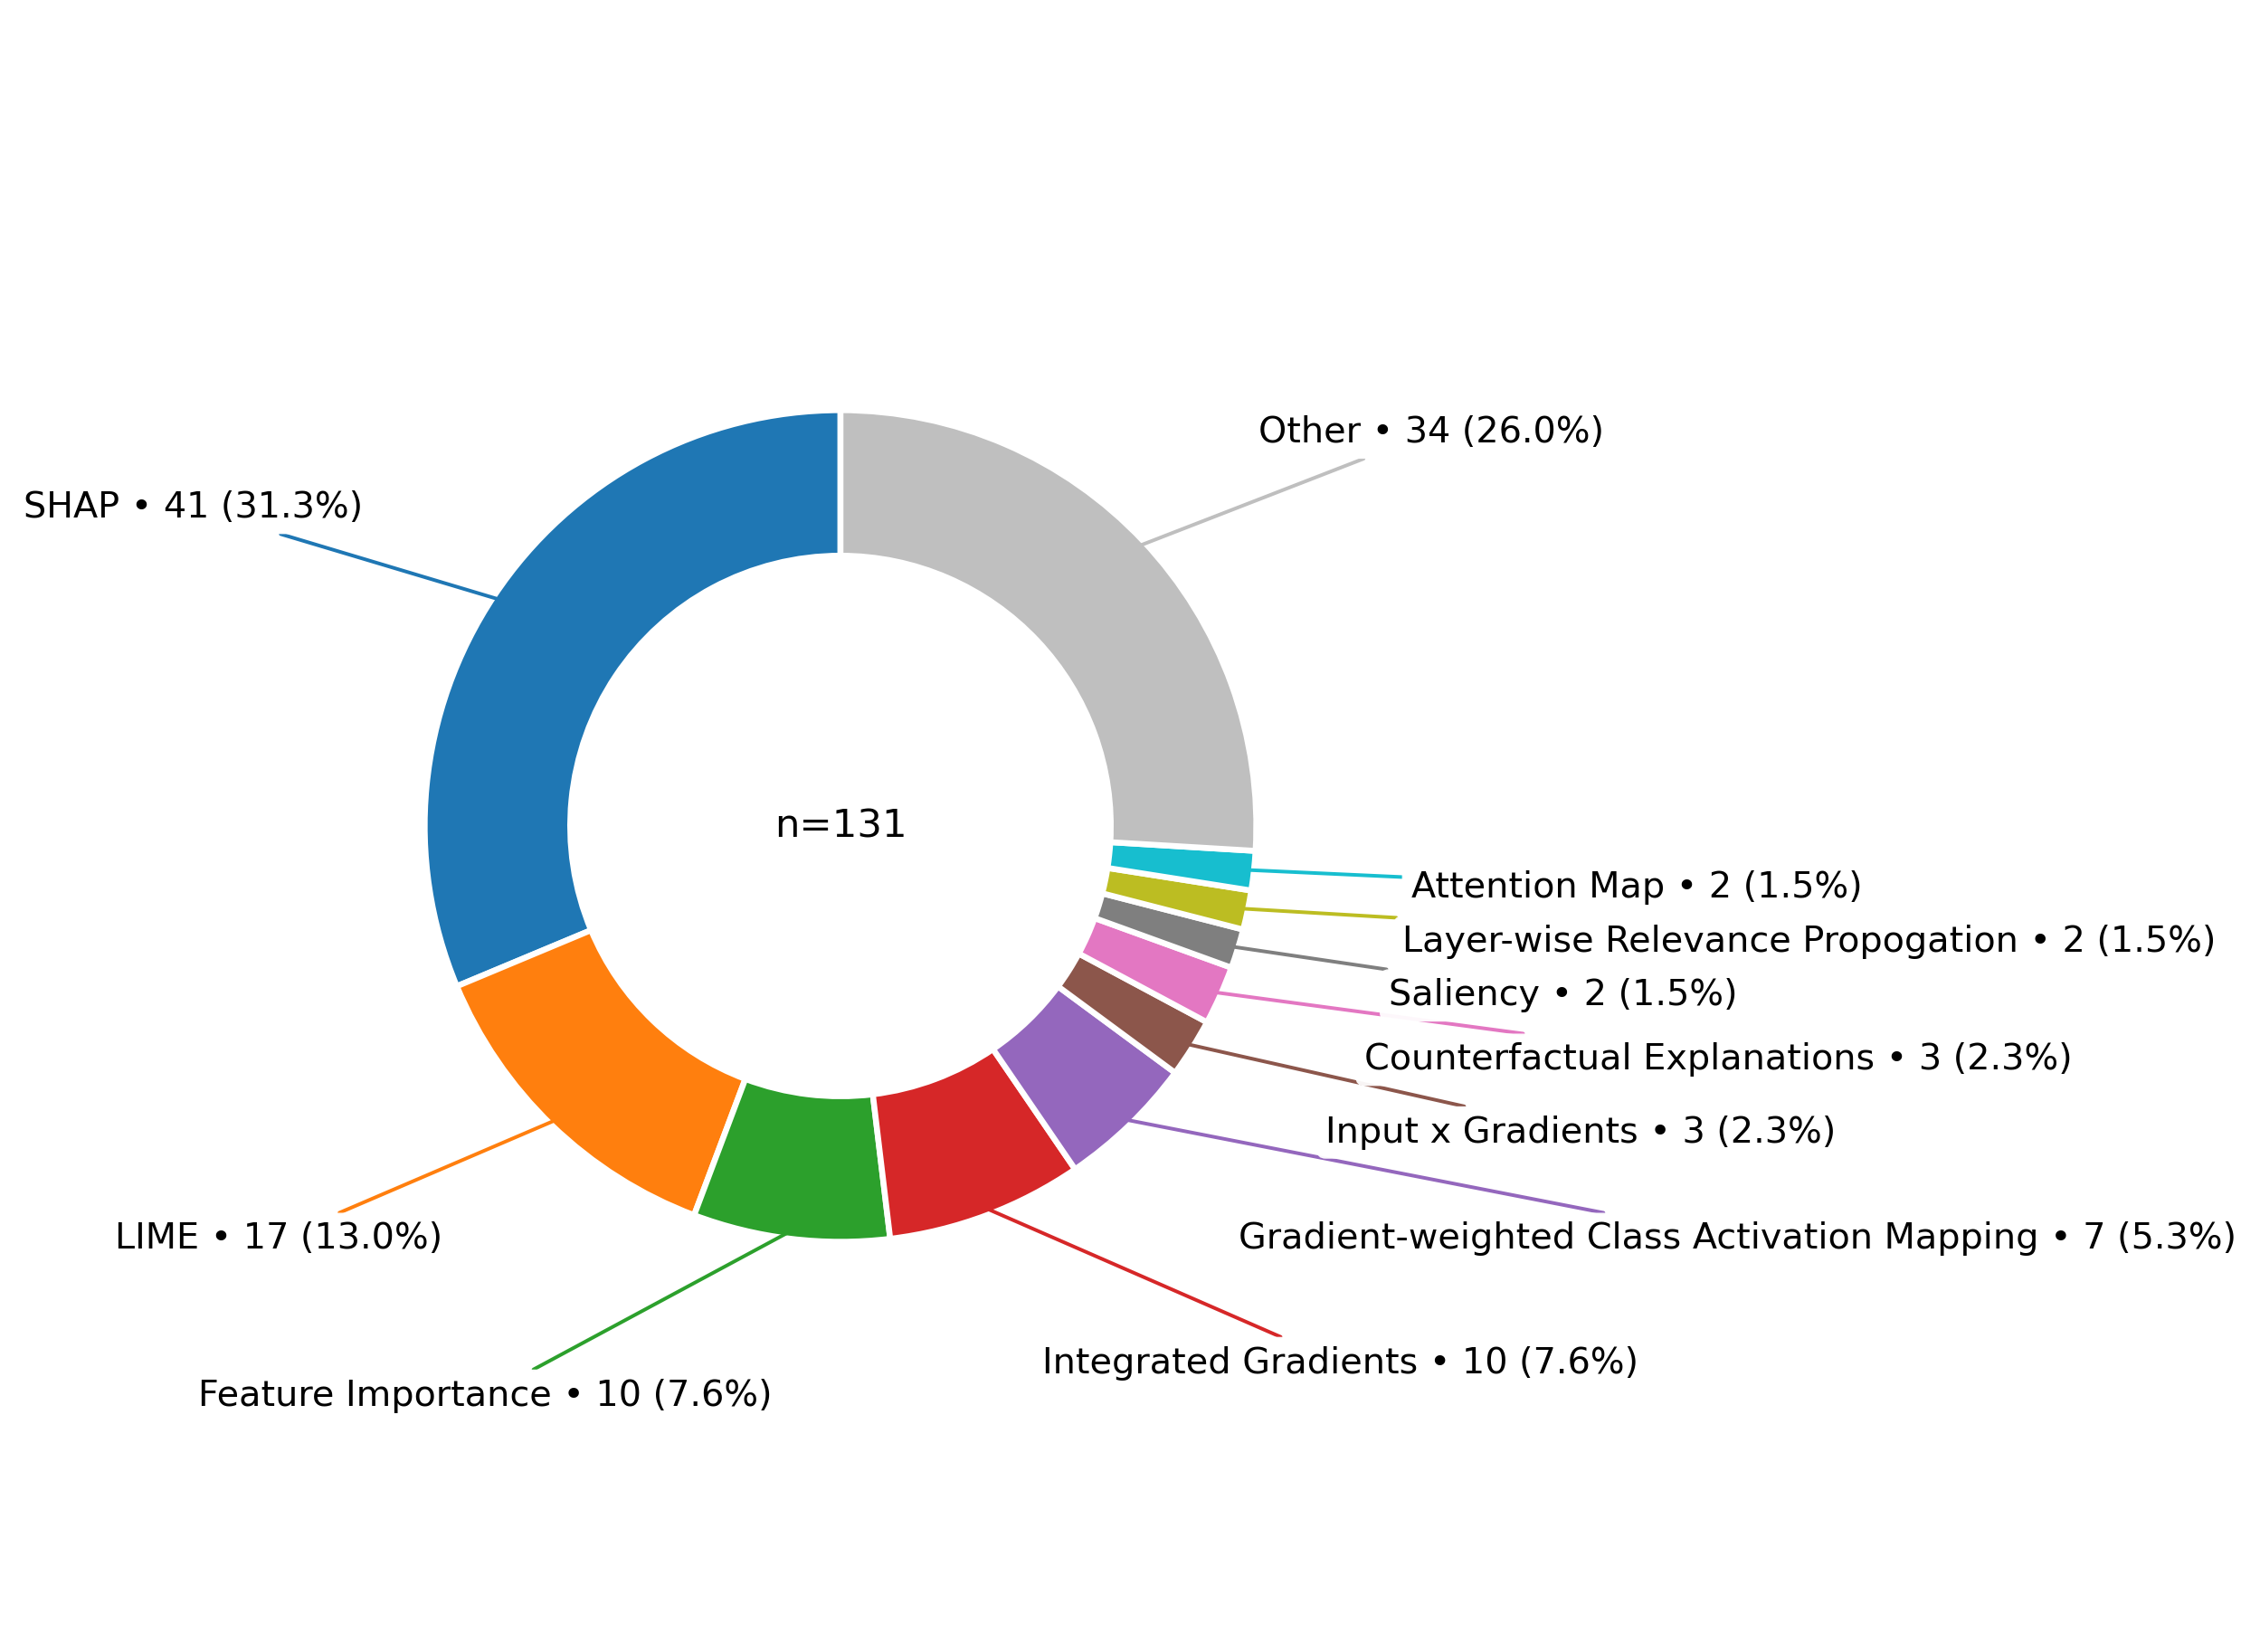

Saved to: figure_b5.png


In [53]:
ref_series_xai = df_xai["Ref"].map(_ref_key)
df_xai_b5 = df_xai.loc[~ref_series_xai.isin(PREPRINT_ONLY_KEYS)].copy()

summary_b5, path_b5 = plot_xai_distribution(
    df_xai_b5,
    column="XAI Technique(s)",
    top_k=10,
    min_percent=0.0,
    save_path="figure_b5.png",
)

print("Saved to:", path_b5)

# End of master notebook

A successful run produces no errors and all the outputs required to check the numberings in the document.